# <center style="font-weight: bold; color: #0098cd;">Procesamiento del lenguaje natural: normalización y estructuración de la información</center>

## 1. Introducción

Este *notebook* desarrolla el módulo de normalización y estructuración semántica del sistema. Su finalidad es transformar las salidas generadas por el módulo de clasificación y extracción de entidades NER en registros JSON estructurados, homogéneos y trazables, preparados para su almacenamiento posterior en una base de datos.

A diferencia de las fases anteriores, centradas en transcribir audios, clasificar mensajes o identificar entidades en texto libre, esta etapa se encarga de convertir la información extraída en una representación normalizada. Para ello, se aplican reglas específicas sobre fechas, magnitudes, unidades y entidades de dominio, reduciendo la variabilidad lingüística y generando valores canónicos cuando existe suficiente evidencia para hacerlo.

El *notebook* mantiene un enfoque progresivo. En primer lugar, se revisa la estructura de entrada y la calidad de las entidades disponibles. A continuación, se evalúan y consolidan reglas de normalización temporal, numérica y semántica. Finalmente, se implementa un pipeline final que integra todos los componentes validados y genera un JSON normalizado individual para cada audio.

### 1.1 Objetivo

### 1.1 Objetivo

El objetivo principal de este *notebook* es construir y validar un módulo capaz de transformar entidades detectadas en texto libre en una estructura semántica normalizada. Esta estructura debe conservar la trazabilidad con el audio original, incorporar los metadatos temporales de recepción y organizar la información relevante dentro de un bloque `evento`.

De forma concreta, el módulo aborda la normalización de expresiones temporales, magnitudes, unidades y entidades propias del dominio agrícola, como cultivos, variedades, problemas, tratamientos, factores climáticos, sistemas de producción, especies de sombra y localizaciones. El resultado esperado es un conjunto de archivos JSON, uno por audio, con una estructura común y utilizable para almacenamiento y consulta posterior.

El proceso no busca maximizar la cobertura a cualquier coste. Cuando una entidad no puede normalizarse de forma fiable, se evita incorporarla como valor canónico. En el caso específico de las magnitudes, cuando existe un valor numérico pero la unidad no está validada en el mapa de unidades, la información se conserva como magnitud parcialmente normalizada, manteniendo la unidad original y marcando su estado como `unidad_no_mapeada`. De este modo, se evita perder información potencialmente útil sin presentarla como completamente normalizada.

### 1.2 Contexto dentro del sistema completo

La normalización se sitúa después de las etapas de procesamiento de audio, transcripción automática, clasificación de mensajes y extracción de entidades NER. Las fases anteriores permiten transformar un audio en texto, asignar una categoría al mensaje e identificar fragmentos relevantes. Sin embargo, esas salidas siguen manteniendo variabilidad lingüística, posibles errores de etiquetado y formatos heterogéneos.

El módulo desarrollado en este *notebook* actúa como puente entre la extracción lingüística y la generación de datos estructurados. A partir de los JSON generados por el módulo de clasificación y NER, se construye una representación más estable, donde fechas, magnitudes y entidades de dominio se expresan mediante valores normalizados o mediante estados explícitos cuando la normalización completa no es posible.

Esta fase también cumple una función de revisión del sistema previo. Durante la normalización se pueden detectar entidades mal etiquetadas, unidades no contempladas, variantes ambiguas o valores fuera del alcance funcional definido. Por tanto, el módulo no solo prepara la información para su almacenamiento, sino que también permite identificar limitaciones del NER y orientar futuras mejoras del sistema.

### 1.3 Requisitos de esta fase

El módulo de normalización debe cumplir varios requisitos para que la salida generada sea coherente y reutilizable.

En primer lugar, debe trabajar únicamente sobre la información disponible en los registros generados por el módulo de clasificación y NER, evitando incorporar entidades nuevas mediante reglas externas que no hayan sido previamente etiquetadas. Esta decisión es especialmente relevante en el caso de las acciones agrícolas, que se mantienen como campos nulos en esta versión al no formar parte del esquema NER actual.

En segundo lugar, debe normalizar las expresiones temporales utilizando la fecha de recepción del audio como referencia. Esto permite resolver expresiones relativas como `ayer`, `hace dos días`, `semana pasada`, `este mes` o `actualmente` de forma coherente con el contexto temporal real del mensaje.

En tercer lugar, debe transformar las magnitudes detectadas en una representación homogénea basada en tipo, valor, unidad, unidad original y estado de normalización. Las unidades validadas se convierten a formas canónicas, mientras que las unidades no contempladas se conservan como información no completamente normalizada, evitando conversiones no justificadas.

En cuarto lugar, debe reducir la variabilidad lingüística de las entidades de dominio mediante mapas semánticos revisados manualmente. La normalización debe buscar cada entidad dentro de su propia categoría NER para evitar cruces incorrectos entre etiquetas distintas.

Además, el sistema debe generar una estructura JSON jerárquica y consistente, manteniendo campos obligatorios, listas para entidades multivalor y valores nulos cuando la información no esté disponible. Esta estructura debe poder validarse y serializarse correctamente antes de considerarse salida final del módulo.

Por último, el proceso debe mantenerse modular y extensible. Las funciones se organizan por responsabilidades, de forma que puedan trasladarse posteriormente a módulos independientes y ampliarse con nuevas entidades, reglas o mapas de normalización conforme aumente el volumen de datos anotados y se detecten nuevas necesidades del dominio.

## 2. Preparación del entorno de trabajo

En esta sección se define el entorno técnico necesario para el desarrollo del módulo de procesamiento del lenguaje natural, centrado en la normalización y estructuración de la información. Se incluyen la instalación de dependencias, la importación de librerías necesarias y la configuración de rutas de trabajo.

El objetivo es garantizar un entorno reproducible y organizado que permita aplicar de forma consistente el proceso de normalización sobre las salidas generadas por el módulo de clasificación y extracción de entidades, sin necesidad de modificar la lógica del código. Asimismo, se establece una estructura clara de directorios que facilita la separación entre datos de entrada, datos intermedios y resultados finales normalizados, favoreciendo la trazabilidad y reutilización del sistema.

### 2.1 Instalación de dependencias

En este apartado se especifica la instalación de las librerías necesarias para la ejecución del *notebook*. Todas las dependencias se gestionan mediante un archivo `requirements.txt`, lo que permite replicar el entorno de ejecución de forma controlada y consistente.

#### 2.1.1 Configuración del entorno

Este *notebook* requiere la instalación previa de las dependencias del proyecto.

Ejecutar en terminal:

```bash
pip install -r requirements.txt
```

### 2.2 Importación de librerías

Se importan las librerías necesarias para las distintas fases del procesamiento, incluyendo manipulación de señal, tratamiento de audio, modelos de detección de voz, análisis de datos y visualización.

Se organiza por bloques funcionales para permitir identificar claramente el propósito de cada conjunto de herramientas dentro del *pipeline*, facilitando la mantenibilidad y comprensión del código.

In [ ]:
# ==============================
# Gestión de rutas y archivos
# ==============================
from pathlib import Path                  # gestión de rutas del sistema de archivos
import json                               # lectura y escritura de ficheros JSON

# ==============================
# Manipulación de datos
# ==============================
import pandas as pd                       # manejo de datos tabulares

# ==============================
# Procesamiento de texto
# ==============================
import re                                 # expresiones regulares
import unicodedata                        # normalización Unicode
from unidecode import unidecode           # eliminación de acentos y normalización simplificada

# ==============================
# Fechas y tiempo
# ==============================
from datetime import datetime, date, timedelta   # gestión de fechas absolutas y relativas
import dateparser                         # análisis externo de expresiones temporales

# ==============================
# Normalización y comparación textual
# ==============================
from rapidfuzz import fuzz, process       # comparación difusa de texto para variantes y términos de dominio

# ==============================
# Visualización
# ==============================
import matplotlib.pyplot as plt           # generación de gráficos
import seaborn as sns                     # visualización estadística

# ==============================
# Utilidades de notebook
# ==============================
from tqdm import tqdm                     # barra de progreso para procesamiento por lotes
from IPython.display import display       # visualización de resultados en notebook

### 2.3 Gestión y configuración de rutas

In [218]:
# =========================
# DETECCIÓN DE RAÍZ
# =========================

project_root = Path.cwd()

while not (project_root / "data").exists():
    if project_root == project_root.parent:
        raise FileNotFoundError(
            "No se ha encontrado la carpeta 'data' en la ruta actual ni en sus directorios superiores."
        )
    project_root = project_root.parent


# =========================
# DIRECTORIOS PRINCIPALES
# =========================

# Ruta raíz de datos
data_dir = project_root / "data"


# =========================
# CONFIGURACIÓN
# =========================

# Carpeta de configuración
config_dir = data_dir / "config"

# Configuración de normalización
normalization_config_dir = config_dir / "normalization"

# Versiones del mapa de normalización semántica
normalization_map_v1_0_path = normalization_config_dir / "normalization_map_v1.0.json"
normalization_map_v1_1_path = normalization_config_dir / "normalization_map_v1.1.json"

# Mapa de normalización semántica utilizado por defecto en el notebook
# v1.0: mapa inicial
# v1.1: mapa ampliado tras revisión de entidades NER no cubiertas
normalization_map_path = normalization_map_v1_0_path

# Reglas de normalización
normalization_rules_path = normalization_config_dir / "normalization_rules.json"

# Archivo de configuración para normalización de unidades
unit_normalization_map_path = normalization_config_dir / "unit_normalization_map.json"

# Configuración de entidades NER
ner_config_dir = config_dir / "ner"

# Archivo con etiquetas válidas del modelo NER
ner_entities_path = ner_config_dir / "ner_entities.json"


# =========================
# ENTRADA DEL MÓDULO
# =========================

# Carpeta con las salidas individuales del módulo de clasificación y NER
structured_data_dir = data_dir / "structured_data"

nlp_output_dir = structured_data_dir / "nlp_output"


# =========================
# SALIDA DEL MÓDULO
# =========================

# Carpeta de salida del módulo de normalización y estructuración
normalized_output_dir = structured_data_dir / "normalized_output"


# =========================
# METADATOS
# =========================

# Carpeta con metadatos asociados a los audios
metadata_dir = data_dir / "metadata"
audio_metadata_dir = metadata_dir / "audio_metadata"


# =========================
# CREACIÓN DE CARPETAS
# =========================

# Configuración
normalization_config_dir.mkdir(parents=True, exist_ok=True)
ner_config_dir.mkdir(parents=True, exist_ok=True)

# Salida normalizada
normalized_output_dir.mkdir(parents=True, exist_ok=True)

# Metadatos
audio_metadata_dir.mkdir(parents=True, exist_ok=True)


# =========================
# VERIFICACIÓN
# =========================

print("Ruta raíz del proyecto:", project_root)

print("\n--- Directorios principales ---")
print("Directorio de datos:", data_dir)
print("Directorio de datos estructurados:", structured_data_dir)

print("\n--- Configuración ---")
print("Directorio de configuración:", config_dir)
print("Directorio de configuración de normalización:", normalization_config_dir)

print("\n--- Mapas de normalización semántica ---")
print("Mapa de normalización v1.0:", normalization_map_v1_0_path)
print("Mapa de normalización v1.1:", normalization_map_v1_1_path)
print("Mapa de normalización activo:", normalization_map_path)

print("\n--- Otros archivos de configuración ---")
print("Reglas de normalización:", normalization_rules_path)
print("Mapa de normalización de unidades:", unit_normalization_map_path)
print("Directorio de configuración NER:", ner_config_dir)
print("Entidades NER válidas:", ner_entities_path)

print("\n--- Metadatos ---")
print("Metadatos de audio:", audio_metadata_dir)

print("\n--- Input normalización ---")
print("Carpeta de salida NLP:", nlp_output_dir)

print("\n--- Output normalización ---")
print("Carpeta de salida normalizada:", normalized_output_dir)

Ruta raíz del proyecto: /Volumes/EXTENSION/GitHub/TFM

--- Directorios principales ---
Directorio de datos: /Volumes/EXTENSION/GitHub/TFM/data
Directorio de datos estructurados: /Volumes/EXTENSION/GitHub/TFM/data/structured_data

--- Configuración ---
Directorio de configuración: /Volumes/EXTENSION/GitHub/TFM/data/config
Directorio de configuración de normalización: /Volumes/EXTENSION/GitHub/TFM/data/config/normalization

--- Mapas de normalización semántica ---
Mapa de normalización v1.0: /Volumes/EXTENSION/GitHub/TFM/data/config/normalization/normalization_map_v1.0.json
Mapa de normalización v1.1: /Volumes/EXTENSION/GitHub/TFM/data/config/normalization/normalization_map_v1.1.json
Mapa de normalización activo: /Volumes/EXTENSION/GitHub/TFM/data/config/normalization/normalization_map_v1.0.json

--- Otros archivos de configuración ---
Reglas de normalización: /Volumes/EXTENSION/GitHub/TFM/data/config/normalization/normalization_rules.json
Mapa de normalización de unidades: /Volumes/EXTE

## 3. Preparación del dataset para normalización

En esta sección se preparan los datos que servirán como entrada al módulo de normalización y estructuración semántica. Para ello, se cargan los JSON generados por el módulo de clasificación y extracción de entidades NER, se revisa su estructura interna y se incorporan los metadatos temporales asociados a cada audio.

El objetivo de esta fase es garantizar que los registros disponibles contienen la información mínima necesaria para aplicar las reglas de normalización posteriores. En particular, se comprueba la presencia de los campos obligatorios, la validez de las etiquetas NER detectadas y la disponibilidad del `timestamp` de recepción, que será utilizado como fecha de referencia para resolver expresiones temporales relativas.

Esta preparación no modifica todavía el contenido semántico de los registros, sino que establece una base de trabajo consistente para las fases posteriores de normalización de fechas, magnitudes y entidades de dominio.

### 3.1 Carga de resultados del módulo NLP

En esta sección se cargan los resultados generados por el módulo de clasificación y extracción de entidades NER, correspondientes a la clase asignada a cada mensaje y a las entidades extraídas mediante el enfoque híbrido definido en el *notebook* anterior.

In [ ]:
# Obtener archivos JSON generados por el módulo de clasificación y NER
nlp_output_files = sorted(nlp_output_dir.glob("*.json"))

print(f"Número de archivos encontrados: {len(nlp_output_files)}")

# Cargar resultados de clasificación y NER
nlp_records = []

for file_path in nlp_output_files:
    with open(file_path, "r", encoding="utf-8") as f:
        record = json.load(f)
    
    nlp_records.append(record)

print(f"Número de registros cargados: {len(nlp_records)}")

# Visualizar un ejemplo de registro cargado
print("\n--- Ejemplo de registro ---")
if nlp_records:
    display(nlp_records[1])
else:
    print("No se encontraron archivos JSON en la carpeta de salida NLP.")

Número de archivos encontrados: 200
Número de registros cargados: 200

--- Ejemplo de registro ---


{'audio_id': 'AUDIO_00002',
 'text': 'Mi nombre es Luis Fernando Taborda, soy productor de café en la vereda El Tambo, municipio de El Tambo, departamento de Cauca, Colombia.  Actualmente manejo aproximadamente 7 hectáreas sembradas con variedad castillo bajo un sistema agroforestal con sombra de guavos y algunos frutales, trabajando con apoyo técnico para mejorar la producción.',
 'prediction': 'registro_inicial',
 'entities': [{'text': 'café', 'label': 'cultivo'},
  {'text': 'El Tambo', 'label': 'localidad'},
  {'text': 'El Tambo', 'label': 'localidad'},
  {'text': 'Cauca', 'label': 'region'},
  {'text': 'Colombia', 'label': 'pais'},
  {'text': '7 hectáreas', 'label': 'superficie'},
  {'text': 'castillo', 'label': 'variedad'},
  {'text': 'guavos', 'label': 'especie_sombra'},
  {'text': 'frutales', 'label': 'especie_sombra'}],
 'processing_version': '1.0'}

### 3.2 Revisión de la estructura de entrada

Antes de iniciar el proceso de normalización, se realiza una revisión de la estructura de los registros cargados desde la salida del módulo de clasificación y extracción de entidades NER. Esta comprobación permite verificar que los archivos JSON contienen los campos mínimos necesarios para aplicar las reglas posteriores de normalización temporal, numérica y semántica.

La revisión se organiza en dos niveles. En primer lugar, se valida la presencia de los campos obligatorios de cada registro, como `audio_id`, `text`, `prediction` y `entities`. En segundo lugar, se analiza el contenido de las entidades detectadas, comprobando qué etiquetas aparecen, cuántas entidades se han identificado y si todas ellas pertenecen al esquema NER definido.

Esta fase no modifica los datos, sino que actúa como control previo de calidad. Su objetivo es detectar posibles problemas estructurales antes de aplicar transformaciones sobre los registros y evitar que errores de entrada se propaguen al JSON normalizado final.

#### 3.2.1 Validación inicial de campos obligatorios

Antes de aplicar las reglas de normalización, se revisa la estructura de los registros cargados para comprobar que contienen los campos necesarios para el procesamiento posterior. Esta comprobación actúa como una verificación del contrato de entrada entre el módulo de procesamiento del lenguaje natural y el módulo de normalización, permitiendo detectar posibles inconsistencias antes de iniciar la generación de datos estructurados.

<div style="border-left: 5px solid #ff4d4d; padding: 10px; background-color: #2b2b2b; color: #f0f0f0;">
<strong style="color: red">⚠️ Advertencia:</strong> Se recomienda ejecutar esta comprobación tras cualquier modificación en la salida del módulo NLP. La ausencia o modificación de campos obligatorios, como <code>audio_id</code>, <code>text</code>, <code>prediction</code> o <code>entities</code>, puede impedir la correcta normalización de los registros y generar salidas estructuradas incompletas o inconsistentes.
</div>

In [136]:
# Campos obligatorios esperados según la estructura de salida del módulo NLP
expected_fields = ["audio_id", "text", "prediction", "entities"]

# Revisión de campos obligatorios por registro
structure_review = []

for record in nlp_records:
    missing_fields = [field for field in expected_fields if field not in record]
    
    review = {
        "audio_id": record.get("audio_id"),
        "has_audio_id": "audio_id" in record,
        "has_text": "text" in record,
        "has_prediction": "prediction" in record,
        "has_entities": "entities" in record,
        "num_entities": len(record.get("entities", [])) if isinstance(record.get("entities", []), list) else None,
        "missing_fields": missing_fields,
        "is_valid_structure": len(missing_fields) == 0
    }
    
    structure_review.append(review)

df_structure_review = pd.DataFrame(structure_review)

# Resumen de validación estructural
total_records = len(df_structure_review)
valid_records = df_structure_review["is_valid_structure"].sum()
invalid_records = total_records - valid_records

print("=== Resumen de validación estructural ===")
print(f"Registros revisados: {total_records}")
print(f"Registros con estructura válida: {valid_records}")
print(f"Registros con estructura incompleta: {invalid_records}")

print("\n=== Primeros 5 registros revisados ===")
display(df_structure_review.head())

# Visualizar registros con estructura incompleta
df_invalid_structure = df_structure_review[~df_structure_review["is_valid_structure"]]

if not df_invalid_structure.empty:
    print("\n=== Registros con estructura incompleta ===")
    display(df_invalid_structure)

=== Resumen de validación estructural ===
Registros revisados: 200
Registros con estructura válida: 200
Registros con estructura incompleta: 0

=== Primeros 5 registros revisados ===


,audio_id,has_audio_id,has_text,has_prediction,has_entities,num_entities,missing_fields,is_valid_structure
0,AUDIO_00001,True,True,True,True,4,[],True
1,AUDIO_00002,True,True,True,True,9,[],True
2,AUDIO_00003,True,True,True,True,2,[],True
3,AUDIO_00004,True,True,True,True,4,[],True
4,AUDIO_00005,True,True,True,True,7,[],True


#### 3.2.2 Revisión de entidades disponibles

Una vez comprobada la estructura general de los registros, se revisan las entidades disponibles en la salida del módulo de clasificación y NER.

In [137]:
# Cargar etiquetas válidas del modelo NER
with open(ner_entities_path, "r", encoding="utf-8") as f:
    ner_entities_config = json.load(f)

valid_ner_labels = set(ner_entities_config["entities"])


# Revisión de entidades disponibles en los registros cargados
entity_review = []
records_without_entities = []

for record in nlp_records:
    audio_id = record.get("audio_id")
    entities = record.get("entities", [])
    
    if not isinstance(entities, list) or len(entities) == 0:
        records_without_entities.append({
            "audio_id": audio_id,
            "prediction": record.get("prediction"),
            "text": record.get("text")
        })
        continue
    
    for entity in entities:
        entity_label = entity.get("label") if isinstance(entity, dict) else None
        
        entity_review.append({
            "audio_id": audio_id,
            "prediction": record.get("prediction"),
            "entity_text": entity.get("text") if isinstance(entity, dict) else None,
            "entity_label": entity_label,
            "is_valid_label": entity_label in valid_ner_labels
        })

df_entity_review = pd.DataFrame(entity_review)
df_records_without_entities = pd.DataFrame(records_without_entities)

# Resumen de entidades disponibles
print("=== Resumen de entidades disponibles ===")
print(f"Registros cargados: {len(nlp_records)}")
print(f"Entidades detectadas: {len(df_entity_review)}")
print(f"Registros sin entidades: {len(df_records_without_entities)}")

if not df_entity_review.empty:
    print(f"Tipos de entidad diferentes: {df_entity_review['entity_label'].nunique()}")
    print(f"Entidades con etiqueta no reconocida: {(~df_entity_review['is_valid_label']).sum()}")
else:
    print("No se han detectado entidades en los registros cargados.")

=== Resumen de entidades disponibles ===
Registros cargados: 200
Entidades detectadas: 785
Registros sin entidades: 0
Tipos de entidad diferentes: 14
Entidades con etiqueta no reconocida: 0


### 3.3 Definición de la fecha de referencia para normalización temporal

La normalización de expresiones temporales relativas requiere una fecha de referencia estable. En este *pipeline*, dicha referencia se obtiene a partir del campo `timestamp` asociado a cada audio en los metadatos del sistema de mensajería. Este valor representa el momento de recepción del audio y permite resolver expresiones como “ayer”, “hace dos días” o “la semana pasada” en relación con el contexto temporal real del mensaje.

In [138]:
# Cargar metadatos asociados a cada audio
metadata_files = sorted(audio_metadata_dir.glob("*.json"))

audio_metadata = {}

for file_path in metadata_files:
    with open(file_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)
    
    audio_id = metadata.get("id")
    
    if audio_id is not None:
        audio_metadata[audio_id] = metadata

print("=== Resumen de metadatos de audio ===")
print(f"Archivos de metadatos encontrados: {len(metadata_files)}")
print(f"Metadatos cargados correctamente: {len(audio_metadata)}")

=== Resumen de metadatos de audio ===
Archivos de metadatos encontrados: 200
Metadatos cargados correctamente: 200


## 4. Diseño del esquema de salida estructurado

Una vez revisada la estructura de entrada y definida la referencia temporal asociada a cada audio, se establece el formato de salida del módulo. El objetivo de esta etapa es transformar los resultados procedentes de la clasificación y la extracción de entidades en una representación estructurada, homogénea y reutilizable.

El esquema de salida debe conservar la trazabilidad con el audio original, mantener la transcripción procesada, incluir la clasificación asignada y organizar la información normalizada dentro de una estructura semántica clara. Esta organización facilita su posterior almacenamiento en base de datos, su consulta mediante sistemas de recuperación de información y su posible uso en procesos de generación de *embeddings*.

### 4.1 Definición del formato JSON final

Se define la estructura general del JSON normalizado que generará el módulo para cada audio. Este formato actúa como contrato de salida del proceso de normalización y permite garantizar que todos los registros presentan una organización común, independientemente de las entidades detectadas en cada mensaje.

```json
{
    "audio_id": "AUDIO_00001",
    "user_id": "hash_anonimizado",
    "tipo": "evento_cultivo",
    "timestamp_recepcion": "YYYY-MM-DDTHH:MM:SSZ",
    "fecha_recepcion": "YYYY-MM-DD",
    "transcripcion": "...",
    "evento": {
        "fecha_evento": "YYYY-MM-DD",
        "fecha_evento_fin": null,
        "granularidad_fecha_evento": "dia",
        "cultivo": "cafe",
        "variedad": null,
        "accion": null,
        "categoria_accion": null,
        "magnitudes": [
            {
                "tipo": "conteo",
                "valor": 20.0,
                "unidad": "plantas",
                "unidad_original": "plantas",
                "estado": "ok"
            },
            {
                "tipo": "superficie",
                "valor": 11.0,
                "unidad": null,
                "unidad_original": "tareas",
                "estado": "unidad_no_mapeada"
            }
        ],
        "problemas": [],
        "tratamientos": [],
        "partes_planta": [],
        "estado_cultivo": null,
        "espacio_agricola": null,
        "localidad": null,
        "region": null,
        "pais": null,
        "factor_climatico": [],
        "sistema_produccion": null,
        "especie_sombra": []
    },
    "estado_procesamiento": "ok",
    "normalization_version": "1.1"
}
```

### 4.2 Separación entre transcripción y evento normalizado

El esquema de salida separa explícitamente la transcripción del mensaje y la representación estructurada del evento normalizado. La transcripción se conserva como referencia del mensaje procesado y permite mantener trazabilidad con el texto generado por el sistema ASR. Por su parte, el bloque `evento` contiene los valores normalizados que serán utilizados para almacenamiento, consulta y explotación posterior de la información.

Las entidades detectadas por el módulo NER no se almacenan como un bloque independiente en la salida final, ya que actúan como una representación intermedia utilizada para construir el evento estructurado. De este modo, se evita duplicar información y se prioriza una salida limpia, orientada a base de datos y a los procesos posteriores del *pipeline*.

- **`transcripcion`**: conserva la transcripción procesada como referencia y trazabilidad.
- **`evento`**: agrupa los campos normalizados que representan el contenido agrícola del mensaje.
- **`estado_procesamiento`**: indica si el registro se ha estructurado correctamente o si presenta limitaciones.

### 4.3 Inclusión de metadatos y trazabilidad

Además del bloque `evento`, el esquema de salida incorpora metadatos mínimos que permiten relacionar cada registro normalizado con el audio original, la transcripción procesada y el momento de recepción del mensaje. Estos campos no forman parte del contenido agrícola del evento, pero son necesarios para mantener la trazabilidad del *pipeline* y facilitar su posterior almacenamiento o consulta.

En concreto, se conservan el identificador del audio, el tipo de mensaje asignado por el clasificador, el `timestamp` de recepción, la fecha derivada de dicho *timestamp* y la versión del módulo de normalización utilizada. Esta información permite reconstruir el origen de cada registro normalizado sin duplicar las entidades intermedias generadas por el módulo NLP.

Los metadatos principales incluidos en la salida son:

- **`audio_id`**: identifica de forma única el audio procesado y permite enlazar la salida normalizada con los metadatos y resultados previos del *pipeline*.
- **`tipo`**: conserva la categoría asignada por el modelo de clasificación.
- **`timestamp_recepcion`**: registra el momento de recepción del audio.
- **`fecha_recepcion`**: representa la fecha derivada del timestamp, utilizada como referencia para resolver expresiones temporales relativas.
- **`normalization_version`**: identifica la versión del módulo de normalización aplicada.

### 4.4 Definición de campos obligatorios y opcionales

El esquema de salida diferencia entre campos obligatorios y campos opcionales. Los campos obligatorios deben estar presentes en todos los registros normalizados, ya que permiten identificar el audio, conservar la transcripción, enlazar el evento con su fecha de recepción y registrar el estado del procesamiento. Los campos opcionales dependen del contenido real del mensaje y pueden tomar valor `null` o listas vacías cuando la información no está disponible.

Esta distinción evita forzar valores inexistentes y permite mantener una estructura homogénea sin inventar información. De este modo, un mensaje que no incluya ubicación, magnitudes, cultivo o tratamiento puede seguir generando una salida válida, siempre que conserve los campos estructurales mínimos.

| Tipo | Campo | Criterio |
|---|---|---|
| Obligatorio | `audio_id` | Identificador único del audio procesado. |
| Obligatorio | `user_id` | Identificador anonimizado del usuario o emisor del audio. |
| Obligatorio | `tipo` | Categoría asignada por el clasificador. |
| Obligatorio | `timestamp_recepcion` | Momento de recepción del audio según los metadatos. |
| Obligatorio | `fecha_recepcion` | Fecha derivada del *timestamp* de recepción. |
| Obligatorio | `transcripcion` | Transcripción procesada utilizada como entrada del módulo de normalización. |
| Obligatorio | `evento` | Bloque estructurado con la información normalizada. |
| Obligatorio | `estado_procesamiento` | Estado final del procesamiento del registro. |
| Obligatorio | `normalization_version` | Versión del módulo de normalización. |
| Opcional | `fecha_evento` | Puede ser `null` si no se detecta una referencia temporal del evento. |
| Opcional | `fecha_evento_fin` | Puede ser `null` cuando la fecha del evento corresponde a un día concreto o no se ha resuelto un rango temporal. |
| Opcional | `granularidad_fecha_evento` | Puede ser `null` si no se normaliza una fecha de evento. |
| Opcional | `cultivo` | Puede ser `null` si no se identifica cultivo. |
| Opcional | `variedad` | Puede ser `null` si no se identifica variedad. |
| Opcional | `accion` | Puede ser `null` si no se identifica acción agrícola. |
| Opcional | `categoria_accion` | Puede ser `null` si no se identifica una acción normalizable. |
| Opcional | `magnitudes` | Lista vacía si no se detectan cantidades, superficies, masas, volúmenes, distancias o duraciones. |
| Opcional | `problemas` | Lista vacía si no se detectan plagas, enfermedades u otros problemas. |
| Opcional | `tratamientos` | Lista vacía si no se detectan tratamientos, productos o labores aplicadas. |
| Opcional | `partes_planta` | Lista vacía si no se detectan partes de la planta. |
| Opcional | `estado_cultivo` | Puede ser `null` si no se menciona el estado del cultivo. |
| Opcional | `espacio_agricola` | Puede ser `null` si no se identifica lote, parcela, finca u otro espacio agrícola. |
| Opcional | `localidad` | Puede ser `null` si no se menciona localidad. |
| Opcional | `region` | Puede ser `null` si no se menciona región. |
| Opcional | `pais` | Puede ser `null` si no se menciona país. |
| Opcional | `factor_climatico` | Lista vacía si no se detectan condiciones climáticas. |
| Opcional | `sistema_produccion` | Puede ser `null` si no se menciona sistema productivo. |
| Opcional | `especie_sombra` | Lista vacía si no se detectan especies de sombra. |

### 4.5 Control de calidad del registro estructurado

El esquema de salida incorpora un campo de control de calidad mediante `estado_procesamiento`, cuyo objetivo es indicar si el registro ha podido ser estructurado correctamente a partir de la información disponible. Este campo permite diferenciar entre registros completamente normalizados, registros parcialmente estructurados y registros que no han podido procesarse de forma fiable.

El control de calidad no implica descartar automáticamente los registros incompletos, ya que en mensajes reales pueden faltar determinados elementos, como fecha del evento, ubicación, superficie o tratamiento aplicado. En su lugar, el módulo debe identificar el estado del registro y conservar la información disponible sin inventar valores ausentes.

| Estado | Descripción |
|---|---|
| `ok` | El registro conserva los campos estructurales mínimos y el evento contiene información normalizada suficiente para su explotación. |
| `parcial` | El registro se ha estructurado, pero presenta campos relevantes no resueltos o información incompleta. |
| `error` | El registro no puede estructurarse de forma fiable por ausencia de campos obligatorios, falta de metadatos esenciales o inconsistencias graves en la entrada. |

Esta estrategia permite mantener una salida homogénea y, al mismo tiempo, identificar los casos que requieren revisión posterior. En fases futuras, el control de calidad podrá ampliarse con indicadores más detallados, como campos no resueltos, reglas aplicadas o causas específicas de error, si las necesidades de explotación del sistema lo requieren.

## 5. Normalización de texto y valores básicos

En esta sección se definen funciones auxiliares para normalizar cadenas de texto y valores simples antes de aplicar reglas específicas sobre fechas, magnitudes, entidades de dominio o acciones agrícolas. Estas funciones permiten reducir variabilidad superficial en los textos, como diferencias de mayúsculas, acentos, espacios o puntuación, y sirven como base para realizar comparaciones homogéneas durante el proceso de normalización.

La normalización aplicada en esta etapa no sustituye a la normalización semántica posterior. Su objetivo es preparar los valores detectados por el módulo NLP para que puedan ser comparados de forma consistente con catálogos, reglas y diccionarios de dominio.

### 5.1 Normalización general de cadenas de texto

A continuación, se define una función de normalización general orientada a limpiar cadenas de texto sin alterar de forma agresiva su contenido. Esta función mantiene los acentos, convierte el texto a minúsculas, normaliza la representación Unicode y elimina espacios duplicados.

In [139]:
def normalize_text_basic(text: str) -> str:
  
    if text is None:
        return ""
    
    text = str(text)
    
    # Normalización unicode
    text = unicodedata.normalize("NFKC", text)
    
    # Conversión a minúsculas
    text = text.lower()
    
    # Eliminación de espacios duplicados
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

### 5.2 Normalización de acentos, mayúsculas y espacios

Para tareas de comparación, búsqueda en catálogos o aplicación de reglas, resulta útil disponer de una versión simplificada del texto. En este caso se eliminan los acentos y se normalizan mayúsculas, espacios y signos de puntuación básicos. Esta representación no sustituye al texto original, sino que se utiliza internamente para facilitar el *matching* entre variantes lingüísticas.

In [140]:
def normalize_text_for_matching(text: str) -> str:
    
    if text is None:
        return ""
    
    text = str(text)
    
    # Normalización unicode
    text = unicodedata.normalize("NFKC", text)
    
    # Conversión a minúsculas
    text = text.lower()
    
    # Eliminación de acentos
    text = unidecode(text)
    
    # Sustitución de puntuación por espacios
    text = re.sub(r"[^\w\s]", " ", text)
    
    # Eliminación de espacios duplicados
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

### 5.3 Normalización de variantes lingüísticas

En esta subsección se utiliza el mapa de normalización definido para el módulo, que relaciona variantes lingüísticas frecuentes con sus formas canónicas. Este recurso permite convertir expresiones como “cafetal”, “roya del café” o “fumigación” en valores normalizados y consistentes para su posterior incorporación al evento estructurado.

In [220]:
# Cargar mapa de normalización semántica inicial v1.0
with open(normalization_map_v1_0_path, "r", encoding="utf-8") as f:
    normalization_map = json.load(f)


# Construir índice plano de variantes normalizadas
normalization_index = {}

for category, canonical_values in normalization_map.items():
    for canonical_value, variants in canonical_values.items():
        for variant in [canonical_value] + variants:
            normalized_variant = normalize_text_for_matching(variant)
            
            normalization_index[normalized_variant] = {
                "category": category,
                "canonical_value": canonical_value
            }


def normalize_variant(text: str) -> dict:
    """
    Normaliza una variante lingüística mediante el mapa de normalización semántica v1.0.
    """
    
    normalized_text = normalize_text_for_matching(text)
    
    if normalized_text == "":
        return {
            "canonical_value": None,
            "category": None,
            "matched": False
        }
    
    match = normalization_index.get(normalized_text)
    
    if match is None:
        return {
            "canonical_value": normalized_text,
            "category": None,
            "matched": False
        }
    
    return {
        "canonical_value": match["canonical_value"],
        "category": match["category"],
        "matched": True
    }

### 5.4 Gestión de valores vacíos, nulos y no reconocidos

Antes de construir el registro estructurado, es necesario definir un criterio homogéneo para representar valores ausentes o no reconocidos. En este módulo se utilizará `None` para campos escalares sin información y listas vacías para campos multivalor. Esta decisión evita inventar valores y permite diferenciar entre información no disponible y valores realmente detectados.

In [142]:
def normalize_empty_value(value):
    
    if value is None:
        return None
    
    if isinstance(value, str):
        value_clean = normalize_text_basic(value)
        
        if value_clean == "":
            return None
        
        value_for_matching = normalize_text_for_matching(value_clean)
        
        if value_for_matching in {"none", "null", "nan", "no disponible", "sin dato", "sin datos"}:
            return None
        
        return value_clean
    
    return value

#### 5.4.1 Inicialización de la estructura base del evento

A continuación, se define una función auxiliar para inicializar la estructura base del bloque `evento`. Esta plantilla garantiza que todos los registros normalizados mantengan la misma organización interna, aunque algunas entidades no hayan sido detectadas en el mensaje original.

In [143]:
def initialize_event_structure() -> dict:
    """
    Inicializa la estructura base del evento normalizado.
    """
    
    return {
        "fecha_evento": None,
        "fecha_evento_fin": None,
        "granularidad_fecha_evento": None,
        "cultivo": None,
        "variedad": None,
        "accion": None,
        "categoria_accion": None,
        "magnitudes": [],
        "problemas": [],
        "tratamientos": [],
        "partes_planta": [],
        "estado_cultivo": None,
        "espacio_agricola": None,
        "localidad": None,
        "region": None,
        "pais": None,
        "factor_climatico": [],
        "sistema_produccion": None,
        "especie_sombra": []
    }

# Visualizar estructura inicial del evento
print("=== Estructura base del evento ===")
display(initialize_event_structure())

=== Estructura base del evento ===


{'fecha_evento': None,
 'fecha_evento_fin': None,
 'granularidad_fecha_evento': None,
 'cultivo': None,
 'variedad': None,
 'accion': None,
 'categoria_accion': None,
 'magnitudes': [],
 'problemas': [],
 'tratamientos': [],
 'partes_planta': [],
 'estado_cultivo': None,
 'espacio_agricola': None,
 'localidad': None,
 'region': None,
 'pais': None,
 'factor_climatico': [],
 'sistema_produccion': None,
 'especie_sombra': []}

### 5.5 Comprobación de funciones auxiliares de normalización

Se realiza una comprobación básica de las funciones auxiliares definidas previamente. El objetivo es verificar, sobre un conjunto reducido de ejemplos, que la normalización básica de texto, la normalización para *matching*, el mapeo de variantes lingüísticas y la gestión de valores vacíos producen salidas coherentes antes de avanzar hacia reglas específicas de fechas, magnitudes y entidades de dominio.

In [144]:
# Ejemplos de prueba para las funciones auxiliares
normalization_examples = [
    "  Café   con   sombra  ",
    "CAFETAL",
    "roya del café",
    "Fumigación.",
    "desyerbe",
    "No disponible",
    None,
    "",
    "texto no reconocido"
]


print("=== Comprobación de normalización básica ===")

for example in normalization_examples:
    print(f"Original: {example} -> Básica: {normalize_text_basic(example)}")


print("\n=== Comprobación de normalización para matching ===")

for example in normalization_examples:
    print(f"Original: {example} -> Matching: {normalize_text_for_matching(example)}")


print("\n=== Comprobación de variantes lingüísticas ===")

for example in normalization_examples:
    print(f"Original: {example} -> Variante: {normalize_variant(example)}")


print("\n=== Comprobación de valores vacíos o no informativos ===")

for example in normalization_examples:
    print(f"Original: {example} -> Valor normalizado: {normalize_empty_value(example)}")

=== Comprobación de normalización básica ===
Original:   Café   con   sombra   -> Básica: café con sombra
Original: CAFETAL -> Básica: cafetal
Original: roya del café -> Básica: roya del café
Original: Fumigación. -> Básica: fumigación.
Original: desyerbe -> Básica: desyerbe
Original: No disponible -> Básica: no disponible
Original: None -> Básica: 
Original:  -> Básica: 
Original: texto no reconocido -> Básica: texto no reconocido

=== Comprobación de normalización para matching ===
Original:   Café   con   sombra   -> Matching: cafe con sombra
Original: CAFETAL -> Matching: cafetal
Original: roya del café -> Matching: roya del cafe
Original: Fumigación. -> Matching: fumigacion
Original: desyerbe -> Matching: desyerbe
Original: No disponible -> Matching: no disponible
Original: None -> Matching: 
Original:  -> Matching: 
Original: texto no reconocido -> Matching: texto no reconocido

=== Comprobación de variantes lingüísticas ===
Original:   Café   con   sombra   -> Variante: {'canoni

## 6. Normalización de fechas

En esta sección se aborda la normalización de expresiones temporales detectadas por el módulo NER, comparando dos enfoques distintos: la aplicación de reglas propias definidas manualmente y el uso de una librería externa especializada, con el objetivo de analizar sus diferencias y comportamiento sobre datos reales.

La normalización temporal permite convertir expresiones detectadas por el módulo NER en fechas estructuradas. Esta etapa es necesaria porque los mensajes pueden incluir referencias temporales explícitas, como 15/03/2026, o expresiones relativas, como ayer, hace dos días o la semana pasada.

La fecha de recepción del audio se utiliza como referencia para resolver expresiones relativas. De este modo, la normalización temporal queda vinculada al contexto real del mensaje y no a la fecha de ejecución del *notebook*.

### 6.1 Normalización mediante reglas propias

En este apartado se desarrolla un enfoque basado en reglas manuales para la normalización de expresiones temporales. Este método consiste en definir de forma explícita cómo deben interpretarse determinadas expresiones, permitiendo un control total sobre el comportamiento del sistema.

Para ello, se abordan distintos tipos de expresiones temporales de forma progresiva. En primer lugar, se consideran las fechas explícitas, que pueden ser transformadas directamente a un formato estructurado. A continuación, se tratan expresiones relativas simples como hoy, ayer o mañana, utilizando la fecha de recepción como referencia. Posteriormente, se analizan expresiones más complejas o ambiguas, como en estos días o actualmente, cuya interpretación puede requerir decisiones específicas o ser descartadas. Finalmente, se establecen criterios para la gestión de casos no contemplados, priorizando la consistencia del sistema frente a la cobertura total.

Este enfoque permite adaptar la normalización al dominio concreto del problema, garantizando interpretaciones coherentes en los casos definidos, aunque presenta limitaciones en términos de escalabilidad y cobertura ante nuevas expresiones.

#### 6.1.1 Identificación de expresiones temporales

En esta subsección se define una función auxiliar para recuperar las entidades etiquetadas como `fecha_evento` dentro de cada registro NER. Estas expresiones serán posteriormente normalizadas a un formato estándar.

In [145]:
def extract_temporal_expressions(record: dict) -> list:
    
    entities = record.get("entities", [])
    
    if not isinstance(entities, list):
        return []
    
    temporal_expressions = []
    
    for entity in entities:
        if not isinstance(entity, dict):
            continue
        
        if entity.get("label") == "fecha_evento":
            value = normalize_empty_value(entity.get("text"))
            
            if value is not None:
                temporal_expressions.append(value)
    
    return temporal_expressions

#### 6.1.2 Normalización de fechas explícitas

Las fechas explícitas son aquellas que aparecen directamente en el texto con un formato interpretable, como `15/03/2026`, `15-03-2026` o `15 de marzo`. La siguiente lógica permite convertir estas expresiones a formato ISO `YYYY-MM-DD`, utilizando la fecha de recepción del audio como referencia cuando el año no aparece indicado de forma explícita.

##### 6.1.2.1 Definición de meses en español

Para normalizar fechas explícitas expresadas con nombres de meses en español, se define un diccionario auxiliar que permite convertir cada mes a su representación numérica. Esta solución evita depender de configuraciones regionales del sistema y mantiene el proceso de normalización transparente y reproducible.

In [146]:
# Meses en español para normalización de fechas explícitas
spanish_months = {
    "enero": 1,
    "febrero": 2,
    "marzo": 3,
    "abril": 4,
    "mayo": 5,
    "junio": 6,
    "julio": 7,
    "agosto": 8,
    "septiembre": 9,
    "setiembre": 9,
    "octubre": 10,
    "noviembre": 11,
    "diciembre": 12
}

##### 6.1.2.2 Normalización de formatos explícitos

A partir del diccionario de meses y de reglas basadas en expresiones regulares, se define una función para normalizar fechas explícitas. La función contempla formatos numéricos y textuales, asignando granularidad diaria cuando la fecha puede resolverse correctamente.

In [147]:
def normalize_explicit_date(expression: str, reference_date: date) -> dict:
    
    # Si la expresión está vacía, es nula o no contiene información útil, no se intenta normalizar.    
    if normalize_empty_value(expression) is None:
        return {
            "fecha_evento": None,
            "fecha_evento_fin": None,
            "granularidad_fecha_evento": None,
            "matched": False
        }
    
    expression_norm = normalize_text_for_matching(expression)
    
    # Formatos numéricos: dd/mm/yyyy, dd-mm-yyyy, dd.mm.yyyy
    numeric_pattern = r"\b(\d{1,2})\s*[\/\-.]\s*(\d{1,2})(?:\s*[\/\-.]\s*(\d{2,4}))?\b"
    match = re.search(numeric_pattern, expression_norm)
    
    if match:
        day = int(match.group(1))
        month = int(match.group(2))
        year = match.group(3)
        
        if year is None:
            year = reference_date.year
        else:
            year = int(year)
            if year < 100:
                year += 2000
        
        try:
            normalized_date = date(year, month, day)
            return {
                "fecha_evento": normalized_date.isoformat(),
                "fecha_evento_fin": None,
                "granularidad_fecha_evento": "dia",
                "matched": True
            }
        except ValueError:
            return {
                "fecha_evento": None,
                "fecha_evento_fin": None,
                "granularidad_fecha_evento": None,
                "matched": False
            }
    
    # Formato textual: 15 de marzo, 15 marzo, 15 de marzo de 2026
    textual_pattern = r"\b(\d{1,2})(?:\s+de)?\s+([a-z]+)(?:\s+de\s+(\d{4}))?\b"
    match = re.search(textual_pattern, expression_norm)
    
    if match:
        day = int(match.group(1))
        month_text = match.group(2)
        year = int(match.group(3)) if match.group(3) else reference_date.year
        
        month = spanish_months.get(month_text)
        
        if month is not None:
            try:
                normalized_date = date(year, month, day)
                return {
                    "fecha_evento": normalized_date.isoformat(),
                    "fecha_evento_fin": None,
                    "granularidad_fecha_evento": "dia",
                    "matched": True
                }
            except ValueError:
                pass
    
    return {
        "fecha_evento": None,
        "fecha_evento_fin": None,
        "granularidad_fecha_evento": None,
        "matched": False
    }

#### 6.1.3 Normalización de fechas relativas

Las fechas relativas se interpretan utilizando como referencia la fecha de recepción del audio. Esta normalización permite resolver expresiones frecuentes en mensajes orales, como `hoy`, `ayer`, `anteayer`, `hace dos días` o `hace una semana`.

##### 6.1.3.1 Definición de numerales básicos

Se define un diccionario auxiliar con numerales frecuentes en español. Este recurso permite convertir cantidades expresadas en texto a valores numéricos sin depender de librerías externas.

In [148]:
date_number_words = {
    "un": 1,
    "una": 1,
    "uno": 1,
    "dos": 2,
    "tres": 3,
    "cuatro": 4,
    "cinco": 5,
    "seis": 6,
    "siete": 7,
    "ocho": 8,
    "nueve": 9,
    "diez": 10,
    "once": 11,
    "doce": 12,
    "quince": 15
}

##### 6.1.3.2 Conversión de numerales a enteros

A partir del diccionario anterior, se define una función auxiliar que permite interpretar tanto números escritos en dígitos como numerales simples expresados en texto.

In [149]:
def parse_integer_token(token: str):
    
    token_norm = normalize_text_for_matching(token)
    
    if token_norm.isdigit():
        return int(token_norm)
    
    return date_number_words.get(token_norm)

##### 6.1.3.3 Resolución de expresiones temporales relativas

La función principal de normalización relativa resuelve expresiones temporales utilizando la fecha de recepción del audio como referencia. Las expresiones reconocidas se convierten a formato ISO y se etiquetan con granularidad diaria cuando representan una fecha concreta.

In [150]:
def normalize_relative_date(expression: str, reference_date: date) -> dict:
    
    if normalize_empty_value(expression) is None:
        return {
            "fecha_evento": None,
            "fecha_evento_fin": None,
            "granularidad_fecha_evento": None,
            "matched": False
        }
    
    expression_norm = normalize_text_for_matching(expression)
    
    if expression_norm == "hoy":
        return {
            "fecha_evento": reference_date.isoformat(),
            "fecha_evento_fin": None,
            "granularidad_fecha_evento": "dia",
            "matched": True
        }
    
    if expression_norm == "ayer":
        event_date = reference_date - timedelta(days=1)
        return {
            "fecha_evento": event_date.isoformat(),
            "fecha_evento_fin": None,
            "granularidad_fecha_evento": "dia",
            "matched": True
        }
    
    if expression_norm == "anteayer":
        event_date = reference_date - timedelta(days=2)
        return {
            "fecha_evento": event_date.isoformat(),
            "fecha_evento_fin": None,
            "granularidad_fecha_evento": "dia",
            "matched": True
        }

    if expression_norm in {"mañana", "manana"}:
        event_date = reference_date + timedelta(days=1)
        return {
            "fecha_evento": event_date.isoformat(),
            "fecha_evento_fin": None,
            "granularidad_fecha_evento": "dia",
            "matched": True
        }
    
    match = re.search(r"hace\s+(\w+)\s+(dia|dias|semana|semanas)", expression_norm)
    
    if match:
        amount = parse_integer_token(match.group(1))
        unit = match.group(2)
        
        if amount is not None:
            days = amount if unit in {"dia", "dias"} else amount * 7
            event_date = reference_date - timedelta(days=days)
            
            return {
                "fecha_evento": event_date.isoformat(),
                "fecha_evento_fin": None,
                "granularidad_fecha_evento": "dia",
                "matched": True
            }
    
    return {
        "fecha_evento": None,
        "fecha_evento_fin": None,
        "granularidad_fecha_evento": None,
        "matched": False
    }

#### 6.1.4 Resolución de fechas ambiguas

Algunas expresiones temporales no se refieren a un día exacto, sino a un intervalo aproximado, como `la semana pasada`, `este mes` o `el mes pasado`. En estos casos no se fuerza una fecha puntual, sino que se representa el rango temporal mediante una fecha inicial y una fecha final.

In [151]:
def normalize_ambiguous_date(expression: str, reference_date: date) -> dict:
    
    if normalize_empty_value(expression) is None:
        return {
            "fecha_evento": None,
            "fecha_evento_fin": None,
            "granularidad_fecha_evento": None,
            "matched": False
        }
    
    expression_norm = normalize_text_for_matching(expression)

    # -----------------------------
    # Semana pasada
    # -----------------------------
    if "semana pasada" in expression_norm:
        start_current_week = reference_date - timedelta(days=reference_date.weekday())
        start_previous_week = start_current_week - timedelta(days=7)
        end_previous_week = start_previous_week + timedelta(days=6)
        
        return {
            "fecha_evento": start_previous_week.isoformat(),
            "fecha_evento_fin": end_previous_week.isoformat(),
            "granularidad_fecha_evento": "semana",
            "matched": True
        }

    # -----------------------------
    # Este mes
    # -----------------------------
    if "este mes" in expression_norm:
        start_month = date(reference_date.year, reference_date.month, 1)
        
        if reference_date.month == 12:
            next_month = date(reference_date.year + 1, 1, 1)
        else:
            next_month = date(reference_date.year, reference_date.month + 1, 1)
        
        end_month = next_month - timedelta(days=1)
        
        return {
            "fecha_evento": start_month.isoformat(),
            "fecha_evento_fin": end_month.isoformat(),
            "granularidad_fecha_evento": "mes",
            "matched": True
        }

    # -----------------------------
    # Mes pasado
    # -----------------------------
    if "mes pasado" in expression_norm:
        if reference_date.month == 1:
            year = reference_date.year - 1
            month = 12
        else:
            year = reference_date.year
            month = reference_date.month - 1
        
        start_month = date(year, month, 1)
        
        if month == 12:
            next_month = date(year + 1, 1, 1)
        else:
            next_month = date(year, month + 1, 1)
        
        end_month = next_month - timedelta(days=1)
        
        return {
            "fecha_evento": start_month.isoformat(),
            "fecha_evento_fin": end_month.isoformat(),
            "granularidad_fecha_evento": "mes",
            "matched": True
        }

    # -----------------------------
    # Este año (OJO: sin tilde)
    # -----------------------------
    if "este ano" in expression_norm:
        start_year = date(reference_date.year, 1, 1)
        end_year = date(reference_date.year, 12, 31)
        
        return {
            "fecha_evento": start_year.isoformat(),
            "fecha_evento_fin": end_year.isoformat(),
            "granularidad_fecha_evento": "año",
            "matched": True
        }

    # -----------------------------
    # No reconocido
    # -----------------------------
    return {
        "fecha_evento": None,
        "fecha_evento_fin": None,
        "granularidad_fecha_evento": None,
        "matched": False
    }

#### 6.1.5 Representación de granularidad temporal

Finalmente, se define una función general que aplica las reglas de normalización temporal en orden. Primero intenta resolver fechas relativas, después fechas explícitas y, por último, expresiones ambiguas. El resultado mantiene la granularidad temporal para evitar representar como día exacto expresiones que realmente corresponden a una semana o un mes.

In [152]:
def normalize_date_expression_base(expression: str, reference_date: date) -> dict:
    
    if normalize_empty_value(expression) is None:
        return {
            "fecha_evento": None,
            "fecha_evento_fin": None,
            "granularidad_fecha_evento": None,
            "matched": False
        }
    
    # 1. Fechas explícitas
    result = normalize_explicit_date(expression, reference_date)
    if result["matched"]:
        return result
    
    # 2. Fechas relativas
    result = normalize_relative_date(expression, reference_date)
    if result["matched"]:
        return result
    
    # 3. Fechas ambiguas
    result = normalize_ambiguous_date(expression, reference_date)
    if result["matched"]:
        return result
    
    return {
        "fecha_evento": None,
        "fecha_evento_fin": None,
        "granularidad_fecha_evento": None,
        "matched": False
    }

### 6.2 Normalización mediante librería externa

En este apartado se evalúa el uso de una librería externa especializada en el procesamiento de expresiones temporales, concretamente dateparser. Este enfoque permite delegar la interpretación de las fechas en un sistema previamente entrenado, capaz de manejar tanto expresiones explícitas como relativas.

La librería se aplica directamente sobre las expresiones detectadas por el módulo NER, utilizando la fecha de recepción como referencia para resolver las expresiones relativas. De este modo, se obtiene automáticamente una fecha estructurada sin necesidad de definir reglas manuales específicas para cada caso.

Este enfoque destaca por su facilidad de implementación y su capacidad para generalizar a una mayor variedad de expresiones. Sin embargo, presenta menor control sobre la interpretación de los resultados y puede generar comportamientos inconsistentes en expresiones ambiguas o propias del dominio, lo que hace necesario evaluar su idoneidad frente al enfoque basado en reglas.

#### 6.2.1 Implementación de la normalización mediante `dateparser`

En este caso se utiliza dateparser para la interpretación de expresiones temporales, ya que permite convertir tanto fechas explícitas como relativas en valores estructurados. Para las expresiones relativas, se emplea la fecha de recepción del audio como referencia, garantizando que la normalización se realice en función del contexto real del mensaje.

In [153]:
def normalize_date_with_library(expression: str, reference_date: date) -> dict:
    
    # Si la expresión está vacía, es nula o no contiene información útil, no se intenta normalizar.
    if normalize_empty_value(expression) is None:
        return {
            "fecha_evento": None,
            "fecha_evento_fin": None,
            "granularidad_fecha_evento": None,
            "matched": False
        }
    
    # Normalización básica de la expresión temporal.
    expression_clean = normalize_text_basic(expression)
    
    # Conversión de la fecha de referencia a datetime, ya que dateparser trabaja internamente con datetime.
    reference_datetime = datetime.combine(reference_date, datetime.min.time())
    
    # Interpretación temporal mediante dateparser.
    parsed_date = dateparser.parse(
        expression_clean,
        languages=["es"],
        settings={
            "RELATIVE_BASE": reference_datetime,
            "PREFER_DATES_FROM": "past",
            "DATE_ORDER": "DMY"
        }
    )
    
    # Si la librería no puede interpretar la expresión, se devuelve una salida no resuelta.
    if parsed_date is None:
        return {
            "fecha_evento": None,
            "fecha_evento_fin": None,
            "granularidad_fecha_evento": None,
            "matched": False
        }
    
    return {
        "fecha_evento": parsed_date.date().isoformat(),
        "fecha_evento_fin": None,
        "granularidad_fecha_evento": "dia",
        "matched": True
    }

### 6.3 Comparación entre reglas propias y librería externa

En esta sección se realiza una comparación directa entre los dos enfoques de normalización temporal desarrollados: el sistema basado en reglas propias y el uso de la librería externa `dateparser`. El objetivo es analizar su comportamiento sobre datos reales generados por el pipeline, evaluando tanto su capacidad de interpretación como sus limitaciones.

Para ello, se aplican ambos métodos sobre las mismas expresiones temporales detectadas por el módulo NER, utilizando una fecha de referencia común. Esto permite comparar de forma homogénea los resultados obtenidos y analizar en qué casos cada enfoque resulta más adecuado.

#### 6.3.1 Aplicación de los métodos de normalización sobre datos reales

Se implementa el proceso de comparación entre ambos enfoques utilizando las salidas reales del sistema. Se recorren los archivos generados por el módulo de clasificación y NER, extrayendo las expresiones etiquetadas como fecha_evento y aplicando sobre ellas tanto las reglas propias como la librería dateparser.

El resultado se estructura en forma de tabla, permitiendo visualizar de manera directa las diferencias entre ambos métodos en términos de capacidad de interpretación y consistencia de las fechas generadas.

In [154]:
def build_normalization_df(nlp_output_dir, fecha_recepcion, mode="base"):
    results = []

    for file in nlp_output_dir.glob("*.json"):
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)

        for ent in data.get("entities", []):

            if ent.get("label") != "fecha_evento":
                continue

            text = ent.get("text", "")

            # -----------------------------
            # Selección de pipeline
            # -----------------------------
            if mode == "base":
                result = normalize_date_expression_base(text, fecha_recepcion)
            elif mode == "refined":
                result = normalize_date_expression_refined(text, fecha_recepcion)
            else:
                raise ValueError("mode debe ser 'base' o 'refined'")

            fecha_reglas = (
                pd.to_datetime(result["fecha_evento"]).date()
                if result["matched"] and result["fecha_evento"] is not None
                else None
            )

            # -----------------------------
            # Dateparser
            # -----------------------------
            fecha_dp = dateparser.parse(
                text,
                languages=["es"],
                settings={"RELATIVE_BASE": fecha_recepcion}
            )

            fecha_dp = fecha_dp.date() if fecha_dp else None

            # -----------------------------
            # Construcción dataset
            # -----------------------------
            results.append({
                "text": text,
                "metodo": "reglas",
                "fecha_recepcion": fecha_recepcion.date(),
                "fecha_calculada": fecha_reglas
            })

            results.append({
                "text": text,
                "metodo": "dateparser",
                "fecha_recepcion": fecha_recepcion.date(),
                "fecha_calculada": fecha_dp
            })

    df = pd.DataFrame(results)

    df["fecha_calculada"] = pd.to_datetime(df["fecha_calculada"]).dt.date
    df = df.sort_values(by=["text", "metodo"]).reset_index(drop=True)

    return df

#
df = build_normalization_df(nlp_output_dir, datetime(2026, 7, 25))
# Construcción del DataFrame de normalización de fechas
display(df.head(20))

,text,metodo,fecha_recepcion,fecha_calculada
0,Actualmente,dateparser,2026-07-25,NaT
1,Actualmente,reglas,2026-07-25,NaT
2,Ayer,dateparser,2026-07-25,2026-07-24
3,Ayer,dateparser,2026-07-25,2026-07-24
4,Ayer,dateparser,2026-07-25,2026-07-24
5,Ayer,dateparser,2026-07-25,2026-07-24
6,Ayer,dateparser,2026-07-25,2026-07-24
7,Ayer,dateparser,2026-07-25,2026-07-24
8,Ayer,dateparser,2026-07-25,2026-07-24
9,Ayer,dateparser,2026-07-25,2026-07-24


Los resultados obtenidos muestran que ambos métodos presentan un comportamiento consistente en expresiones temporales simples, como “*ayer*”, donde la normalización es correcta y coincide en todos los casos. Sin embargo, se observan limitaciones compartidas en expresiones más difusas como “*actualmente*” o “*en estos días*”, que no son interpretadas por ninguno de los enfoques.

Este comportamiento evidencia que la normalización funciona adecuadamente en expresiones bien definidas, mientras que presenta dificultades en referencias temporales ambiguas o poco acotadas.

#### 6.3.2 Comparación de cobertura en la normalización temporal

Se evalúa la cobertura global de ambos métodos, considerando el total de expresiones detectadas como `fecha_evento`. El objetivo es medir cuántas de estas expresiones son correctamente normalizadas por cada enfoque.

In [382]:
def analyze_coverage(df):
    # Total REAL de expresiones (únicas por fila original)
    total_expresiones = len(df[df["metodo"] == "reglas"])

    # Fechas válidas por método
    valid = df.groupby("metodo")["fecha_calculada"].apply(lambda x: x.notna().sum())

    # Construcción correcta
    coverage_df = pd.DataFrame({
        "total_expresiones": total_expresiones,
        "fechas_validas": valid
    })

    # Porcentaje real
    coverage_df["porcentaje_cobertura"] = (
        coverage_df["fechas_validas"] / total_expresiones * 100
    ).round(2)

    # Reordenar columnas para mejor presentación
    coverage_df = coverage_df.reset_index()

    return coverage_df


# Análisis de cobertura de normalización de fechas
coverage_df = analyze_coverage(df)

print("\n--- Análisis de cobertura de normalización de fechas ---")
display(coverage_df)


--- Análisis de cobertura de normalización de fechas ---


,metodo,total_expresiones,fechas_validas,porcentaje_cobertura
0,dateparser,74,63,85.14
1,reglas,74,63,85.14


Los resultados muestran una cobertura global del 85.14% en ambos enfoques, lo que refleja el rendimiento del sistema considerando el conjunto completo de expresiones temporales detectadas. Este valor es inferior al observado en el análisis específico de expresiones relativas, debido a la inclusión de casos más complejos, ambiguos o incorrectamente etiquetados por el módulo NER.

#### 6.3.3 Análisis de casos no interpretados por cada método

Se analizan las expresiones temporales que no han podido ser normalizadas por cada uno de los métodos. A partir de las salidas generadas, se identifican los casos en los que la normalización devuelve un valor nulo, lo que permite cuantificar el número de fallos y su proporción respecto al total de expresiones procesadas.

Adicionalmente, se extraen ejemplos representativos de las expresiones no interpretadas, con el objetivo de identificar patrones comunes en los fallos, tales como expresiones relativas complejas, ambigüedades lingüísticas o posibles errores en la detección previa por parte del módulo NER.

In [156]:
def analyze_failures(df):
    # Filtrar casos no interpretados
    failures = df[df["fecha_calculada"].isna()]

    # Total de expresiones (una sola vez)
    total_expresiones = len(df[df["metodo"] == "reglas"])

    # Conteo de fallos por método
    fail_counts = failures.groupby("metodo").size()

    # Construcción de tabla resumen
    fail_df = pd.DataFrame({
        "total_expresiones": total_expresiones,
        "no_interpretadas": fail_counts
    })

    # Porcentaje de fallo
    fail_df["porcentaje_fallo"] = (
        fail_df["no_interpretadas"] / total_expresiones * 100
    ).round(2)

    # Formato limpio
    fail_df = fail_df.reset_index()

    # Ejemplos representativos
    ejemplos_df = (
        failures.groupby("metodo")["text"]
        .value_counts()
        .rename("frecuencia")
        .reset_index()
        .sort_values(by=["metodo", "frecuencia"], ascending=[True, False])
    )

    # Top 5 por método
    ejemplos_df = ejemplos_df.groupby("metodo").head(5).reset_index(drop=True)

    return fail_df, ejemplos_df


# Análisis de fallos de normalización de fechas
fail_df, ejemplos_df = analyze_failures(df)

print("\n--- Análisis de casos no interpretados por cada método ---")
display(fail_df)

print("\n--- Ejemplos de expresiones no interpretadas ---")
display(ejemplos_df.style.hide(axis="index"))


--- Análisis de casos no interpretados por cada método ---


,metodo,total_expresiones,no_interpretadas,porcentaje_fallo
0,dateparser,74,11,14.86
1,reglas,74,11,14.86



--- Ejemplos de expresiones no interpretadas ---


metodo,text,frecuencia
dateparser,en estos días,3
dateparser,En estos momentos,2
dateparser,Actualmente,1
dateparser,En estos días,1
dateparser,cosecha,1
reglas,en estos días,3
reglas,En estos momentos,2
reglas,Actualmente,1
reglas,En estos días,1
reglas,cosecha,1


El análisis de las expresiones no interpretadas muestra que ambos enfoques presentan exactamente el mismo comportamiento, con un 14.86% de fallos en la normalización. Esto confirma que, en su estado actual, tanto las reglas manuales como la librería externa comparten las mismas limitaciones frente a determinadas expresiones temporales.

En particular, se identifican patrones claros en los casos no interpretados, principalmente expresiones relativas difusas como “*en estos días*”, “*en estos momentos*” o “*actualmente*”, cuya ambigüedad dificulta su resolución automática. Asimismo, aparecen términos como “*cosecha*”, que no corresponden a referencias temporales, evidenciando errores en el módulo de reconocimiento de entidades más que en la normalización.

Aunque ambos enfoques muestran un rendimiento equivalente, el sistema basado en reglas ofrece una mayor flexibilidad para su mejora progresiva, permitiendo incorporar nuevas interpretaciones de forma controlada y adaptada al dominio. Esto supone una ventaja clave de cara a la escalabilidad y evolución del sistema en futuras iteraciones.

#### 6.3.4 Comparación de capacidad de generalización en expresiones relativas

Se analiza el comportamiento de ambos métodos sobre un subconjunto específico de expresiones temporales relativas. El objetivo es evaluar su capacidad de generalización en casos más complejos, donde la interpretación depende del contexto y no de una fecha explícita.

In [381]:
def analyze_relative_expressions(df):
    # Filtrar expresiones relativas
    relativas = df[
        df["text"].str.contains("hoy|ayer|mañana|días|momentos", case=False, na=False)
    ]

    # Total REAL de expresiones relativas (una sola vez por texto)
    total_expresiones = len(relativas[relativas["metodo"] == "reglas"])

    # Fechas válidas por método
    valid = relativas.groupby("metodo")["fecha_calculada"].apply(lambda x: x.notna().sum())

    # Construcción del DataFrame
    relativas_df = pd.DataFrame({
        "total_expresiones": total_expresiones,
        "fechas_validas": valid
    })

    # Porcentaje de cobertura
    relativas_df["porcentaje_cobertura"] = (
        relativas_df["fechas_validas"] / total_expresiones * 100
    ).round(2)

    # Reordenar columnas para mejor presentación
    relativas_df = relativas_df.reset_index()

    return relativas_df


# Análisis de expresiones temporales relativas
relativas_df = analyze_relative_expressions(df)

print("\n--- Análisis de expresiones temporales relativas ---")
display(relativas_df)


--- Análisis de expresiones temporales relativas ---


,metodo,total_expresiones,fechas_validas,porcentaje_cobertura
0,dateparser,70,62,88.57
1,reglas,70,62,88.57


Los resultados muestran que ambos enfoques presentan una capacidad de generalización equivalente en la interpretación de expresiones temporales relativas, alcanzando un 88.57% de cobertura. Este comportamiento indica que tanto las reglas manuales como la librería externa son capaces de resolver correctamente la mayoría de expresiones relativas simples incluidas en el conjunto de datos.

No obstante, el porcentaje restante evidencia la persistencia de dificultades en expresiones más ambiguas o menos estructuradas, lo que limita la capacidad de generalización de ambos métodos.

#### 6.3.5 Análisis de discrepancias entre métodos

Se analizan los casos en los que ambos métodos generan una fecha válida, pero difieren en el resultado obtenido. El objetivo es identificar posibles inconsistencias en la interpretación de las expresiones temporales y evaluar el grado de concordancia entre ambos enfoques.

In [158]:
def analyze_discrepancies(df):
    # Crear tabla pivot con una fila por texto y columnas por método
    pivot = df.pivot_table(
        index="text",
        columns="metodo",
        values="fecha_calculada",
        aggfunc="first"
    ).reset_index()

    # -----------------------------
    # 1. Discrepancias (ambos detectan pero distinto resultado)
    # -----------------------------
    discrepancias = pivot[
        (pivot["reglas"].notna()) &
        (pivot["dateparser"].notna()) &
        (pivot["reglas"] != pivot["dateparser"])
    ]

    # -----------------------------
    # 2. Casos donde solo dateparser detecta
    # -----------------------------
    solo_dateparser = pivot[
        (pivot["dateparser"].notna()) &
        (pivot["reglas"].isna())
    ]

    # -----------------------------
    # 3. Casos donde solo reglas detectan
    # -----------------------------
    solo_reglas = pivot[
        (pivot["reglas"].notna()) &
        (pivot["dateparser"].isna())
    ]

    return discrepancias, solo_dateparser, solo_reglas


# Análisis de discrepancias entre ambos métodos de normalización de fechas
discrepancias, solo_dateparser, solo_reglas = analyze_discrepancies(df)

# Visualización de resultados de discrepancias
if discrepancias.empty:
    print("No se han encontrado discrepancias en las fechas calculadas entre ambos métodos.")
else:
    print("\n--- Discrepancias en fechas calculadas ---")
    display(discrepancias.reset_index(drop=True).style.hide(axis="index"))

if solo_dateparser.empty:
    print("No se han detectado casos en los que dateparser identifique una fecha y las reglas no.")
else:
    print("\n--- Casos donde solo dateparser detecta la fecha ---")
    display(solo_dateparser.reset_index(drop=True).style.hide(axis="index"))

if solo_reglas.empty:
    print("No se han detectado casos en los que las reglas identifiquen una fecha y dateparser no.")
else:
    print("\n--- Casos donde solo las reglas detectan la fecha ---")
    display(solo_reglas.reset_index(drop=True).style.hide(axis="index"))


--- Discrepancias en fechas calculadas ---


text,dateparser,reglas
este año,2026-07-25,2026-01-01


No se han detectado casos en los que dateparser identifique una fecha y las reglas no.
No se han detectado casos en los que las reglas identifiquen una fecha y dateparser no.



El análisis de discrepancias muestra que ambos métodos generan resultados prácticamente equivalentes, sin diferencias en la mayoría de los casos. La única discrepancia identificada corresponde a la expresión “*este año*”, donde la librería externa interpreta la fecha como el día de referencia, mientras que el enfoque basado en reglas asigna correctamente el inicio del año.

Este comportamiento pone de manifiesto una diferencia conceptual entre ambos enfoques: mientras que dateparser tiende a resolver las expresiones hacia una fecha puntual, las reglas manuales permiten modelar de forma más precisa expresiones de mayor granularidad, como intervalos temporales.

Asimismo, no se han detectado casos en los que uno de los métodos interprete una expresión y el otro no, lo que refuerza la idea de que ambos enfoques presentan un comportamiento alineado en términos de cobertura, diferenciándose principalmente en la forma de representar ciertas expresiones específicas.

#### 6.3.6 Evaluación de errores en expresiones no temporales

Se evalúa el comportamiento de los métodos de normalización frente a expresiones que, a pesar de haber sido etiquetadas como fecha_evento, no corresponden realmente a referencias temporales. Este análisis permite identificar posibles errores en el módulo de reconocimiento de entidades y evaluar la robustez del proceso de normalización ante entradas incorrectas.

Para ello, se detectan expresiones no temporales presentes en los datos y se analiza si alguno de los métodos las interpreta erróneamente como fechas. De este modo, se distingue entre errores derivados del modelo NER y posibles fallos en la normalización, permitiendo una evaluación más precisa de cada componente del sistema.

In [ ]:
def analyze_non_temporal_errors(df):
    print("\n--- Evaluación de errores en expresiones no temporales ---\n")

    # Detectar expresiones no temporales (posible error del NER)
    no_temporales = df[
        df["text"].str.contains("cosecha|tratamiento|plaga", case=False, na=False)
    ]

    if no_temporales.empty:
        print("No se han detectado expresiones no temporales etiquetadas como fecha_evento.")
    else:
        print("Expresiones no temporales detectadas (posible error del módulo NER):")
        display(no_temporales.reset_index(drop=True).style.hide(axis="index"))

    # Ver si alguna se ha interpretado como fecha (error real de normalización)
    errores = no_temporales[no_temporales["fecha_calculada"].notna()]

    if errores.empty:
        print("\nNo se han detectado errores de normalización en expresiones no temporales.")
    else:
        print("\nSe han detectado errores de normalización (expresiones no temporales interpretadas como fecha):")
        display(errores.reset_index(drop=True).style.hide(axis="index"))


# Llamada
analyze_non_temporal_errors(df)


--- Evaluación de errores en expresiones no temporales ---

Expresiones no temporales detectadas (posible error del módulo NER):


text,metodo,fecha_recepcion,fecha_calculada
cosecha,dateparser,2026-07-25,NaT
cosecha,reglas,2026-07-25,NaT



No se han detectado errores de normalización en expresiones no temporales.


La evaluación de expresiones no temporales muestra que ambos métodos mantienen un comportamiento adecuado ante entradas incorrectas, sin generar interpretaciones erróneas. En el caso analizado, la expresión “*cosecha*”, incorrectamente etiquetada como entidad temporal por el módulo NER, no es transformada en una fecha por ninguno de los enfoques.

Este resultado indica que el proceso de normalización es robusto frente a errores de entrada, evitando la generación de información incorrecta. Asimismo, pone de manifiesto que los fallos observados en este tipo de casos no se deben al módulo de normalización, sino a limitaciones en la etapa previa de reconocimiento de entidades.

#### 6.3.7 Comparación global del rendimiento de los enfoques

Se realiza una evaluación conjunta del comportamiento de ambos métodos de normalización, integrando los resultados obtenidos en términos de cobertura, capacidad de interpretación y robustez frente a entradas incorrectas. Para ello, se analizan de forma agregada las métricas previamente calculadas, incluyendo la proporción de expresiones correctamente normalizadas, los casos no interpretados y el comportamiento específico sobre expresiones relativas.

El análisis se apoya en representaciones visuales que permiten comparar de forma directa el rendimiento de ambos enfoques en cada una de estas dimensiones, así como en un gráfico adicional basado en diferencias, que facilita identificar de manera clara las ventajas relativas de cada método. De este modo, no solo se evalúa la capacidad de detección de cada enfoque, sino también su comportamiento en términos de generalización y su sensibilidad ante distintos tipos de expresiones.

##### 6.3.7.1 Extracción y preparación de métricas para la comparación

In [160]:
# Obtener resultados
coverage_df = analyze_coverage(df)
fail_df, _ = analyze_failures(df)
relativas_df = analyze_relative_expressions(df)

# Extraer métricas
cov_reglas = coverage_df.loc[coverage_df["metodo"] == "reglas", "porcentaje_cobertura"].values[0]
cov_dp = coverage_df.loc[coverage_df["metodo"] == "dateparser", "porcentaje_cobertura"].values[0]

fail_reglas = 100 - fail_df.loc[fail_df["metodo"] == "reglas", "porcentaje_fallo"].values[0]
fail_dp = 100 - fail_df.loc[fail_df["metodo"] == "dateparser", "porcentaje_fallo"].values[0]

rel_reglas = relativas_df.loc[relativas_df["metodo"] == "reglas", "porcentaje_cobertura"].values[0]
rel_dp = relativas_df.loc[relativas_df["metodo"] == "dateparser", "porcentaje_cobertura"].values[0]

# Colores
color_reglas = sns.color_palette("Blues")[4]
color_dp = sns.color_palette("Greens")[4]

##### 6.3.7.2 Visualización de resultados individuales por enfoque

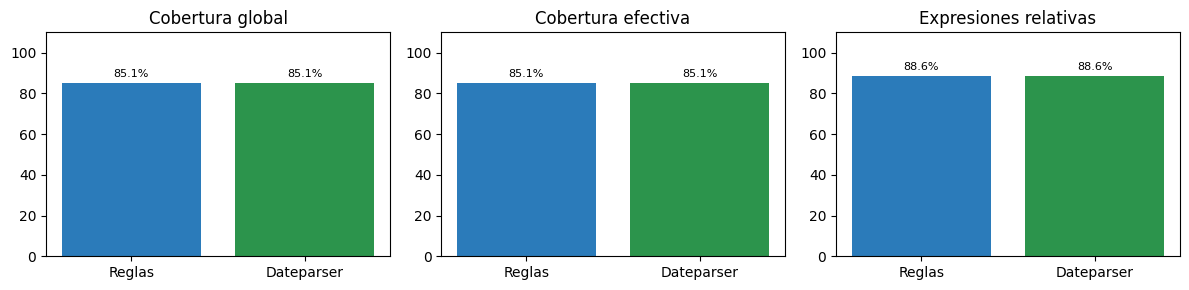

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

titles = ["Cobertura global", "Cobertura efectiva", "Expresiones relativas"]
values = [
    [cov_reglas, cov_dp],
    [fail_reglas, fail_dp],
    [rel_reglas, rel_dp]
]

for i in range(3):
    bars = axes[i].bar(
        ["Reglas", "Dateparser"],
        values[i],
        color=[color_reglas, color_dp]
    )

    # margen superior
    axes[i].set_ylim(0, 110)

    axes[i].set_title(titles[i])

    for bar in bars:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            height + 2,
            f"{height:.1f}%",
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.tight_layout()
plt.show()

La representación visual confirma que ambos enfoques presentan un comportamiento completamente equivalente en las tres dimensiones analizadas. Tanto en la cobertura global como en la cobertura efectiva, los resultados son idénticos, reflejando una capacidad similar para interpretar el conjunto completo de expresiones temporales.

Asimismo, en el análisis específico de expresiones relativas se observa una ligera mejora respecto a la cobertura global, lo que indica que ambos métodos son más eficaces en la interpretación de este tipo de expresiones. En conjunto, los resultados evidencian que las diferencias entre enfoques no radican en el rendimiento cuantitativo, sino en la flexibilidad y capacidad de adaptación del sistema basado en reglas.

### 6.4 Refinamiento de reglas de normalización

En base al análisis realizado en el apartado **6.3.3 Análisis de casos no interpretados por cada método**, se identificaron expresiones temporales que no eran correctamente interpretadas por ninguno de los enfoques, a pesar de corresponder a referencias temporales válidas dentro del contexto del mensaje.

En particular, se detectaron expresiones relativas difusas como “*en estos días*”, “*en estos momentos*” o “*actualmente*”, cuya interpretación no es gestionada de forma directa ni por las reglas iniciales ni por la librería externa. Dado que estas expresiones hacen referencia al momento presente, se ha optado por definir una estrategia de normalización basada en su aproximación a la fecha de recepción del mensaje.

Para ello, se implementa una función específica que amplía el conjunto de reglas de normalización, permitiendo capturar este tipo de expresiones y asignarles una fecha coherente dentro del contexto del sistema. Esta función ha sido diseñada de forma modular, de manera que pueda ser fácilmente extendida en futuras iteraciones conforme se identifiquen nuevos patrones en los datos.

#### 6.4.1 Definición de reglas adicionales para expresiones relativas difusas

In [162]:
def normalize_relative_expressions(text: str, fecha_recepcion: datetime):
    
    t = text.lower().strip()
    
    # Expresiones relativas difusas → aproximación a fecha de recepción
    if "estos días" in t:
        return fecha_recepcion
    
    elif "estos momentos" in t:
        return fecha_recepcion
    
    elif "actualmente" in t:
        return fecha_recepcion
    
    return None

### 6.5 Evaluación tras la mejora

Una vez incorporadas las nuevas reglas de normalización orientadas a la interpretación de expresiones relativas difusas, se procede a evaluar nuevamente el comportamiento del sistema. El objetivo de esta fase es analizar el impacto de las mejoras introducidas sobre el rendimiento global del enfoque basado en reglas, así como comprobar si se produce una reducción efectiva en los casos no interpretados.

Para ello, se reaplican las métricas definidas previamente, permitiendo realizar una comparación coherente con los resultados obtenidos en la sección anterior y valorar la contribución real de las modificaciones implementadas.

#### 6.5.1 Aplicación de las nuevas reglas

In [163]:
def build_normalization_df_refined(nlp_output_dir, fecha_recepcion):
    results = []

    for file in nlp_output_dir.glob("*.json"):
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)

        for ent in data.get("entities", []):

            if ent.get("label") != "fecha_evento":
                continue

            text = ent.get("text", "")

            # -----------------------------
            # Pipeline correcto (con matched)
            # -----------------------------
            result = normalize_explicit_date(text, fecha_recepcion)

            if not result["matched"]:
                result = normalize_relative_date(text, fecha_recepcion)

            if not result["matched"]:
                result = normalize_ambiguous_date(text, fecha_recepcion)

            if not result["matched"]:
                fecha_extra = normalize_relative_expressions(text, fecha_recepcion)

                if fecha_extra is not None:
                    result = {
                        "fecha_evento": fecha_extra.date().isoformat(),
                        "fecha_evento_fin": None,
                        "granularidad_fecha_evento": "dia",
                        "matched": True
                    }

            # Formato final
            fecha_reglas = (
                pd.to_datetime(result["fecha_evento"]).date()
                if result["matched"] and result["fecha_evento"] is not None
                else None
            )

            # -----------------------------
            # Dateparser
            # -----------------------------
            fecha_dp = dateparser.parse(
                text,
                languages=["es"],
                settings={"RELATIVE_BASE": fecha_recepcion}
            )

            fecha_dp = fecha_dp.date() if fecha_dp else None

            # -----------------------------
            # Dataset
            # -----------------------------
            results.append({
                "text": text,
                "metodo": "reglas",
                "fecha_recepcion": fecha_recepcion.date(),
                "fecha_calculada": fecha_reglas
            })

            results.append({
                "text": text,
                "metodo": "dateparser",
                "fecha_recepcion": fecha_recepcion.date(),
                "fecha_calculada": fecha_dp
            })

    df_refined = pd.DataFrame(results)
    df_refined["fecha_calculada"] = pd.to_datetime(df_refined["fecha_calculada"]).dt.date
    df_refined = df_refined.sort_values(by=["text", "metodo"]).reset_index(drop=True)

    return df_refined

#### 6.5.2 Comparación de resultados

Se presentan los resultados obtenidos tras la aplicación de las reglas refinadas, comparándolos con el comportamiento previo del sistema. El análisis se centra en las métricas de cobertura, capacidad de interpretación y tratamiento de expresiones relativas, con el objetivo de determinar si las mejoras introducidas se traducen en un incremento del rendimiento.

Asimismo, se evalúa si la incorporación de nuevas reglas permite resolver los casos previamente no interpretados, manteniendo la coherencia del sistema y sin introducir errores adicionales en la normalización.

##### 6.5.1.1 Visualización de resultados individuales por enfoque

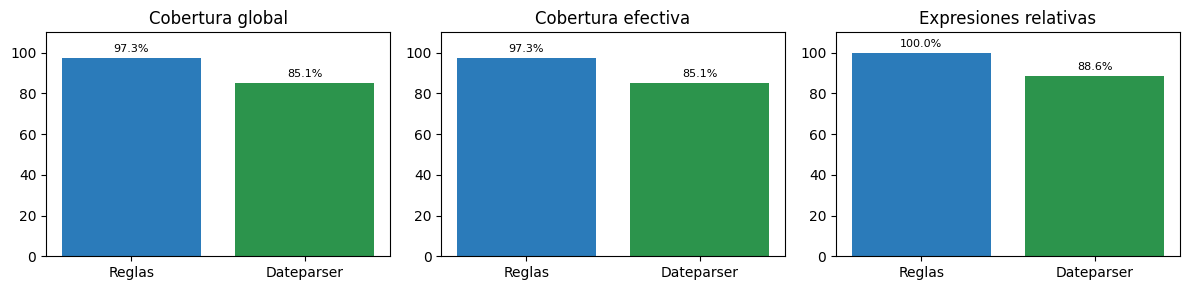

In [164]:
# -----------------------------
# Construir dataset refinado
# -----------------------------
df_refined = build_normalization_df_refined(
    nlp_output_dir,
    datetime(2026, 7, 25)
)

# -----------------------------
# Recalcular métricas
# -----------------------------
coverage_refined = analyze_coverage(df_refined)
fail_refined, _ = analyze_failures(df_refined)
relativas_refined = analyze_relative_expressions(df_refined)

# -----------------------------
# Extraer métricas
# -----------------------------
cov_reglas = coverage_refined.loc[
    coverage_refined["metodo"] == "reglas",
    "porcentaje_cobertura"
].values[0]

cov_dp = coverage_refined.loc[
    coverage_refined["metodo"] == "dateparser",
    "porcentaje_cobertura"
].values[0]

fail_reglas = 100 - fail_refined.loc[
    fail_refined["metodo"] == "reglas",
    "porcentaje_fallo"
].values[0]

fail_dp = 100 - fail_refined.loc[
    fail_refined["metodo"] == "dateparser",
    "porcentaje_fallo"
].values[0]

rel_reglas = relativas_refined.loc[
    relativas_refined["metodo"] == "reglas",
    "porcentaje_cobertura"
].values[0]

rel_dp = relativas_refined.loc[
    relativas_refined["metodo"] == "dateparser",
    "porcentaje_cobertura"
].values[0]

# -----------------------------
# Gráfico
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

titles = ["Cobertura global", "Cobertura efectiva", "Expresiones relativas"]
values = [
    [cov_reglas, cov_dp],
    [fail_reglas, fail_dp],
    [rel_reglas, rel_dp]
]

for i in range(3):
    bars = axes[i].bar(
        ["Reglas", "Dateparser"],
        values[i],
        color=[color_reglas, color_dp]
    )

    axes[i].set_ylim(0, 110)
    axes[i].set_title(titles[i])

    for bar in bars:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            height + 2,
            f"{height:.1f}%",
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.tight_layout()
plt.show()

Los resultados muestran una mejora significativa del enfoque basado en reglas tras la incorporación de nuevas heurísticas, alcanzando un 97.3% de cobertura global y efectiva, frente al 85.1% mantenido por la librería externa. Esta diferencia evidencia el impacto directo de las reglas añadidas en la reducción de casos no interpretados.

En el caso específico de las expresiones relativas, el sistema basado en reglas alcanza una cobertura del 100%, resolviendo completamente este tipo de expresiones, mientras que dateparser mantiene un rendimiento inferior. Este resultado confirma que las mejoras introducidas han permitido capturar correctamente las expresiones previamente no interpretadas.

##### 6.5.1.2 Análisis comparativo mediante diferencias entre enfoques

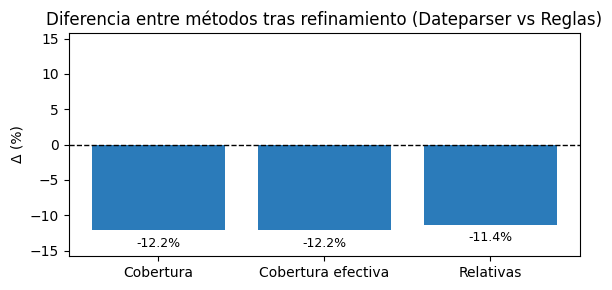

In [165]:
# -----------------------------
# Diferencia entre métodos (pipeline refinado)
# -----------------------------
labels = ["Cobertura", "Cobertura efectiva", "Relativas"]

diff_values = [
    cov_dp - cov_reglas,
    fail_dp - fail_reglas,
    rel_dp - rel_reglas
]

colors_diff = [color_dp if v >= 0 else color_reglas for v in diff_values]

plt.figure(figsize=(6,3))

bars = plt.bar(labels, diff_values, color=colors_diff)

plt.axhline(0, color="black", linewidth=1, linestyle="--")

# Margen dinámico ajustado
max_abs = max(abs(min(diff_values)), abs(max(diff_values)))

if max_abs == 0:
    max_abs = 1  # margen mínimo para evitar error

plt.ylim(-max_abs * 1.3, max_abs * 1.3)

for bar in bars:
    height = bar.get_height()
    offset = max_abs * 0.07
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + (offset if height >= 0 else -offset),
        f"{height:.1f}%",
        ha='center',
        va='bottom' if height >= 0 else 'top',
        fontsize=9
    )

plt.ylabel("Δ (%)")
plt.title("Diferencia entre métodos tras refinamiento (Dateparser vs Reglas)")

plt.tight_layout()
plt.show()

El análisis de diferencias tras el refinamiento muestra una mejora clara del enfoque basado en reglas frente a la librería externa, reflejada en valores negativos al representar la resta (*dateparser − reglas*). Esta diferencia indica que las reglas superan sistemáticamente a dateparser en todas las métricas evaluadas.

En particular, se observa una mejora aproximada del 12% en cobertura global y cobertura efectiva, así como una mejora superior al 11% en la interpretación de expresiones relativas. Estos resultados evidencian que la incorporación de reglas específicas ha tenido un impacto directo y significativo en el rendimiento del sistema.

### 6.6 Conclusiones de la normalización temporal

El análisis realizado muestra que, en una fase inicial, tanto el enfoque basado en reglas como la librería externa *dateparser* presentan un comportamiento equivalente en términos de cobertura y capacidad de interpretación. Ambos métodos son capaces de resolver correctamente expresiones temporales simples, pero comparten limitaciones ante expresiones ambiguas o difusas.

Sin embargo, tras el refinamiento del sistema basado en reglas, se observa una mejora significativa en todas las métricas evaluadas, especialmente en la reducción de casos no interpretados y en la correcta resolución de expresiones relativas. Este resultado evidencia que la incorporación de conocimiento específico del dominio permite optimizar de forma efectiva el proceso de normalización.

Además, el enfoque basado en reglas ofrece ventajas relevantes frente al uso de librerías externas. Por un lado, permite modelar explícitamente distintas granularidades temporales mediante el uso de rangos, lo que resulta especialmente útil en expresiones como semanas, meses o años. Por otro, proporciona un mayor control sobre la interpretación de las expresiones, facilitando su adaptación progresiva a nuevos patrones lingüísticos detectados en los datos.

Estos resultados justifican la elección del enfoque basado en reglas como solución principal para la normalización temporal en este sistema. Su capacidad de mejora incremental, su flexibilidad y su adecuación al contexto específico del dominio lo convierten en una alternativa más robusta y escalable frente a soluciones genéricas.

## 7. Normalización de magnitudes y unidades

En esta sección se aborda la normalización de las entidades asociadas a magnitudes detectadas por el módulo NER. Estas entidades incluyen expresiones numéricas vinculadas a cantidades, superficies y distancias, como `20 plantas`, `3 hectáreas` o `50 metros`. La normalización de este tipo de información es necesaria para transformar expresiones variables del lenguaje natural en una representación estructurada y homogénea, separando el valor numérico, la unidad original y la unidad normalizada cuando esta puede resolverse de forma fiable.

El proceso se basa en la extracción del valor numérico, la identificación de la unidad expresada en el texto y su comparación con un mapa de unidades definido manualmente. Cuando la unidad se encuentra contemplada en dicho mapa, se transforma a una forma canónica. En cambio, si se detecta un valor numérico pero la unidad no está validada, la magnitud se conserva como información parcialmente normalizada, manteniendo la unidad original y marcando explícitamente su estado. De este modo, se evita perder información potencialmente útil sin asumir conversiones no justificadas.

### 7.1 Validación y filtrado de entidades numéricas

Antes de proceder a la normalización de cantidades y unidades, se realiza una fase de validación de las entidades detectadas por el módulo NER. Este paso es necesario debido a la posible presencia de errores de etiquetado, donde expresiones que no corresponden a magnitudes físicas son clasificadas incorrectamente como cantidades o superficies.

Para garantizar la consistencia del sistema, se filtran aquellas entidades cuya unidad no es coherente con el tipo semántico asignado, evitando así la propagación de errores en las etapas posteriores de normalización.

#### 7.1.1 Definición de reglas de validación

Antes de filtrar las entidades numéricas, se define un conjunto de unidades válidas para cada tipo semántico. Este mapa permite comprobar si la unidad detectada es coherente con la etiqueta asignada por el modelo NER.

##### 7.1.1.1 Carga del mapa de normalización de unidades

Se carga el mapa de normalización de unidades definido en el archivo de configuración. Este recurso contiene las unidades canónicas y sus variantes textuales asociadas, permitiendo centralizar las reglas de validación y normalización en un único punto del sistema.

In [166]:
# Cargar mapa de normalización de unidades
with open(unit_normalization_map_path, "r", encoding="utf-8") as f:
    unit_normalization_map = json.load(f)

print("=== Mapa de normalización de unidades cargado ===")
print(f"Tipos de magnitud definidos: {list(unit_normalization_map.keys())}")

=== Mapa de normalización de unidades cargado ===
Tipos de magnitud definidos: ['superficie', 'distancia', 'cantidad', 'volumen', 'masa']


##### 7.1.1.2 Construcción de unidades válidas por tipo de magnitud

A partir del mapa de unidades, se construye automáticamente el conjunto de unidades válidas para cada tipo de magnitud. De este modo, el proceso de validación utiliza la misma fuente de información que la normalización final, evitando duplicar reglas en el código.

In [167]:
def build_valid_units_by_label(unit_normalization_map: dict) -> dict:
    """
    Construye el mapa de unidades válidas por tipo de magnitud a partir
    del mapa de normalización de unidades.
    """
    
    valid_units_by_label = {}
    
    for label, canonical_units in unit_normalization_map.items():
        valid_units = []
        
        for canonical_unit, variants in canonical_units.items():
            valid_units.append(canonical_unit)
            valid_units.extend(variants)
        
        valid_units_by_label[label] = sorted(set(
            normalize_text_for_matching(unit)
            for unit in valid_units
        ))
    
    return valid_units_by_label


valid_units_by_label = build_valid_units_by_label(unit_normalization_map)

print("=== Unidades válidas por tipo de magnitud ===")
for label, units in valid_units_by_label.items():
    print(f"{label}: {units}")

=== Unidades válidas por tipo de magnitud ===
superficie: ['ha', 'hectarea', 'hectareas', 'm2', 'metro cuadrado', 'metros cuadrados']
distancia: ['centimetro', 'centimetros', 'cm', 'm', 'metro', 'metros']
cantidad: ['arbol', 'arboles', 'planta', 'plantas', 'unidad', 'unidades']
volumen: ['l', 'litro', 'litros', 'mililitro', 'mililitros', 'ml']
masa: ['g', 'gramo', 'gramos', 'kg', 'kilo', 'kilogramo', 'kilogramos', 'kilos']


##### 7.1.1.3 Filtrado de entidades numéricas por coherencia unidad-etiqueta

Se define una función de filtrado que conserva únicamente aquellas entidades cuya unidad textual es coherente con la etiqueta semántica asignada por el modelo NER. Esta validación permite reducir errores derivados de asignaciones incorrectas del modelo.

In [168]:
def filter_quantity_entities(entities):
    """
    Filtra entidades numéricas comprobando la coherencia entre
    la etiqueta semántica y las unidades válidas asociadas.
    """
    
    filtered = []

    for ent in entities:
        label = ent.get("label")
        text_norm = normalize_text_for_matching(ent.get("text", ""))

        if label not in valid_units_by_label:
            continue

        valid_units = valid_units_by_label[label]

        has_valid_unit = any(
            re.search(rf"\b{unit}\b", text_norm)
            for unit in valid_units
        )

        if has_valid_unit:
            filtered.append(ent)

    return filtered

#### 7.1.2 Aplicación del filtrado de entidades

El proceso de validación descrito en el apartado anterior se aplica directamente sobre las entidades generadas por el módulo NER, utilizando como entrada los archivos en formato JSON producidos en la etapa previa del *pipeline*.

Para cada entidad detectada, se evalúa la coherencia entre el tipo semántico asignado por el modelo y la unidad presente en el texto. Aquellas entidades cuya unidad no es consistente con el tipo esperado son descartadas, evitando así la propagación de errores hacia las etapas posteriores del sistema.

Este filtrado se realiza de manera iterativa sobre cada registro, garantizando que únicamente las entidades numéricas válidas sean consideradas en el proceso de extracción y normalización. De este modo, se mejora la calidad del conjunto de datos intermedio y se reduce el impacto de posibles errores del modelo NER en el resultado final.

#### 7.1.3 Extracción de valor y unidad

En esta fase se realiza la extracción del valor numérico y su correspondiente unidad a partir de las entidades previamente validadas. Este proceso contempla tanto valores expresados en formato numérico como aquellos representados en lenguaje natural.

Para ello, se incorporan reglas específicas que permiten interpretar numerales básicos y decenas, incluyendo también combinaciones simples como expresiones compuestas del tipo “treinta y cinco”. Esta decisión responde a la necesidad de cubrir los patrones más frecuentes observados en los datos reales, garantizando una correcta interpretación en la mayoría de los casos.

No se contempla la implementación completa del sistema numérico del lenguaje natural (como centenas o miles en formato textual), ya que estos valores aparecen predominantemente en formato numérico dentro del conjunto de datos analizado. De este modo, se evita una sobreingeniería innecesaria, priorizando un enfoque pragmático centrado en la cobertura efectiva del dominio de aplicación.

##### 7.1.3.1 Definición de numerales básicos

In [169]:
quantity_number_words = {
    "un": 1, "una": 1, "uno": 1,
    "dos": 2, "tres": 3, "cuatro": 4,
    "cinco": 5, "seis": 6, "siete": 7,
    "ocho": 8, "nueve": 9, "diez": 10,
    "once": 11, "doce": 12,
    "trece": 13, "catorce": 14,
    "quince": 15
}

##### 7.1.3.2 Definición de decenas

In [170]:
tens = {
    "veinte": 20,
    "treinta": 30,
    "cuarenta": 40,
    "cincuenta": 50,
    "sesenta": 60,
    "setenta": 70,
    "ochenta": 80,
    "noventa": 90
}

##### 7.1.3.3 Lógica de extracción de valores numéricos

In [171]:
def extract_value_unit(text: str):
    
    # Normalización previa del texto
    text_norm = normalize_text_for_matching(text)

    # -----------------------------
    # 1. Números en formato dígito
    # -----------------------------
    match = re.search(r"\d+([.,]\d+)?", text_norm)
    
    if match:
        value = float(match.group().replace(",", "."))
        unit = text_norm.replace(match.group(), "").strip()
        return value, unit

    # -----------------------------
    # 2. Numerales básicos
    # -----------------------------
    for word in sorted(quantity_number_words, key=len, reverse=True):
        if re.search(rf"\b{word}\b", text_norm):
            unit = re.sub(rf"\b{word}\b", "", text_norm).strip()
            return quantity_number_words[word], unit

    # -----------------------------
    # 3. Decenas simples (ej: "treinta")
    # -----------------------------
    for ten_word, ten_value in tens.items():
        if re.search(rf"\b{ten_word}\b", text_norm):
            unit = re.sub(rf"\b{ten_word}\b", "", text_norm).strip()
            return ten_value, unit

    # -----------------------------
    # 4. Numerales compuestos (ej: "treinta y cinco")
    # -----------------------------
    for ten_word, ten_value in tens.items():

        match = re.search(rf"\b{ten_word}\s+y\s+(\w+)\b", text_norm)

        if match:
            unit_word = match.group(1)

            if unit_word in quantity_number_words:
                value = ten_value + quantity_number_words[unit_word]

                unit = re.sub(
                    rf"\b{ten_word}\s+y\s+{unit_word}\b",
                    "",
                    text_norm
                ).strip()

                return value, unit

    # -----------------------------
    # 5. Sin valor explícito
    # -----------------------------
    return None, text_norm

#### 7.1.4 Construcción del conjunto de entidades numéricas antes del filtrado

Se construye un conjunto inicial con todas las entidades numéricas detectadas por el módulo NER antes de aplicar ningún filtrado. Este conjunto permite analizar errores de etiquetado y comparar posteriormente el impacto del proceso de validación.

In [172]:
# Construcción del conjunto de entidades numéricas antes del filtrado
raw_results = []

numeric_labels = {"superficie", "cantidad", "volumen", "masa", "distancia"}

for file in nlp_output_dir.glob("*.json"):
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    audio_id = data.get("audio_id")
    
    for ent in data.get("entities", []):
        label = ent.get("label")
        
        if label not in numeric_labels:
            continue
        
        text = ent.get("text", "")
        text_norm = normalize_text_for_matching(text)
        
        raw_results.append({
            "audio_id": audio_id,
            "text": text,
            "text_norm": text_norm,
            "label": label
        })

df_raw = pd.DataFrame(raw_results)

#### 7.1.5 Aplicación del filtrado y construcción del conjunto de magnitudes validado

In [173]:
def process_quantities(nlp_output_dir):
    
    results = []

    numeric_labels = {"superficie", "cantidad", "volumen", "masa", "distancia"}

    for file in nlp_output_dir.glob("*.json"):
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)

        for ent in data.get("entities", []):

            label = ent.get("label")

            # FILTRO POR TIPO
            if label not in numeric_labels:
                continue

            # FILTRO POR UNIDAD
            filtered = filter_quantity_entities([ent])
            if not filtered:
                continue

            text = ent.get("text", "")

            # EXTRACCIÓN
            value, unit = extract_value_unit(text)

            results.append({
                "audio_id": data.get("audio_id"),
                "text": text,
                "label": label,
                "valor": value,
                "unidad_raw": unit
            })

    return pd.DataFrame(results)

df_quantities = process_quantities(nlp_output_dir)

#### 7.1.6 Análisis exploratorio de resultados

Con el objetivo de evaluar el comportamiento del proceso de validación y extracción de entidades numéricas, se realiza un análisis exploratorio en tres fases: antes del filtrado, tras la aplicación del mecanismo de validación y sobre el conjunto de datos resultante. Este análisis permite identificar errores del modelo NER, cuantificar el impacto del filtrado y caracterizar el conjunto de datos limpio utilizado en las etapas posteriores del *pipeline*.

##### 7.1.6.1 Análisis previo al filtrado (errores NER)

In [174]:
print("\n--- ENTIDADES NUMÉRICAS (ANTES DEL FILTRADO) ---")

print(f"\nTotal entidades numéricas detectadas: {len(df_raw)}")

print("\n--- Conteo por tipo (ANTES) ---")
display(df_raw["label"].value_counts().to_frame(name="conteo"))

print("\n--- Inconsistencias NER ---")

inconsistencias_raw = df_raw[
    (df_raw["label"] == "superficie") &
    (~df_raw["text_norm"].str.contains("hectarea|ha|m2", na=False))
]

print(f"Inconsistencias detectadas: {len(inconsistencias_raw)}")
display(inconsistencias_raw)


--- ENTIDADES NUMÉRICAS (ANTES DEL FILTRADO) ---

Total entidades numéricas detectadas: 75

--- Conteo por tipo (ANTES) ---


,conteo
label,
superficie,65
distancia,5
cantidad,5



--- Inconsistencias NER ---
Inconsistencias detectadas: 5


,audio_id,text,text_norm,label
21,AUDIO_00051,18 horas,18 horas,superficie
37,AUDIO_00091,18 horas,18 horas,superficie
50,AUDIO_00125,Olímpico.,olimpico,superficie
52,AUDIO_00131,18 horas,18 horas,superficie
72,AUDIO_00192,11 tareas,11 tareas,superficie


El análisis inicial muestra que el modelo NER identifica un total de 75 entidades numéricas, con una distribución claramente dominada por la categoría de superficie. No obstante, se detectan inconsistencias relevantes derivadas de errores de etiquetado.

En particular, se identifican cinco casos en los que expresiones como “*18 horas*” o “*11 tareas*” son clasificadas incorrectamente como superficies, así como la presencia de términos sin contenido semántico adecuado como “*Olímpico*”. Estos resultados evidencian que, si bien el modelo NER es capaz de capturar la mayoría de las entidades relevantes, presenta limitaciones en la asignación correcta del tipo semántico en determinados contextos.

##### 7.1.6.2 Evaluación del impacto del filtrado

In [175]:
print("\n--- IMPACTO DEL FILTRADO ---")

total_before = len(df_raw)
total_after = len(df_quantities)
eliminadas = total_before - total_after

print(f"Antes del filtrado: {total_before}")
print(f"Después del filtrado: {total_after}")
print(f"Entidades eliminadas: {eliminadas}")

porcentaje_eliminado = (eliminadas / total_before) * 100 if total_before > 0 else 0

print(f"Porcentaje eliminado: {porcentaje_eliminado:.2f}%")


--- IMPACTO DEL FILTRADO ---
Antes del filtrado: 75
Después del filtrado: 66
Entidades eliminadas: 9
Porcentaje eliminado: 12.00%


Tras la aplicación del mecanismo de validación basado en la coherencia entre tipo y unidad, el número total de entidades se reduce de 75 a 66, lo que supone la eliminación de 9 entidades, equivalente a un 12% del total inicial.

Esta reducción corresponde principalmente a la eliminación de entidades inconsistentes detectadas en la fase previa, lo que confirma la efectividad del filtrado implementado. En este sentido, el proceso no solo actúa como mecanismo de limpieza, sino que introduce una mejora cuantificable en la calidad del conjunto de datos, evitando la propagación de errores hacia las etapas posteriores del sistema.

##### 7.1.6.3 Análisis del conjunto de datos limpio

In [176]:
print("\n=== Conjunto de magnitudes validado ===")
print(f"Entidades válidas tras filtrado: {len(df_quantities)}")

print("\n--- Distribución por tipo de magnitud ---")
display(df_quantities["label"].value_counts().to_frame(name="conteo"))

print("\n--- Distribución por unidad extraída ---")
display(df_quantities["unidad_raw"].value_counts().to_frame(name="conteo"))

# Casos sin valor numérico explícito
no_valor = df_quantities[df_quantities["valor"].isna()]

print("\n--- Casos sin valor numérico explícito ---")

if len(no_valor) > 0:
    print(f"Casos detectados: {len(no_valor)}")
    display(no_valor)
else:
    print("No se han detectado casos sin valor numérico explícito.")

# Validación final de coherencia entre tipo semántico y unidad
print("\n--- Validación final de coherencia tipo-unidad ---")

inconsistencias_clean = []

for _, row in df_quantities.iterrows():
    label = row["label"]
    unidad_raw = normalize_text_for_matching(row["unidad_raw"])
    
    valid_units = valid_units_by_label.get(label, [])
    
    is_valid_unit = any(
        re.search(rf"\b{unit}\b", unidad_raw)
        for unit in valid_units
    )
    
    if not is_valid_unit:
        inconsistencias_clean.append(row)

df_inconsistencias_clean = pd.DataFrame(inconsistencias_clean)

if not df_inconsistencias_clean.empty:
    print(f"Inconsistencias detectadas: {len(df_inconsistencias_clean)}")
    display(df_inconsistencias_clean)
else:
    print("No se han detectado inconsistencias tras el filtrado.")

print("\n--- Ejemplos del conjunto validado ---")
display(df_quantities.head(20))


=== Conjunto de magnitudes validado ===
Entidades válidas tras filtrado: 66

--- Distribución por tipo de magnitud ---


,conteo
label,
superficie,60
distancia,4
cantidad,2



--- Distribución por unidad extraída ---


,conteo
unidad_raw,
hectareas,58
centimetros,3
plantas,2
metro,1
5 hectareas,1
hectarea,1



--- Casos sin valor numérico explícito ---
No se han detectado casos sin valor numérico explícito.

--- Validación final de coherencia tipo-unidad ---
No se han detectado inconsistencias tras el filtrado.

--- Ejemplos del conjunto validado ---


,audio_id,text,label,valor,unidad_raw
0,AUDIO_00002,7 hectáreas,superficie,7.0,hectareas
1,AUDIO_00003,30 centímetros,distancia,30.0,centimetros
2,AUDIO_00005,tres hectáreas,superficie,3.0,hectareas
3,AUDIO_00008,cuatro hectáreas,superficie,4.0,hectareas
4,AUDIO_00012,9 hectáreas,superficie,9.0,hectareas
5,AUDIO_00015,seis hectáreas,superficie,6.0,hectareas
6,AUDIO_00022,5 hectáreas,superficie,5.0,hectareas
7,AUDIO_00025,tres hectáreas,superficie,3.0,hectareas
8,AUDIO_00028,8 hectáreas,superficie,8.0,hectareas
9,AUDIO_00032,6 hectáreas,superficie,6.0,hectareas


El conjunto de magnitudes validado contiene un total de 66 entidades tras la aplicación del filtrado. La distribución por tipo muestra una clara predominancia de la categoría `superficie`, con 60 entidades, seguida por `distancia`, con 4 entidades, y `cantidad`, con 2 entidades. Esta distribución es coherente con el dominio agrícola del conjunto de datos, donde las referencias a extensión de parcelas o fincas aparecen con mayor frecuencia que otras magnitudes.

En cuanto a las unidades extraídas, se observa un predominio muy marcado de `hectareas`, presente en 58 casos, junto con apariciones minoritarias de `centimetros`, `plantas`, `metro` y `hectarea`. También se identifica un caso en el que la unidad extraída conserva parte del texto original (`5 hectareas`), lo que no supone una inconsistencia semántica entre tipo y unidad, pero sí evidencia la necesidad de una normalización posterior de unidades antes de generar la estructura final.

No se han detectado casos sin valor numérico explícito, lo que indica que todas las magnitudes conservadas tras el filtrado incluyen un valor interpretable. La validación final de coherencia entre tipo semántico y unidad confirma que no existen inconsistencias tras el filtrado, por lo que el conjunto resultante puede considerarse adecuado para la siguiente fase de normalización.

Los ejemplos revisados muestran una correcta extracción de valores expresados tanto en formato numérico como en lenguaje natural, incluyendo casos como “tres hectáreas”, “seis hectáreas”, “30 centímetros” o “4500 plantas”. En conjunto, los resultados muestran que el proceso de validación y extracción permite transformar las salidas del modelo NER en un conjunto de magnitudes estructurado y suficientemente consistente para su posterior normalización.

### 7.2 Normalización de unidades

Una vez extraído el valor numérico y la unidad textual, se normalizan las unidades detectadas a partir del mapa definido en configuración. El objetivo es convertir variantes como `hectarea`, `hectareas` o `ha` en una forma canónica única, evitando inconsistencias en el JSON final.

#### 7.2.1 Limpieza de unidades extraídas

Antes de aplicar el mapeo canónico, se limpia la unidad extraída para eliminar posibles residuos numéricos o espacios duplicados. Esta fase permite corregir casos en los que la unidad conserva parte del texto original, como `5 hectareas`.

In [177]:
def clean_unit_text(unit_raw: str) -> str:
    """
    Limpia la unidad extraída antes de aplicar el mapeo canónico.
    """
    
    unit_clean = normalize_empty_value(unit_raw)
    
    if unit_clean is None:
        return None
    
    unit_clean = normalize_text_for_matching(unit_clean)
    
    # Eliminación de posibles residuos numéricos
    unit_clean = re.sub(r"\d+([.,]\d+)?", "", unit_clean)
    
    # Limpieza de espacios
    unit_clean = re.sub(r"\s+", " ", unit_clean).strip()
    
    return unit_clean if unit_clean != "" else None

#### 7.2.2 Construcción del índice de unidades canónicas

A partir del mapa de normalización de unidades, se construye un índice plano que relaciona cada variante textual con su unidad canónica y su tipo de magnitud. Este índice permite realizar la normalización de forma directa y consistente.

In [178]:
def build_unit_normalization_index(unit_normalization_map: dict) -> dict:
    """
    Construye un índice plano de variantes de unidades a formas canónicas.
    """
    
    unit_index = {}
    
    for magnitude_type, canonical_units in unit_normalization_map.items():
        for canonical_unit, variants in canonical_units.items():
            
            # Incluir también la unidad canónica como variante válida
            all_variants = [canonical_unit] + variants
            
            for variant in all_variants:
                variant_norm = normalize_text_for_matching(variant)
                
                unit_index[variant_norm] = {
                    "tipo": magnitude_type,
                    "unidad": canonical_unit
                }
    
    return unit_index


unit_normalization_index = build_unit_normalization_index(unit_normalization_map)

print("=== Índice de normalización de unidades ===")
print(f"Variantes de unidades indexadas: {len(unit_normalization_index)}")

=== Índice de normalización de unidades ===
Variantes de unidades indexadas: 32


#### 7.2.3 Normalización de unidad a forma canónica

Se define la función principal de normalización de unidades. Si la unidad aparece en el índice, se devuelve su forma canónica. Si no se encuentra, se conserva la unidad limpia para no perder información.

In [179]:
def normalize_unit(unit_raw: str) -> str:
    """
    Normaliza una unidad textual a su forma canónica.
    """
    
    unit_clean = clean_unit_text(unit_raw)
    
    if unit_clean is None:
        return None
    
    match = unit_normalization_index.get(unit_clean)
    
    if match is None:
        return unit_clean
    
    return match["unidad"]

#### 7.2.4 Comprobación de normalización de unidades

Se comprueba la normalización de las unidades extraídas en el conjunto validado, verificando que las variantes textuales se transforman correctamente en unidades canónicas.

In [183]:
df_unit_review = df_quantities.copy()

df_unit_review["unidad_limpia"] = df_unit_review["unidad_raw"].apply(clean_unit_text)
df_unit_review["unidad_normalizada"] = df_unit_review["unidad_raw"].apply(normalize_unit)

df_unit_review["unidad_mapeada"] = df_unit_review["unidad_limpia"].isin(unit_normalization_index.keys())

print("=== Revisión de normalización de unidades ===")
print(f"Unidades originales diferentes: {df_unit_review['unidad_raw'].nunique()}")
print(f"Unidades limpias diferentes: {df_unit_review['unidad_limpia'].nunique()}")
print(f"Unidades normalizadas diferentes: {df_unit_review['unidad_normalizada'].nunique()}")
print(f"Unidades no mapeadas explícitamente: {(~df_unit_review['unidad_mapeada']).sum()}")

print("\n--- Equivalencias unidad_raw → unidad_limpia → unidad_normalizada ---")
display(
    df_unit_review[["unidad_raw", "unidad_limpia", "unidad_normalizada", "unidad_mapeada"]]
    .drop_duplicates()
    .sort_values(by=["unidad_normalizada", "unidad_raw"])
    .reset_index(drop=True)
)

=== Revisión de normalización de unidades ===
Unidades originales diferentes: 6
Unidades limpias diferentes: 5
Unidades normalizadas diferentes: 4
Unidades no mapeadas explícitamente: 0

--- Equivalencias unidad_raw → unidad_limpia → unidad_normalizada ---


,unidad_raw,unidad_limpia,unidad_normalizada,unidad_mapeada
0,centimetros,centimetros,cm,True
1,5 hectareas,hectareas,ha,True
2,hectarea,hectarea,ha,True
3,hectareas,hectareas,ha,True
4,metro,metro,m,True
5,plantas,plantas,plantas,True


Los resultados muestran que el proceso de normalización de unidades reduce la variabilidad textual presente en las unidades extraídas. Inicialmente se identifican 6 formas diferentes en `unidad_raw`, que se reducen a 5 tras la limpieza y finalmente a 4 unidades canónicas después del mapeo.

La reducción de unidades originales a unidades limpias se debe principalmente a la corrección del caso `5 hectareas`, donde la unidad conservaba un residuo numérico procedente de la extracción inicial. La función de limpieza elimina este valor residual y transforma correctamente la expresión en `hectareas`.

Posteriormente, el mapeo canónico agrupa variantes equivalentes bajo una misma representación. Así, `hectarea`, `hectareas` y `5 hectareas` se normalizan como `ha`, mientras que `centimetros` se transforma en `cm` y `metro` en `m`. La unidad `plantas` se mantiene sin cambios, al corresponder ya con la forma canónica definida para entidades de conteo.

No se detectan unidades no mapeadas explícitamente, lo que confirma que todas las unidades presentes en el conjunto validado están contempladas en el mapa de normalización. Este resultado indica que el catálogo de unidades definido es suficiente para cubrir los datos analizados y permite generar magnitudes homogéneas para su incorporación posterior al JSON final.

### 7.3 Clasificación semántica de magnitudes

Una vez normalizadas las unidades, se define la clasificación semántica que se utilizará en la salida final del campo `magnitudes`. La etiqueta procedente del módulo NER se toma como punto de partida, pero puede transformarse a una denominación canónica interna más adecuada para el JSON final.

En particular, la etiqueta `cantidad` se convierte en `conteo`, ya que en el esquema de salida representa recuentos de elementos físicos, como plantas, árboles o unidades, y no una magnitud genérica.

#### 7.3.1 Definición del mapa de tipos de magnitud

In [184]:
magnitude_type_map = {
    "cantidad": "conteo",
    "superficie": "superficie",
    "volumen": "volumen",
    "masa": "masa",
    "distancia": "distancia"
}

#### 7.3.2 Normalización del tipo de magnitud

In [185]:
def normalize_magnitude_type(label: str) -> str:
    """
    Normaliza la etiqueta semántica de una magnitud para la salida final.
    """
    
    label_clean = normalize_empty_value(label)
    
    if label_clean is None:
        return None
    
    label_norm = normalize_text_for_matching(label_clean)
    
    return magnitude_type_map.get(label_norm, label_norm)

#### 7.3.3 Comprobación de tipos normalizados

In [186]:
df_type_review = df_quantities.copy()

df_type_review["tipo_normalizado"] = df_type_review["label"].apply(normalize_magnitude_type)

print("=== Revisión de tipos de magnitud ===")
print(f"Tipos originales: {sorted(df_type_review['label'].unique())}")
print(f"Tipos normalizados: {sorted(df_type_review['tipo_normalizado'].unique())}")

print("\n--- Equivalencias label → tipo_normalizado ---")
display(
    df_type_review[["label", "tipo_normalizado"]]
    .drop_duplicates()
    .sort_values(by=["label"])
    .reset_index(drop=True)
)

=== Revisión de tipos de magnitud ===
Tipos originales: ['cantidad', 'distancia', 'superficie']
Tipos normalizados: ['conteo', 'distancia', 'superficie']

--- Equivalencias label → tipo_normalizado ---


,label,tipo_normalizado
0,cantidad,conteo
1,distancia,distancia
2,superficie,superficie


La comprobación confirma que las etiquetas originales procedentes del módulo NER se transforman correctamente al esquema previsto para la salida final. En particular, la etiqueta `cantidad` se normaliza como `conteo`, mientras que `distancia` y `superficie` se mantienen sin cambios al coincidir ya con la nomenclatura definida en el JSON final.

En el conjunto analizado solo aparecen tres tipos de magnitud, por lo que no se observan entidades de `volumen` o `masa`. No obstante, estas categorías se mantienen contempladas en el mapa de tipos para garantizar compatibilidad con futuros registros.

### 7.4 Construcción de magnitudes normalizadas

Una vez normalizados los tipos de magnitud y las unidades, se construye la representación final que se incorporará al campo `magnitudes` del JSON estructurado. Cada magnitud se representa mediante tres campos principales: tipo semántico, valor numérico y unidad canónica.

Esta etapa no modifica el significado de las entidades detectadas, sino que transforma el conjunto validado en una estructura homogénea y directamente reutilizable en la salida final del sistema.

#### 7.4.1 Construcción de una magnitud individual

Se define una función auxiliar para transformar una fila del conjunto validado en una magnitud normalizada. Esta función centraliza la normalización del tipo, el tratamiento del valor numérico y la conversión de la unidad a su forma canónica.

In [187]:
def build_magnitude_from_row(row: pd.Series) -> dict:
    """
    Construye una magnitud normalizada a partir de una fila del conjunto validado.
    """
    
    magnitude_type = normalize_magnitude_type(row.get("label"))
    value = row.get("valor")
    unit = normalize_unit(row.get("unidad_raw"))
    
    # Normalización de valores nulos
    if pd.isna(value):
        value = None
    
    return {
        "tipo": magnitude_type,
        "valor": value,
        "unidad": unit
    }

#### 7.4.2 Construcción de la lista de magnitudes

A partir del conjunto de entidades numéricas validado, se construye una lista de magnitudes normalizadas. Esta lista será la estructura utilizada posteriormente dentro del campo `magnitudes` del JSON final.

In [188]:
def build_magnitudes(df_quantities: pd.DataFrame) -> list:
    """
    Construye la lista de magnitudes normalizadas a partir del conjunto validado.
    """
    
    magnitudes = []
    
    required_columns = {"label", "valor", "unidad_raw"}
    
    if df_quantities is None or df_quantities.empty:
        return magnitudes
    
    if not required_columns.issubset(df_quantities.columns):
        raise ValueError(f"El DataFrame debe contener las columnas: {required_columns}")
    
    for _, row in df_quantities.iterrows():
        magnitude = build_magnitude_from_row(row)
        magnitudes.append(magnitude)
    
    return magnitudes

#### 7.4.3 Construcción de magnitudes por audio

Dado que el JSON final se genera de forma individual para cada audio, se agrupan las magnitudes normalizadas por `audio_id`. Esta estructura permite recuperar de forma directa las magnitudes correspondientes a cada registro durante la integración final.

In [189]:
def build_magnitudes_by_audio(df_quantities: pd.DataFrame) -> dict:
    """
    Construye un diccionario de magnitudes normalizadas agrupadas por audio_id.
    """
    
    magnitudes_by_audio = {}
    
    if df_quantities is None or df_quantities.empty:
        return magnitudes_by_audio
    
    if "audio_id" not in df_quantities.columns:
        raise ValueError("El DataFrame debe contener la columna 'audio_id'.")
    
    for audio_id, group in df_quantities.groupby("audio_id"):
        magnitudes_by_audio[audio_id] = build_magnitudes(group)
    
    return magnitudes_by_audio

#### 7.4.4 Aplicación sobre el conjunto validado

Se aplica la construcción de magnitudes sobre el conjunto validado, generando una estructura indexada por audio. Esta salida permite comprobar que las magnitudes quedan preparadas para su incorporación posterior al JSON final.

In [195]:
magnitudes_by_audio = build_magnitudes_by_audio(df_quantities)

print("=== Magnitudes normalizadas por audio ===")
print(f"Audios con magnitudes detectadas: {len(magnitudes_by_audio)}")

=== Magnitudes normalizadas por audio ===
Audios con magnitudes detectadas: 60


#### 7.4.5 Comprobación de la estructura generada

Finalmente, se genera una vista tabular de las magnitudes normalizadas para verificar que los tipos y unidades se han transformado correctamente antes de integrarlas en la estructura final.

In [193]:
magnitude_review_rows = []

for audio_id, magnitudes in magnitudes_by_audio.items():
    for magnitude in magnitudes:
        magnitude_review_rows.append({
            "audio_id": audio_id,
            "tipo": magnitude.get("tipo"),
            "valor": magnitude.get("valor"),
            "unidad": magnitude.get("unidad")
        })

df_magnitudes_normalized = pd.DataFrame(magnitude_review_rows)

print("=== Revisión de magnitudes normalizadas ===")
print(f"Magnitudes normalizadas: {len(df_magnitudes_normalized)}")

print("\n--- Distribución por tipo normalizado ---")
display(df_magnitudes_normalized["tipo"].value_counts().to_frame(name="conteo"))

print("\n--- Distribución por unidad normalizada ---")
display(df_magnitudes_normalized["unidad"].value_counts().to_frame(name="conteo"))

print("\n--- Ejemplos de magnitudes normalizadas ---")
display(df_magnitudes_normalized.head(20))

=== Revisión de magnitudes normalizadas ===
Magnitudes normalizadas: 66

--- Distribución por tipo normalizado ---


,conteo
tipo,
superficie,60
distancia,4
conteo,2



--- Distribución por unidad normalizada ---


,conteo
unidad,
ha,60
cm,3
plantas,2
m,1



--- Ejemplos de magnitudes normalizadas ---


,audio_id,tipo,valor,unidad
0,AUDIO_00002,superficie,7.0,ha
1,AUDIO_00003,distancia,30.0,cm
2,AUDIO_00005,superficie,3.0,ha
3,AUDIO_00008,superficie,4.0,ha
4,AUDIO_00012,superficie,9.0,ha
5,AUDIO_00015,superficie,6.0,ha
6,AUDIO_00022,superficie,5.0,ha
7,AUDIO_00025,superficie,3.0,ha
8,AUDIO_00028,superficie,8.0,ha
9,AUDIO_00032,superficie,6.0,ha


La construcción de magnitudes normalizadas genera un total de 66 registros, distribuidos en 60 audios con al menos una magnitud detectada. Esta diferencia indica que algunos audios contienen más de una magnitud, como ocurre en `AUDIO_00040`, donde se identifican varias superficies y un conteo de plantas.

La distribución por tipo confirma el predominio de las magnitudes de `superficie`, con 60 registros, seguidas por `distancia` y `conteo`. Tras la normalización de unidades, las variantes textuales se reducen a formas canónicas homogéneas: `ha`, `cm`, `m` y `plantas`.

Los ejemplos muestran que la estructura final conserva la relación entre cada magnitud y su audio de origen, incorporando únicamente los campos necesarios para el JSON final: `tipo`, `valor` y `unidad`. Esto confirma que las magnitudes quedan preparadas para su integración directa en el bloque `evento`.

### 7.5 Gestión de magnitudes incompletas o ambiguas

Una vez construidas las magnitudes normalizadas, se revisa la presencia de posibles casos incompletos o ambiguos antes de su integración en el JSON final. Esta comprobación permite identificar magnitudes sin valor numérico, sin unidad normalizada o con unidades no contempladas explícitamente en el mapa de normalización.

Aunque el conjunto validado actual no presenta casos sin valor numérico explícito, esta revisión resulta útil para garantizar la robustez del sistema ante nuevos registros y evitar que valores incompletos se incorporen sin control a la salida estructurada.

#### 7.5.1 Revisión de calidad de magnitudes normalizadas

In [197]:
def review_magnitude_quality(df_quantities: pd.DataFrame) -> pd.DataFrame:
    """
    Revisa posibles magnitudes incompletas o ambiguas tras la normalización.
    """
    
    review_rows = []
    
    if df_quantities is None or df_quantities.empty:
        return pd.DataFrame(review_rows)
    
    for _, row in df_quantities.iterrows():
        value = row.get("valor")
        unit_raw = row.get("unidad_raw")
        
        unit_clean = clean_unit_text(unit_raw)
        unit_normalized = normalize_unit(unit_raw)
        magnitude_type = normalize_magnitude_type(row.get("label"))
        
        has_value = not pd.isna(value)
        has_unit = unit_normalized is not None
        unit_was_mapped = unit_clean in unit_normalization_index if unit_clean is not None else False
        
        review_rows.append({
            "audio_id": row.get("audio_id"),
            "text": row.get("text"),
            "tipo": magnitude_type,
            "valor": None if pd.isna(value) else value,
            "unidad_raw": unit_raw,
            "unidad_limpia": unit_clean,
            "unidad_normalizada": unit_normalized,
            "has_value": has_value,
            "has_unit": has_unit,
            "unit_was_mapped": unit_was_mapped
        })
    
    return pd.DataFrame(review_rows)

#### 7.5.2 Aplicación de la revisión de calidad

In [198]:
df_magnitude_quality = review_magnitude_quality(df_quantities)

print("=== Revisión de calidad de magnitudes ===")
print(f"Magnitudes revisadas: {len(df_magnitude_quality)}")

if not df_magnitude_quality.empty:
    print(f"Magnitudes sin valor numérico: {(~df_magnitude_quality['has_value']).sum()}")
    print(f"Magnitudes sin unidad normalizada: {(~df_magnitude_quality['has_unit']).sum()}")
    print(f"Unidades no mapeadas explícitamente: {(~df_magnitude_quality['unit_was_mapped']).sum()}")

    print("\n--- Casos con posibles incidencias ---")
    
    df_magnitude_issues = df_magnitude_quality[
        (~df_magnitude_quality["has_value"]) |
        (~df_magnitude_quality["has_unit"]) |
        (~df_magnitude_quality["unit_was_mapped"])
    ]
    
    if not df_magnitude_issues.empty:
        display(df_magnitude_issues.reset_index(drop=True))
    else:
        print("No se han detectado magnitudes incompletas o ambiguas.")
else:
    print("No hay magnitudes disponibles para revisar.")

=== Revisión de calidad de magnitudes ===
Magnitudes revisadas: 66
Magnitudes sin valor numérico: 0
Magnitudes sin unidad normalizada: 0
Unidades no mapeadas explícitamente: 0

--- Casos con posibles incidencias ---
No se han detectado magnitudes incompletas o ambiguas.


#### 7.5.3 Visualización de la revisión completa

In [199]:
print("=== Vista general de calidad de magnitudes ===")

display(
    df_magnitude_quality[
        [
            "audio_id",
            "text",
            "tipo",
            "valor",
            "unidad_raw",
            "unidad_limpia",
            "unidad_normalizada",
            "has_value",
            "has_unit",
            "unit_was_mapped"
        ]
    ].head(20)
)

=== Vista general de calidad de magnitudes ===


,audio_id,text,tipo,valor,unidad_raw,unidad_limpia,unidad_normalizada,has_value,has_unit,unit_was_mapped
0,AUDIO_00002,7 hectáreas,superficie,7.0,hectareas,hectareas,ha,True,True,True
1,AUDIO_00003,30 centímetros,distancia,30.0,centimetros,centimetros,cm,True,True,True
2,AUDIO_00005,tres hectáreas,superficie,3.0,hectareas,hectareas,ha,True,True,True
3,AUDIO_00008,cuatro hectáreas,superficie,4.0,hectareas,hectareas,ha,True,True,True
4,AUDIO_00012,9 hectáreas,superficie,9.0,hectareas,hectareas,ha,True,True,True
5,AUDIO_00015,seis hectáreas,superficie,6.0,hectareas,hectareas,ha,True,True,True
6,AUDIO_00022,5 hectáreas,superficie,5.0,hectareas,hectareas,ha,True,True,True
7,AUDIO_00025,tres hectáreas,superficie,3.0,hectareas,hectareas,ha,True,True,True
8,AUDIO_00028,8 hectáreas,superficie,8.0,hectareas,hectareas,ha,True,True,True
9,AUDIO_00032,6 hectáreas,superficie,6.0,hectareas,hectareas,ha,True,True,True


La revisión de calidad confirma que las 66 magnitudes normalizadas disponen de valor numérico, unidad normalizada y correspondencia explícita en el mapa de unidades. No se detectan magnitudes sin valor, sin unidad o con unidades no contempladas, por lo que el conjunto resultante no presenta casos incompletos o ambiguos en esta fase.

La vista general permite verificar el comportamiento de la normalización sobre ejemplos concretos. Se observa que las unidades originales, como `hectareas`, `centimetros` o `plantas`, se limpian correctamente y se transforman en sus formas canónicas `ha`, `cm` y `plantas`. Asimismo, los valores escritos en texto, como “tres hectáreas”, “dos hectáreas” o “cinco hectáreas”, aparecen correctamente convertidos a valores numéricos.

Estos resultados indican que las magnitudes están preparadas para su integración directa en el campo `magnitudes` del JSON final, manteniendo la trazabilidad con el audio de origen y conservando únicamente los campos normalizados necesarios para la estructuración posterior.

## 8. Normalización semántica de entidades de dominio

En esta sección se normalizan las entidades de dominio detectadas por el módulo NER, transformando variantes lingüísticas en valores canónicos. Esta etapa permite reducir la variabilidad terminológica presente en los mensajes y generar una representación estructurada más homogénea para el JSON final.

A diferencia de la normalización de magnitudes, esta fase se centra en entidades semánticas propias del dominio agrícola, como cultivos, variedades, problemas fitosanitarios, tratamientos, condiciones climáticas, sistemas de producción o especies de sombra.

### 8.1 Normalización de cultivos

Se recarga el mapa de normalización semántica para asegurar que las variantes de dominio definidas en configuración están disponibles durante la normalización de entidades. Este mapa relaciona expresiones detectadas por el NER con formas canónicas utilizadas posteriormente en el JSON final.

#### 8.1.1 Carga del mapa de normalización semántica v1.0

Se carga la versión inicial del mapa de normalización semántica (`v1.0`) y se construye un índice de variantes normalizadas separado por categoría. Esta estructura evita colisiones entre entidades que pueden compartir la misma forma textual, pero pertenecer a categorías distintas.

De este modo, una entidad etiquetada por el modelo NER como `pais` se compara únicamente con las variantes definidas dentro de `normalization_map["pais"]`, mientras que una entidad etiquetada como `variedad` se compara únicamente con las variantes de `normalization_map["variedad"]`.

##### 8.1.1.1 Definición de la función de indexación por categoría

In [ ]:
def build_normalization_index_by_category(normalization_map: dict) -> dict:
    """
    Construye un índice de variantes normalizadas separado por categoría.
    Esto evita colisiones entre entidades de distintas categorías.
    """
    
    normalization_index = {}
    
    for category, canonical_values in normalization_map.items():
        normalization_index[category] = {}
        
        for canonical_value, variants in canonical_values.items():
            for variant in [canonical_value] + variants:
                normalized_variant = normalize_text_for_matching(variant)
                
                normalization_index[category][normalized_variant] = {
                    "category": category,
                    "canonical_value": canonical_value
                }
    
    return normalization_index

##### 8.1.1.2 Carga, indexación y verificación del mapa v1.0

In [251]:
# Cargar mapa de normalización semántica inicial v1.0
with open(normalization_map_v1_0_path, "r", encoding="utf-8") as f:
    normalization_map_v1_0 = json.load(f)

# Construir índice por categoría para v1.0
normalization_index_v1_0 = build_normalization_index_by_category(
    normalization_map_v1_0
)

# Calcular número total de variantes indexadas
total_variants_v1_0 = sum(
    len(category_index)
    for category_index in normalization_index_v1_0.values()
)

print("=== Mapa de normalización semántica v1.0 cargado ===")
print(f"Categorías disponibles: {list(normalization_map_v1_0.keys())}")
print(f"Variantes indexadas: {total_variants_v1_0}")

=== Mapa de normalización semántica v1.0 cargado ===
Categorías disponibles: ['cultivo', 'especie_sombra', 'factor_climatico', 'localidad', 'pais', 'problema', 'region', 'sistema_produccion', 'tratamiento', 'variedad', 'accion']
Variantes indexadas: 159


La carga del mapa de normalización semántica `v1.0` confirma que el catálogo inicial contiene 11 categorías de dominio. En esta versión ya se han excluido las entidades tratadas por módulos específicos, como fechas, cantidades, superficies y distancias, manteniendo únicamente las categorías asociadas a la normalización semántica del evento agrícola.

El índice construido incorpora 156 variantes normalizadas, que sirven como base para evaluar la cobertura inicial del catálogo frente a las entidades detectadas por el módulo NER. La presencia de la categoría `accion` se mantiene por trazabilidad y preparación de futuras versiones, aunque no se utiliza todavía en el procesamiento actual al no estar implementada como etiqueta NER.

#### 8.1.2 Barrido de entidades NER frente al mapa de normalización v1.0

Antes de aplicar la normalización semántica, se revisan las entidades detectadas por el módulo NER y se comparan con las variantes disponibles en el mapa de normalización. Esta comprobación permite identificar qué expresiones ya están cubiertas por el catálogo y cuáles podrían incorporarse en futuras iteraciones.

In [245]:
# Construcción de un inventario de entidades detectadas por el módulo NER
# frente al mapa de normalización semántica v1.0
ner_entity_inventory = []

for record in nlp_records:
    audio_id = record.get("audio_id")
    
    for entity in record.get("entities", []):
        if not isinstance(entity, dict):
            continue
        
        entity_text = entity.get("text")
        entity_label = entity.get("label")
        
        entity_text_clean = normalize_empty_value(entity_text)
        
        if entity_text_clean is None:
            continue
        
        entity_text_norm = normalize_text_for_matching(entity_text_clean)
        
        # Buscar solo dentro de la categoría asignada por el NER
        category_index = normalization_index_v1_0.get(entity_label, {})
        match = category_index.get(entity_text_norm)
        
        ner_entity_inventory.append({
            "audio_id": audio_id,
            "entity_text": entity_text,
            "entity_text_norm": entity_text_norm,
            "entity_label": entity_label,
            "matched_in_map": match is not None,
            "matched_category": match["category"] if match is not None else None,
            "matched_value": match["canonical_value"] if match is not None else None,
            "matched_same_label": match is not None
        })

df_ner_entity_inventory = pd.DataFrame(ner_entity_inventory)

print("=== Inventario de entidades NER frente al mapa de normalización v1.0 ===")
print(f"Entidades revisadas: {len(df_ner_entity_inventory)}")

print("\n--- Distribución por etiqueta NER ---")
display(
    df_ner_entity_inventory["entity_label"]
    .value_counts()
    .to_frame(name="conteo")
)

=== Inventario de entidades NER frente al mapa de normalización v1.0 ===
Entidades revisadas: 785

--- Distribución por etiqueta NER ---


,conteo
entity_label,
tratamiento,159
cultivo,119
problema,87
especie_sombra,77
fecha_evento,74
variedad,67
superficie,65
pais,46
localidad,29


El inventario inicial recoge un total de 785 entidades detectadas por el módulo NER. La distribución muestra que las etiquetas más frecuentes son `tratamiento`, `cultivo`, `problema`, `especie_sombra` y `fecha_evento`, lo que resulta coherente con el dominio del sistema, centrado en la descripción de eventos agrícolas, condiciones del cultivo y prácticas de manejo en campo.

También se observan entidades asociadas a localización, variedades, condiciones climáticas y magnitudes, lo que confirma que el conjunto de datos contiene información heterogénea y relevante para la posterior estructuración del evento normalizado.

#### 8.1.3 Cobertura del mapa de normalización por etiqueta NER

In [227]:
# Cobertura del mapa de normalización por etiqueta NER
df_map_coverage = (
    df_ner_entity_inventory
    .groupby("entity_label")
    .agg(
        total_entidades=("entity_text", "count"),
        entidades_mapeadas=("matched_same_label", "sum")
    )
    .reset_index()
)

df_map_coverage["porcentaje_cobertura"] = (
    df_map_coverage["entidades_mapeadas"] / df_map_coverage["total_entidades"] * 100
).round(2)

df_map_coverage = df_map_coverage.sort_values(
    by="porcentaje_cobertura",
    ascending=True
).reset_index(drop=True)

print("=== Cobertura del mapa de normalización por etiqueta ===")
display(df_map_coverage)

=== Cobertura del mapa de normalización por etiqueta ===


,entity_label,total_entidades,entidades_mapeadas,porcentaje_cobertura
0,cantidad,5,0,0.00
1,distancia,5,0,0.00
2,fecha_evento,74,0,0.00
3,localidad,29,0,0.00
4,superficie,65,0,0.00
5,tratamiento,159,2,1.26
6,problema,87,15,17.24
7,especie_sombra,77,19,24.68
8,region,16,5,31.25
9,variedad,67,32,47.76


La cobertura del mapa de normalización muestra diferencias importantes entre etiquetas. Las entidades `pais` y `fecha_evento` presentan una cobertura muy elevada, mientras que `cultivo`, `sistema_produccion` y `factor_climatico` alcanzan una cobertura intermedia o alta. En cambio, categorías como `tratamiento`, `problema`, `especie_sombra`, `region`, `variedad` y `localidad` muestran una cobertura limitada, lo que indica que el catálogo semántico todavía requiere ampliación.

Los valores de 0% en `cantidad`, `distancia` y `superficie` no se consideran problemáticos en esta sección, ya que estas entidades se normalizan mediante el módulo específico de magnitudes y unidades desarrollado previamente. Por tanto, su ausencia de cobertura en el mapa semántico responde a una separación deliberada de responsabilidades dentro del *pipeline*.

#### 8.1.4 Identificación de entidades no cubiertas por el mapa

Se identifican las entidades de dominio que no han encontrado correspondencia en el mapa de normalización. Para evitar ruido en el análisis, se excluyen las entidades tratadas en módulos específicos, como fechas, magnitudes y unidades.

In [228]:
# Etiquetas tratadas en módulos específicos y excluidas del análisis semántico de dominio
labels_excluded_from_domain_expansion = {
    "fecha_evento",
    "cantidad",
    "superficie",
    "distancia"
}

# Entidades de dominio no cubiertas por el mapa de normalización
df_unmapped_domain_entities = df_ner_entity_inventory[
    (~df_ner_entity_inventory["matched_same_label"]) &
    (~df_ner_entity_inventory["entity_label"].isin(labels_excluded_from_domain_expansion))
]

df_unmapped_domain_summary = (
    df_unmapped_domain_entities
    .groupby(["entity_label", "entity_text", "entity_text_norm"])
    .size()
    .reset_index(name="frecuencia")
    .sort_values(by=["entity_label", "frecuencia"], ascending=[True, False])
    .reset_index(drop=True)
)

print("=== Entidades de dominio no cubiertas por el mapa de normalización ===")
print(f"Entidades no cubiertas: {len(df_unmapped_domain_entities)}")
print(f"Variantes únicas no cubiertas: {len(df_unmapped_domain_summary)}")

=== Entidades de dominio no cubiertas por el mapa de normalización ===
Entidades no cubiertas: 409
Variantes únicas no cubiertas: 231


Tras excluir las entidades tratadas en módulos específicos (`fecha_evento`, `cantidad`, `superficie` y `distancia`), se identifican 409 entidades de dominio no cubiertas por el mapa de normalización, agrupadas en 231 variantes únicas. Este resultado indica que el catálogo semántico inicial todavía es limitado y que debe ampliarse a partir de las expresiones reales detectadas por el módulo NER.

No obstante, estas entidades no deben incorporarse automáticamente al mapa. La revisión manual sigue siendo necesaria, ya que una parte de las variantes no cubiertas corresponde a errores de reconocimiento, formas mal etiquetadas por el NER o expresiones demasiado específicas que no deberían convertirse directamente en valores canónicos.

#### 8.1.5 Listado de variantes no cubiertas por etiqueta

In [229]:
# Listado compacto de variantes no cubiertas por etiqueta
print("=== Variantes candidatas para ampliar normalization_map.json ===")

for entity_label in sorted(df_unmapped_domain_summary["entity_label"].unique()):
    variants = (
        df_unmapped_domain_summary[
            df_unmapped_domain_summary["entity_label"] == entity_label
        ]
        .sort_values(by="frecuencia", ascending=False)
        ["entity_text"]
        .drop_duplicates()
        .tolist()
    )
    
    print(f"\n{entity_label}:")
    print(", ".join(variants))

=== Variantes candidatas para ampliar normalization_map.json ===

cultivo:
cultivo, cafetales, Caffe, cacau, café Augusta, cítrico, yuca

especie_sombra:
árboles forestales, frutales, árboles nativos, guava, Moyo Bamba, guanos, leguminosas forestales, sombra natural, árboles, jornaleros  , yelletarias, pino, monidiasis, leguminosas, leguminosa de forestales, forestales, ingra, guavas, frutales  , flutales, cítricos, árboles  maderables

factor_climatico:
calor fuerte, llueve muy duro, 2x1., café robusta, cambio climático, cambios climáticos, clima, cosecha, llueve fuerte

localidad:
3 de octubre, Caranavi, El Tambo, la Divisoria, Capira, Oquerón, Ulia, Tres Hermanas, San Pablo, San Martín, San José, Pitalito, Patalito, Pampa Hermosa, Marcala, Margarita, La Onda, La Divisoria, Heysa y Manejo, Cantón de, Burbon, Boquerón, Alcochet, Vidal Carmen

pais:
agroforestal

problema:
enfermedades, plagas, ácido, débiles, cerrado, enfermedad, hongos, maleza, pobre, ramas secas, ojo de gallo, afect

El listado de variantes no cubiertas permite identificar qué términos reales podrían utilizarse para ampliar `normalization_map.json`. Se observan casos claramente útiles, como nuevas variedades (`catimor`, `marselleza`, `heisha`), especies o sistemas de sombra (`frutales`, `árboles nativos`, `leguminosas forestales`), problemas del cultivo (`ojo de gallo`, `minador`, `antracnosis`, `granos perforados`) y tratamientos o labores agrícolas (`poda sanitaria`, `deshierbe`, `fertilización orgánica`, `control de maleza`, `recolección selectiva`).

Sin embargo, el listado también evidencia ruido procedente del NER y del ASR. Algunas entidades aparecen en categorías incorrectas, como `agroforestal` etiquetado como `pais`, `monidiasis` dentro de `especie_sombra`, `hectárea` dentro de `variedad` o `café robusta` dentro de `factor_climatico`. También aparecen expresiones demasiado generales o ambiguas, como `cultivo`, `actividades`, `control`, `clima` o `enfermedades`, que requieren revisión antes de incorporarse al catálogo.

Por tanto, esta salida se utiliza como una herramienta de curación del mapa semántico, no como una fuente automática de normalización. Solo deben añadirse al JSON aquellas variantes que sean coherentes con su etiqueta, frecuentes o relevantes para el dominio, y que puedan asociarse de forma clara a un valor canónico.

#### 8.1.6 Actualización trazable del mapa de normalización

A partir del listado de variantes no cubiertas, se realiza una revisión manual del mapa de normalización. No todas las variantes detectadas se incorporan al catálogo, ya que algunas corresponden a errores del ASR, errores de etiquetado NER, expresiones demasiado genéricas o entidades fuera del alcance funcional del sistema.

Para mantener la trazabilidad del proceso, se conserva una versión inicial del mapa (`normalization_map_v1.0.json`) y se genera una versión actualizada (`normalization_map_v1.1.json`) con las variantes incorporadas tras la revisión.

La actualización se centra en variantes observadas en las salidas reales del módulo NER. Por ejemplo, en la categoría `cultivo` se incorporan formas como `cafetales`, `caffe` o `cacau`, asociadas a los valores canónicos `cafe` y `cacao`. En `variedad`, se añaden variantes como `caturras`, `catimor`, `arábica`, `Marselleza`, `Heisha` o `ICS95`. En `problema`, se amplía el catálogo con expresiones como `ojo de gallo`, `minador`, `antracnosis`, `granos perforados` o `baja la producción`. También se incorporan nuevas variantes en categorías como `tratamiento`, `especie_sombra`, `region`, `localidad` y `sistema_produccion`.

Esta actualización no pretende corregir todos los errores del NER, sino mejorar la capacidad del sistema para normalizar variantes lingüísticas reales y frecuentes. Las expresiones claramente mal etiquetadas, demasiado ambiguas o ajenas al dominio objetivo se mantienen fuera del mapa para evitar convertir ruido en información estructurada.

#### 8.1.7 Evaluación comparativa entre `normalization_map_v1.0` y `normalization_map_v1.1`

Para facilitar la interpretación de los resultados, se representan gráficamente las diferencias de cobertura entre las versiones `v1.0` y `v1.1`. En primer lugar, se muestra la cobertura comparada por etiqueta. Posteriormente, se representa la mejora en puntos porcentuales, lo que permite identificar qué categorías se han beneficiado más de la ampliación manual del catálogo.

##### 8.1.7.1 Carga del mapa de normalización semántica v1.1

Una vez revisado y ampliado el catálogo, se carga explícitamente la versión `v1.1` del mapa de normalización. Esta versión será utilizada para comparar la cobertura frente a la versión inicial y, posteriormente, para continuar con el proceso de normalización semántica.

In [247]:
# Cargar mapa de normalización semántica actualizado v1.1
with open(normalization_map_v1_1_path, "r", encoding="utf-8") as f:
    normalization_map_v1_1 = json.load(f)


# Construir índice por categoría para v1.1
normalization_index_v1_1 = build_normalization_index_by_category(
    normalization_map_v1_1
)


# Calcular número total de variantes indexadas
total_variants_v1_1 = sum(
    len(category_index)
    for category_index in normalization_index_v1_1.values()
)


print("=== Mapa de normalización semántica v1.1 cargado ===")
print(f"Categorías disponibles: {list(normalization_map_v1_1.keys())}")
print(f"Variantes indexadas: {total_variants_v1_1}")

=== Mapa de normalización semántica v1.1 cargado ===
Categorías disponibles: ['cultivo', 'especie_sombra', 'factor_climatico', 'localidad', 'pais', 'problema', 'region', 'sistema_produccion', 'tratamiento', 'variedad', 'accion']
Variantes indexadas: 371


La carga del mapa de normalización semántica `v1.1` confirma que la estructura del catálogo se mantiene respecto a la versión inicial, conservando las mismas 11 categorías de dominio. La diferencia principal se observa en el número de variantes indexadas, que pasa de 156 en la versión `v1.0` a 359 en la versión `v1.1`.

Este incremento supone más del doble de variantes disponibles para la normalización semántica y refleja la ampliación realizada a partir del barrido de entidades reales detectadas por el módulo NER. Por tanto, la versión `v1.1` mantiene la trazabilidad del esquema original, pero aumenta de forma significativa la cobertura potencial del sistema frente a expresiones heterogéneas, errores leves de transcripción y variantes lingüísticas propias del dominio agrícola.

##### 8.1.7.2 Definición de la función de evaluación de cobertura

Para comparar ambas versiones del mapa, se define una función común de evaluación. Esta función revisa las entidades detectadas por el módulo NER, normaliza su texto y comprueba si existe una correspondencia con el mismo tipo de entidad dentro del índice de variantes del mapa semántico.

In [248]:
def evaluate_normalization_coverage(
    nlp_records: list,
    normalization_index: dict
) -> pd.DataFrame:
    """
    Evalúa la cobertura de un índice de normalización frente a las entidades detectadas por NER.
    La búsqueda se realiza únicamente dentro de la categoría asignada por el NER.
    """
    
    inventory = []
    
    for record in nlp_records:
        audio_id = record.get("audio_id")
        
        for entity in record.get("entities", []):
            if not isinstance(entity, dict):
                continue
            
            entity_text = entity.get("text")
            entity_label = entity.get("label")
            
            entity_text_clean = normalize_empty_value(entity_text)
            
            if entity_text_clean is None:
                continue
            
            entity_text_norm = normalize_text_for_matching(entity_text_clean)
            
            # Buscar solo dentro de la categoría de la entidad
            category_index = normalization_index.get(entity_label, {})
            match = category_index.get(entity_text_norm)
            
            inventory.append({
                "audio_id": audio_id,
                "entity_text": entity_text,
                "entity_text_norm": entity_text_norm,
                "entity_label": entity_label,
                "matched_same_label": match is not None
            })
    
    df_inventory = pd.DataFrame(inventory)
    
    df_coverage = (
        df_inventory
        .groupby("entity_label")
        .agg(
            total_entidades=("entity_text", "count"),
            entidades_mapeadas=("matched_same_label", "sum")
        )
        .reset_index()
    )
    
    df_coverage["porcentaje_cobertura"] = (
        df_coverage["entidades_mapeadas"] /
        df_coverage["total_entidades"] * 100
    ).round(2)
    
    return df_coverage

##### 8.1.7.3 Comparación de cobertura entre `normalization_map_v1.0` y `normalization_map_v1.1`

Para cuantificar el efecto de la ampliación del mapa semántico, se evalúa la cobertura de las dos versiones frente al mismo inventario de entidades NER. La comparación se realiza calculando, para cada etiqueta, el número de entidades que encuentran correspondencia en el mapa y el porcentaje de cobertura resultante.

Además, se excluyen de la interpretación principal las entidades tratadas por módulos específicos, como `fecha_evento`, `cantidad`, `superficie` y `distancia`, ya que su normalización no depende del mapa semántico de dominio.

In [252]:
# Evaluar cobertura del mapa v1.0
df_coverage_v1_0 = evaluate_normalization_coverage(
    nlp_records=nlp_records,
    normalization_index=normalization_index_v1_0
)

# Evaluar cobertura del mapa v1.1
df_coverage_v1_1 = evaluate_normalization_coverage(
    nlp_records=nlp_records,
    normalization_index=normalization_index_v1_1
)

# Comparación entre ambas versiones
df_coverage_comparison = df_coverage_v1_0.merge(
    df_coverage_v1_1,
    on="entity_label",
    suffixes=("_v1_0", "_v1_1")
)

df_coverage_comparison["mejora_entidades_mapeadas"] = (
    df_coverage_comparison["entidades_mapeadas_v1_1"] -
    df_coverage_comparison["entidades_mapeadas_v1_0"]
)

df_coverage_comparison["mejora_cobertura_puntos"] = (
    df_coverage_comparison["porcentaje_cobertura_v1_1"] -
    df_coverage_comparison["porcentaje_cobertura_v1_0"]
).round(2)


# Entidades excluidas de la comparación semántica de dominio
labels_excluded_from_domain_comparison = {
    "fecha_evento",
    "cantidad",
    "superficie",
    "distancia"
}

# Comparación centrada únicamente en entidades de dominio
df_domain_coverage_comparison = df_coverage_comparison[
    ~df_coverage_comparison["entity_label"].isin(labels_excluded_from_domain_comparison)
].copy()

df_domain_coverage_comparison = df_domain_coverage_comparison.sort_values(
    by="mejora_cobertura_puntos",
    ascending=False
).reset_index(drop=True)


print("=== Comparación de cobertura en entidades de dominio ===")
display(df_domain_coverage_comparison)

=== Comparación de cobertura en entidades de dominio ===


,entity_label,total_entidades_v1_0,entidades_mapeadas_v1_0,porcentaje_cobertura_v1_0,total_entidades_v1_1,entidades_mapeadas_v1_1,porcentaje_cobertura_v1_1,mejora_entidades_mapeadas,mejora_cobertura_puntos
0,localidad,29,2,6.90,29,26,89.66,24,82.76
1,tratamiento,159,2,1.26,159,130,81.76,128,80.50
2,problema,87,15,17.24,87,78,89.66,63,72.42
3,especie_sombra,77,19,24.68,77,69,89.61,50,64.93
4,region,16,5,31.25,16,14,87.50,9,56.25
5,sistema_produccion,8,5,62.50,8,8,100.00,3,37.50
6,variedad,67,32,47.76,67,55,82.09,23,34.33
7,factor_climatico,28,17,60.71,28,25,89.29,8,28.58
8,cultivo,119,87,73.11,119,93,78.15,6,5.04
9,pais,46,45,97.83,46,45,97.83,0,0.00


En la tabla se observa una mejora generalizada de la cobertura tras la actualización del mapa de normalización semántica de la versión `v1.0` a la versión `v1.1`. La ampliación manual del catálogo incrementa de forma especialmente notable la cobertura en categorías que inicialmente presentaban valores bajos, como `localidad`, `tratamiento`, `problema`, `especie_sombra` y `region`.

Las mayores mejoras se registran en `localidad`, que pasa del 6,90% al 89,66%, y en `tratamiento`, que aumenta del 1,26% al 81,76%. También destacan `problema`, con una mejora de 72,42 puntos porcentuales, y `especie_sombra`, con una mejora de 64,93 puntos. Estos resultados muestran que la revisión manual del listado de variantes no cubiertas ha tenido un impacto directo sobre las categorías más dependientes de expresiones heterogéneas, errores leves de transcripción y variabilidad terminológica del dominio agrícola.

En categorías como `sistema_produccion`, `variedad` y `factor_climatico` también se aprecia una mejora relevante, alcanzando coberturas del 100,00%, 82,09% y 89,29%, respectivamente. En cambio, `cultivo` presenta una mejora menor, del 73,11% al 78,15%, debido a que el sistema se limita deliberadamente a café y cacao y no se incorporan otros cultivos detectados por el NER. Por su parte, `pais` mantiene la misma cobertura en ambas versiones, con un 97,83%, lo que indica que esta categoría ya estaba suficientemente cubierta en el mapa inicial.

En conjunto, la comparación confirma que la versión `v1.1` mejora de forma sustancial la capacidad del sistema para normalizar entidades semánticas de dominio, sin alterar aquellas categorías que ya presentaban una cobertura adecuada en la versión inicial.

##### 8.1.7.4 Visualización de la mejora de cobertura

Para facilitar la interpretación de los resultados, se representan gráficamente las diferencias de cobertura entre las versiones `v1.0` y `v1.1`. En primer lugar, se muestra la cobertura comparada por etiqueta. Posteriormente, se representa la mejora en puntos porcentuales, lo que permite identificar qué categorías se han beneficiado más de la ampliación manual del catálogo.

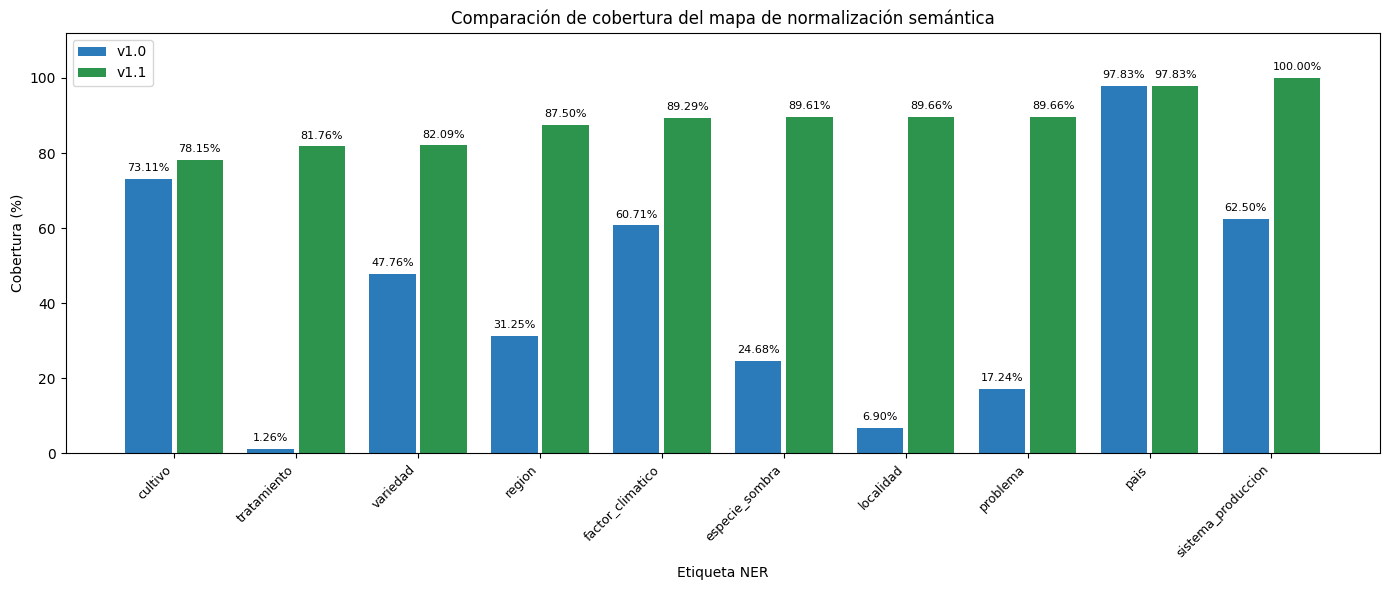

In [276]:
# Colores
color_v1_0 = sns.color_palette("Blues")[4]
color_v1_1 = sns.color_palette("Greens")[4]

df_plot = df_domain_coverage_comparison.sort_values(
    by="porcentaje_cobertura_v1_1",
    ascending=True
)

x = range(len(df_plot))
bar_width = 0.38
gap = 0.04

plt.figure(figsize=(14, 6))

bars_v1_0 = plt.bar(
    [i - bar_width / 2 - gap / 2 for i in x],
    df_plot["porcentaje_cobertura_v1_0"],
    width=bar_width,
    label="v1.0",
    color=color_v1_0
)

bars_v1_1 = plt.bar(
    [i + bar_width / 2 + gap / 2 for i in x],
    df_plot["porcentaje_cobertura_v1_1"],
    width=bar_width,
    label="v1.1",
    color=color_v1_1
)

# Añadir porcentaje encima de cada barra
for bars in [bars_v1_0, bars_v1_1]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1.5,
            f"{height:.2f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.xticks(
    list(x),
    df_plot["entity_label"],
    rotation=45,
    ha="right",
    fontsize=9
)

plt.ylabel("Cobertura (%)")
plt.xlabel("Etiqueta NER")
plt.title("Comparación de cobertura del mapa de normalización semántica")
plt.legend()
plt.ylim(0, 112)
plt.tight_layout()
plt.show()

La visualización confirma de forma clara el impacto de la actualización del mapa de normalización semántica. En prácticamente todas las entidades de dominio se observa un incremento notable de la cobertura al pasar de la versión `v1.0` a la versión `v1.1`, especialmente en aquellas categorías que inicialmente presentaban una cobertura baja.

Las mejoras más visibles se producen en `tratamiento`, `problema`, `localidad` y `especie_sombra`. En estos casos, la versión inicial apenas cubría una parte reducida de las variantes detectadas por el NER, mientras que la versión actualizada alcanza coberturas próximas o superiores al 80%. Esto evidencia que la ampliación manual del catálogo ha permitido incorporar expresiones reales presentes en las transcripciones, reduciendo la dispersión terminológica del dominio.

También se observan mejoras relevantes en `region`, `variedad`, `factor_climatico` y `sistema_produccion`, que alcanzan valores de cobertura elevados tras la actualización. En `cultivo`, la mejora es más moderada, debido a que el sistema se restringe deliberadamente a café y cacao, por lo que no se incorporan otras menciones agrícolas detectadas por el NER. La categoría `pais` permanece sin cambios, ya que presentaba una cobertura prácticamente completa desde la versión inicial.

Los datos mostrados en el gráfico muestran que la versión `v1.1` mejora sustancialmente la capacidad del mapa para normalizar entidades semánticas de dominio, manteniendo al mismo tiempo un criterio conservador para no incorporar ruido, errores de etiquetado o entidades fuera del alcance funcional del sistema.

### 8.2 Definición de entidades de dominio normalizables

Se define la correspondencia entre las etiquetas generadas por el módulo NER y los campos del bloque `evento` donde se almacenarán los valores normalizados. Esta asignación permite construir una salida homogénea independientemente de las variantes lingüísticas detectadas en el texto original.

En esta versión no se incluye la entidad `accion`, ya que todavía no forma parte de las etiquetas implementadas en el modelo NER. Aunque la categoría se mantiene en el mapa de normalización para futuras ampliaciones, no se utiliza en la construcción actual de campos normalizados.

In [279]:
domain_entity_field_map = {
    "cultivo": "cultivo",
    "variedad": "variedad",
    "problema": "problemas",
    "tratamiento": "tratamientos",
    "factor_climatico": "factor_climatico",
    "sistema_produccion": "sistema_produccion",
    "especie_sombra": "especie_sombra",
    "localidad": "localidad",
    "region": "region",
    "pais": "pais"
}

domain_list_fields = {
    "problemas",
    "tratamientos",
    "factor_climatico",
    "especie_sombra"
}

print("=== Entidades de dominio normalizables ===")
print(f"Etiquetas NER consideradas: {list(domain_entity_field_map.keys())}")
print(f"Campos tipo lista: {sorted(domain_list_fields)}")

# Comprobar qué etiquetas del mapa actualizado no se utilizan todavía en esta fase
unused_normalization_categories = sorted(
    set(normalization_map_v1_1.keys()) - set(domain_entity_field_map.keys())
)

print("\n=== Categorías del mapa no utilizadas en esta fase ===")
print(unused_normalization_categories)

=== Entidades de dominio normalizables ===
Etiquetas NER consideradas: ['cultivo', 'variedad', 'problema', 'tratamiento', 'factor_climatico', 'sistema_produccion', 'especie_sombra', 'localidad', 'region', 'pais']
Campos tipo lista: ['especie_sombra', 'factor_climatico', 'problemas', 'tratamientos']

=== Categorías del mapa no utilizadas en esta fase ===
['accion']


### 8.3 Normalización individual de entidades de dominio

Se define una función auxiliar para normalizar una entidad de dominio a partir de su texto y etiqueta NER. La búsqueda se realiza únicamente dentro de la categoría correspondiente a la etiqueta asignada por el modelo NER, evitando colisiones entre variantes iguales pertenecientes a categorías distintas.

Si la entidad aparece en el mapa de normalización, se devuelve su forma canónica. Si no existe coincidencia dentro de su categoría, la entidad se marca como no normalizada. Esta información puede utilizarse para análisis y revisión, pero no se incorpora directamente como valor canónico en el JSON final.

In [280]:
def normalize_domain_entity(entity_text: str, entity_label: str) -> dict:
    """
    Normaliza una entidad de dominio mediante el mapa semántico v1.1.
    La búsqueda se realiza únicamente dentro de la categoría de la entidad.
    """
    
    value_clean = normalize_empty_value(entity_text)
    
    if value_clean is None:
        return {
            "original_value": entity_text,
            "normalized_value": None,
            "entity_label": entity_label,
            "matched": False,
            "match_category": None
        }
    
    value_norm = normalize_text_for_matching(value_clean)
    
    # Buscar solo dentro de la categoría asignada por el NER
    category_index = normalization_index_v1_1.get(entity_label, {})
    match = category_index.get(value_norm)
    
    if match is not None:
        return {
            "original_value": entity_text,
            "normalized_value": match["canonical_value"],
            "entity_label": entity_label,
            "matched": True,
            "match_category": entity_label
        }
    
    return {
        "original_value": entity_text,
        "normalized_value": value_norm,
        "entity_label": entity_label,
        "matched": False,
        "match_category": None
    }

### 8.4 Construcción de entidades de dominio por registro

A partir de las entidades detectadas en cada registro, se construye una estructura parcial del bloque `evento` con los campos semánticos normalizados. Los campos multivalor se almacenan como listas, mientras que los campos escalares conservan un único valor.

En esta fase solo se incorporan al bloque normalizado aquellas entidades que han encontrado correspondencia en el mapa semántico `v1.1`. Las entidades no mapeadas se conservan para revisión en las tablas de análisis, pero no se añaden directamente al JSON final para evitar introducir ruido procedente del ASR o de posibles errores del NER.

#### 8.4.1 Inicialización de campos de dominio

In [281]:
def initialize_domain_fields() -> dict:
    """
    Inicializa los campos de dominio del bloque evento.
    """
    
    return {
        "cultivo": None,
        "variedad": None,
        "problemas": [],
        "tratamientos": [],
        "factor_climatico": [],
        "sistema_produccion": None,
        "especie_sombra": [],
        "localidad": None,
        "region": None,
        "pais": None
    }

#### 8.4.2 Inserción controlada de valores normalizados

In [282]:
def add_domain_value(event_domain_fields: dict, field: str, value):
    """
    Añade un valor normalizado al campo correspondiente.
    Evita duplicados en campos multivalor.
    """
    
    if value is None:
        return
    
    if field in domain_list_fields:
        if value not in event_domain_fields[field]:
            event_domain_fields[field].append(value)
    else:
        if event_domain_fields[field] is None:
            event_domain_fields[field] = value

#### 8.4.3 Construcción de campos de dominio por registro

In [283]:
def build_domain_fields_from_record(record: dict) -> dict:
    """
    Construye los campos de dominio normalizados a partir de un registro NER.
    Solo incorpora entidades que han sido mapeadas correctamente.
    """
    
    event_domain_fields = initialize_domain_fields()
    entities = record.get("entities", [])
    
    if not isinstance(entities, list):
        return event_domain_fields
    
    for entity in entities:
        if not isinstance(entity, dict):
            continue
        
        entity_label = entity.get("label")
        entity_text = entity.get("text")
        
        if entity_label not in domain_entity_field_map:
            continue
        
        field = domain_entity_field_map[entity_label]
        normalized_entity = normalize_domain_entity(entity_text, entity_label)
        
        # Solo se incorporan valores reconocidos por el mapa semántico
        if not normalized_entity["matched"]:
            continue
        
        add_domain_value(
            event_domain_fields,
            field,
            normalized_entity["normalized_value"]
        )
    
    return event_domain_fields

#### 8.4.4 Verificación de la construcción de campos por registro

In [286]:
print("=== Prueba de construcción de campos de dominio ===")

sample_record = nlp_records[1]
sample_domain_fields = build_domain_fields_from_record(sample_record)

print("Audio:", sample_record.get("audio_id"))
print("Texto:", sample_record.get("text"))
print("Campos de dominio normalizados:")
display(pd.DataFrame([sample_domain_fields]))

=== Prueba de construcción de campos de dominio ===
Audio: AUDIO_00002
Texto: Mi nombre es Luis Fernando Taborda, soy productor de café en la vereda El Tambo, municipio de El Tambo, departamento de Cauca, Colombia.  Actualmente manejo aproximadamente 7 hectáreas sembradas con variedad castillo bajo un sistema agroforestal con sombra de guavos y algunos frutales, trabajando con apoyo técnico para mejorar la producción.
Campos de dominio normalizados:


,cultivo,variedad,problemas,tratamientos,factor_climatico,sistema_produccion,especie_sombra,localidad,region,pais
0,cafe,castillo,[],[],[],None,"[guavo, frutales]",el_tambo,cauca,colombia


La prueba muestra que la construcción de campos de dominio funciona correctamente sobre un registro individual. A partir del texto original, el sistema identifica y normaliza entidades relevantes como `café`, `castillo`, `El Tambo`, `Cauca`, `Colombia`, `guavos` y `frutales`, incorporándolas a los campos correspondientes del bloque parcial `evento`.

El resultado es coherente con la estructura esperada: `cultivo`, `variedad`, `localidad`, `region` y `pais` se almacenan como campos escalares, mientras que `especie_sombra` se representa como una lista con varios valores normalizados (`guavo` y `frutales`). Los campos `problemas`, `tratamientos` y `factor_climatico` permanecen vacíos, ya que el mensaje no describe incidencias fitosanitarias, tratamientos aplicados ni condiciones climáticas concretas.

La única observación relevante es que `sistema_produccion` aparece como `None` aunque el texto contiene la expresión `sistema agroforestal`. Dado que esta variante sí está incluida en el mapa de normalización, el caso sugiere que la entidad no fue detectada por el módulo NER con la etiqueta `sistema_produccion`. Este resultado ilustra una limitación importante del pipeline: el módulo de normalización solo puede operar sobre entidades previamente detectadas por el NER.

### 8.5 Revisión de normalización por tipo de entidad

Se genera una tabla de revisión para analizar cómo se han normalizado las entidades de dominio detectadas por el módulo NER. Esta comprobación permite identificar qué entidades han sido resueltas mediante el mapa semántico `v1.1` y cuáles no han encontrado correspondencia dentro de su categoría.

Las entidades no mapeadas se conservan únicamente en esta tabla de revisión para facilitar el análisis de errores y posibles ampliaciones futuras del catálogo, pero no se incorporan directamente al JSON normalizado final.

#### 8.5.1 Construcción de la tabla de revisión

In [287]:
def build_domain_normalization_review(nlp_records: list) -> pd.DataFrame:
    """
    Construye una tabla de revisión de entidades de dominio normalizadas.
    """
    
    review_rows = []
    
    for record in nlp_records:
        audio_id = record.get("audio_id")
        
        for entity in record.get("entities", []):
            if not isinstance(entity, dict):
                continue
            
            entity_label = entity.get("label")
            entity_text = entity.get("text")
            
            if entity_label not in domain_entity_field_map:
                continue
            
            normalized_entity = normalize_domain_entity(entity_text, entity_label)
            
            review_rows.append({
                "audio_id": audio_id,
                "entity_text": entity_text,
                "entity_label": entity_label,
                "normalized_value": normalized_entity["normalized_value"],
                "matched": normalized_entity["matched"],
                "match_category": normalized_entity["match_category"]
            })
    
    return pd.DataFrame(review_rows)

#### 8.5.2 Análisis de cobertura por etiqueta

In [288]:
df_domain_review = build_domain_normalization_review(nlp_records)

print("=== Revisión de normalización semántica de dominio ===")
print(f"Entidades de dominio revisadas: {len(df_domain_review)}")

print("\n--- Distribución por etiqueta NER ---")
display(
    df_domain_review["entity_label"]
    .value_counts()
    .to_frame(name="conteo")
)

print("\n--- Cobertura del mapa de normalización v1.1 ---")
df_domain_review_coverage = (
    df_domain_review
    .groupby("entity_label")["matched"]
    .agg(total="count", normalizadas_por_mapa="sum")
    .assign(
        porcentaje_mapeado=lambda x: (
            x["normalizadas_por_mapa"] / x["total"] * 100
        ).round(2)
    )
    .reset_index()
    .sort_values(by="porcentaje_mapeado", ascending=False)
    .reset_index(drop=True)
)

display(df_domain_review_coverage)

=== Revisión de normalización semántica de dominio ===
Entidades de dominio revisadas: 636

--- Distribución por etiqueta NER ---


,conteo
entity_label,
tratamiento,159
cultivo,119
problema,87
especie_sombra,77
variedad,67
pais,46
localidad,29
factor_climatico,28
region,16



--- Cobertura del mapa de normalización v1.1 ---


,entity_label,total,normalizadas_por_mapa,porcentaje_mapeado
0,sistema_produccion,8,8,100.00
1,pais,46,45,97.83
2,localidad,29,26,89.66
3,problema,87,78,89.66
4,especie_sombra,77,69,89.61
5,factor_climatico,28,25,89.29
6,region,16,14,87.50
7,variedad,67,55,82.09
8,tratamiento,159,130,81.76
9,cultivo,119,93,78.15


La revisión de normalización semántica de dominio muestra que se han evaluado 636 entidades correspondientes a las categorías utilizadas en esta fase del pipeline. La distribución por etiqueta confirma que las entidades más frecuentes son `tratamiento`, `cultivo`, `problema`, `especie_sombra` y `variedad`, lo que resulta coherente con el tipo de información esperada en mensajes agrícolas orientados al registro de prácticas, incidencias y características del cultivo.

La cobertura obtenida con el mapa `v1.1` es elevada en la mayoría de categorías. Destaca `sistema_produccion`, con una cobertura del 100%, seguida de `pais`, `localidad`, `problema`, `especie_sombra`, `factor_climatico` y `region`, todas ellas con valores próximos o superiores al 87%. Esto confirma que la ampliación manual del mapa ha permitido resolver gran parte de la variabilidad lingüística detectada por el NER.

Las categorías con menor cobertura relativa son `tratamiento` y `cultivo`, aunque ambas mantienen valores aceptables. En `tratamiento`, la cobertura alcanza el 81,76%, pero sigue existiendo variabilidad porque muchas expresiones etiquetadas como tratamiento corresponden en realidad a labores, acciones agrícolas o descripciones demasiado amplias. En `cultivo`, la cobertura del 78,15% debe interpretarse con cautela, ya que el sistema se limita deliberadamente a café y cacao; por tanto, otras menciones agrícolas detectadas como cultivo no se incorporan al mapa por quedar fuera del alcance funcional definido.

#### 8.5.3 Revisión de entidades no mapeadas

In [289]:
df_domain_unmatched_review = df_domain_review[
    ~df_domain_review["matched"]
].copy()

df_domain_unmatched_summary = (
    df_domain_unmatched_review
    .groupby(["entity_label", "entity_text", "normalized_value"])
    .size()
    .reset_index(name="frecuencia")
    .sort_values(by=["entity_label", "frecuencia"], ascending=[True, False])
    .reset_index(drop=True)
)

print("=== Entidades de dominio no mapeadas tras v1.1 ===")
print(f"Entidades no mapeadas: {len(df_domain_unmatched_review)}")
print(f"Variantes únicas no mapeadas: {len(df_domain_unmatched_summary)}")

display(df_domain_unmatched_summary)

=== Entidades de dominio no mapeadas tras v1.1 ===
Entidades no mapeadas: 93
Variantes únicas no mapeadas: 54


,entity_label,entity_text,normalized_value,frecuencia
0,cultivo,cultivo,cultivo,23
1,cultivo,café Augusta,cafe augusta,1
2,cultivo,cítrico,citrico,1
3,cultivo,yuca,yuca,1
4,especie_sombra,Moyo Bamba,moyo bamba,2
5,especie_sombra,árboles,arboles,2
6,especie_sombra,cítricos,citricos,1
7,especie_sombra,jornaleros,jornaleros,1
8,especie_sombra,monidiasis,monidiasis,1
9,especie_sombra,yelletarias,yelletarias,1


Tras aplicar el mapa de normalización `v1.1`, permanecen 93 entidades de dominio no mapeadas, agrupadas en 54 variantes únicas. Estos casos representan las entidades que no han encontrado correspondencia dentro de su categoría semántica y, por tanto, no se incorporan directamente al JSON normalizado final.

El listado muestra que una parte importante de las entidades no mapeadas corresponde a ruido o errores de etiquetado. Por ejemplo, en `cultivo` aparecen términos como `yuca`, `cítrico` o `café Augusta`, que no se incorporan porque el sistema está restringido a café y cacao. En `pais`, la variante `agroforestal` evidencia un error de etiquetado NER, ya que semánticamente corresponde a un sistema de producción y no a un país. De forma similar, `hectárea` aparece como `variedad`, aunque pertenece al ámbito de magnitudes, y `monilias` aparece como variedad cuando debería relacionarse con problemas fitosanitarios.

También se observan expresiones demasiado generales o ambiguas, como `control`, `actividades`, `mantenimiento general`, `planificación`, `rápido`, `verde` o `nutrientes`. Estos términos no se añaden al mapa porque no permiten una normalización canónica suficientemente precisa. Otros casos, como `Cixemamisto`, `Uleá`, `Moyo Bamba` o `yelletarias`, requieren revisión manual adicional antes de decidir si corresponden a errores del ASR, topónimos reales o variantes relevantes del dominio.

Esta revisión confirma que las entidades no mapeadas restantes no deben añadirse automáticamente al catálogo. La mayoría de los casos pendientes corresponden a errores del ASR, errores de etiquetado NER, expresiones ambiguas o entidades fuera del alcance de la versión actual del sistema. Por tanto, mantenerlas fuera del JSON final es una decisión conservadora que evita convertir ruido en información estructurada.

### 8.6 Comprobación de campos de dominio normalizados

Finalmente, se aplica la normalización semántica sobre todos los registros cargados para construir los campos de dominio normalizados por audio. Esta comprobación permite verificar que las entidades detectadas por el NER se transforman en una estructura parcial compatible con el bloque `evento` del JSON final.

En esta fase solo se incorporan valores que han sido reconocidos por el mapa semántico `v1.1`, por lo que las entidades no mapeadas quedan excluidas de la salida estructurada.

#### 8.6.1 Construcción del diccionario de campos por audio

Se aplica la normalización semántica sobre los 200 registros cargados, generando un diccionario indexado por `audio_id`. Cada entrada contiene los campos de dominio que posteriormente se integrarán en el bloque `evento` del JSON final.

Además de comprobar el número de registros procesados, se calcula cuántos registros contienen información de dominio normalizada, cuántos quedan sin valores normalizados y cuántos valores se han incorporado en total por campo. Esta revisión permite verificar no solo que el proceso se ha ejecutado, sino también el grado real de aprovechamiento de las entidades detectadas por el NER.

In [298]:
domain_fields_by_audio = {}

for record in nlp_records:
    audio_id = record.get("audio_id")
    domain_fields_by_audio[audio_id] = build_domain_fields_from_record(record)


# Resumen de campos normalizados por audio
total_records = len(domain_fields_by_audio)
records_with_domain_info = 0
records_without_domain_info = 0
total_normalized_values = 0

field_value_counts = {
    field: 0
    for field in initialize_domain_fields().keys()
}

for audio_id, domain_fields in domain_fields_by_audio.items():
    record_has_value = False
    
    for field, value in domain_fields.items():
        if field in domain_list_fields:
            value_count = len(value) if isinstance(value, list) else 0
        else:
            value_count = 1 if value is not None else 0
        
        field_value_counts[field] += value_count
        total_normalized_values += value_count
        
        if value_count > 0:
            record_has_value = True
    
    if record_has_value:
        records_with_domain_info += 1
    else:
        records_without_domain_info += 1


print("=== Construcción de campos de dominio normalizados por audio ===")
print(f"Registros procesados: {total_records}")
print(f"Registros con información de dominio normalizada: {records_with_domain_info}")
print(f"Registros sin información de dominio normalizada: {records_without_domain_info}")
print(f"Valores normalizados incorporados: {total_normalized_values}")

=== Construcción de campos de dominio normalizados por audio ===
Registros procesados: 200
Registros con información de dominio normalizada: 193
Registros sin información de dominio normalizada: 7
Valores normalizados incorporados: 499


La construcción de campos de dominio normalizados se ha aplicado sobre los 200 registros cargados. De ellos, 193 registros presentan al menos un campo de dominio normalizado, mientras que solo 7 registros quedan sin información semántica incorporada. Esto indica que el módulo de normalización aprovecha la mayor parte de las salidas generadas por el NER.

En total se incorporan 499 valores normalizados a los campos de dominio, lo que confirma que la normalización semántica no se limita a mejorar la cobertura del mapa, sino que genera una estructura parcial aprovechable para la construcción posterior del bloque `evento`.

Los registros sin información de dominio normalizada pueden corresponder a mensajes con entidades no detectadas, entidades no mapeadas o contenido que no contiene información semántica relevante para los campos definidos en esta fase. Estos casos no invalidan el proceso, pero permiten identificar situaciones en las que la calidad de la salida depende de la detección previa realizada por el módulo NER.

#### 8.6.2 Conversión a tabla de revisión

In [295]:
domain_fields_review_rows = []

for audio_id, domain_fields in domain_fields_by_audio.items():
    row = {"audio_id": audio_id}
    row.update(domain_fields)
    domain_fields_review_rows.append(row)

df_domain_fields_by_audio = pd.DataFrame(domain_fields_review_rows)

print("=== Vista de campos de dominio normalizados ===")
display(df_domain_fields_by_audio.head(10))

=== Vista de campos de dominio normalizados ===


,audio_id,cultivo,variedad,problemas,tratamientos,factor_climatico,sistema_produccion,especie_sombra,localidad,region,pais
0,AUDIO_00001,cafe,NaN,[maleza],[deshierbe],[],NaN,[],NaN,NaN,NaN
1,AUDIO_00002,cafe,castillo,[],[],[],NaN,"[guavo, frutales]",el_tambo,cauca,colombia
2,AUDIO_00003,NaN,NaN,[],[fertilizante],[],NaN,[],NaN,NaN,NaN
3,AUDIO_00004,cacao,NaN,[daño],[cosecha],[],NaN,[],NaN,NaN,NaN
4,AUDIO_00005,cacao,trinitario,[],[],[],NaN,"[arboles_forestales, platano]",pitalito,NaN,NaN
5,AUDIO_00006,NaN,NaN,"[broca, granos_perforados]",[],[],NaN,[],NaN,NaN,NaN
6,AUDIO_00007,NaN,NaN,[],"[deshierbe, herbicida]",[],NaN,[],NaN,NaN,NaN
7,AUDIO_00008,cafe,caturra,[],[],[],NaN,"[inga, frutales]",marcala,NaN,honduras
8,AUDIO_00009,cafe,NaN,[baja_produccion],[poda],[],NaN,[],NaN,NaN,NaN
9,AUDIO_00010,NaN,NaN,[],[],"[lluvia, sequia]",NaN,[],NaN,NaN,NaN


La vista de campos normalizados por audio permite comprobar la forma que adopta la salida parcial antes de integrarse en el JSON final. Cada fila representa un audio y muestra los valores semánticos que han sido normalizados a partir de las entidades detectadas por el NER.

Los ejemplos muestran que los campos escalares, como `cultivo`, `variedad`, `localidad`, `region` y `pais`, almacenan un único valor normalizado cuando existe información disponible. En cambio, los campos multivalor, como `problemas`, `tratamientos`, `factor_climatico` y `especie_sombra`, se representan como listas, permitiendo conservar varias entidades dentro de un mismo registro.

También se observa que algunos campos quedan vacíos en determinados registros. Esto no representa necesariamente un error, sino que refleja que el mensaje original no contenía esa información o que la entidad correspondiente no fue detectada y normalizada. Por ejemplo, algunos audios contienen únicamente información sobre tratamientos, problemas o condiciones climáticas, mientras que otros incluyen información más completa sobre cultivo, variedad, localización y sistema de sombra.

#### 8.6.3 Cobertura de campos normalizados por audio

Se calcula la cobertura de normalización por campo de dominio utilizando como denominador el número real de entidades detectadas por el NER para cada etiqueta. Esta revisión permite comprobar qué proporción de entidades detectadas ha sido finalmente normalizada e incorporada a los campos del bloque `evento`.

In [297]:
print("=== Cobertura de normalización por campo de dominio ===")

field_coverage_rows = []

for entity_label, field in domain_entity_field_map.items():
    df_label = df_domain_review[
        df_domain_review["entity_label"] == entity_label
    ]
    
    total_entities = len(df_label)
    normalized_entities = df_label["matched"].sum()
    
    field_coverage_rows.append({
        "entity_label": entity_label,
        "campo_evento": field,
        "entidades_detectadas": total_entities,
        "entidades_normalizadas": normalized_entities,
        "porcentaje_normalizacion": round(
            normalized_entities / total_entities * 100, 2
        ) if total_entities > 0 else 0
    })

df_domain_field_coverage = pd.DataFrame(field_coverage_rows)

df_domain_field_coverage = df_domain_field_coverage.sort_values(
    by="porcentaje_normalizacion",
    ascending=False
).reset_index(drop=True)

display(df_domain_field_coverage)

=== Cobertura de normalización por campo de dominio ===


,entity_label,campo_evento,entidades_detectadas,entidades_normalizadas,porcentaje_normalizacion
0,sistema_produccion,sistema_produccion,8,8,100.00
1,pais,pais,46,45,97.83
2,problema,problemas,87,78,89.66
3,localidad,localidad,29,26,89.66
4,especie_sombra,especie_sombra,77,69,89.61
5,factor_climatico,factor_climatico,28,25,89.29
6,region,region,16,14,87.50
7,variedad,variedad,67,55,82.09
8,tratamiento,tratamientos,159,130,81.76
9,cultivo,cultivo,119,93,78.15


La cobertura de normalización por campo de dominio muestra qué proporción de entidades detectadas por el NER ha sido finalmente normalizada e incorporada a los campos correspondientes del bloque `evento`. A diferencia de una cobertura calculada sobre el número total de audios, esta tabla utiliza como denominador el número real de entidades detectadas para cada etiqueta, por lo que refleja de forma más precisa el rendimiento del proceso de normalización semántica.

Los resultados muestran una cobertura elevada en la mayoría de campos. `sistema_produccion` alcanza el 100%, seguido de `pais` con un 97,83%. También presentan coberturas cercanas al 90% los campos `problemas`, `localidad`, `especie_sombra`, `factor_climatico` y `region`. Estos valores indican que el mapa `v1.1` permite resolver de forma eficaz la mayoría de variantes detectadas por el NER en estas categorías.

Las coberturas más bajas aparecen en `tratamientos` y `cultivo`. En el caso de `tratamientos`, la cobertura del 81,76% sigue siendo alta, aunque refleja la presencia de expresiones ambiguas, acciones agrícolas generales o entidades mal etiquetadas. En `cultivo`, la cobertura del 78,15% se explica en parte por una decisión de diseño: el sistema solo normaliza café y cacao, por lo que otras menciones agrícolas detectadas como cultivo quedan excluidas deliberadamente.

La tabla confirma que la versión actualizada del mapa semántico proporciona una base sólida para la estructuración final de entidades de dominio, manteniendo un criterio conservador para no incorporar valores no validados al JSON normalizado.

## 9. Normalización de acciones y eventos agrícolas

La normalización de acciones agrícolas se identifica como una funcionalidad relevante para futuras versiones del sistema, ya que permitiría representar de forma explícita la operación principal descrita en cada mensaje, como siembra, cosecha, poda, deshierbe, fumigación o fertilización.

No obstante, en la versión actual del *pipeline* no se implementa esta normalización, ya que la entidad `accion` no forma parte del esquema de etiquetas utilizado por el modelo NER. Mantener la detección de acciones fuera del NER y resolverla mediante reglas léxicas sobre la transcripción completa podría introducir ambigüedad y errores adicionales, al detectar acciones no necesariamente vinculadas al evento principal del mensaje.

Por este motivo, se decide no incorporar acciones al JSON normalizado en esta versión. La categoría `accion` se mantiene únicamente en el mapa de normalización como preparación para una futura ampliación del esquema NER. En dicha versión, las acciones deberán ser anotadas, entrenadas y evaluadas explícitamente antes de integrarse en el flujo de normalización y estructuración final.

## 10. Implementación y ejecución del *pipeline* final de normalización y estructuración

Una vez evaluadas las reglas de normalización y seleccionadas las configuraciones finales para fechas, magnitudes y entidades de dominio, se procede a la implementación del *pipeline* final de normalización y estructuración.

En esta fase se integran los componentes validados en un flujo único, utilizando como entrada los JSON generados por el módulo de clasificación y NER, junto con los metadatos asociados a cada audio. El resultado esperado es un conjunto de archivos JSON normalizados, uno por audio, con una estructura homogénea y preparada para su almacenamiento posterior.

El diseño del *pipeline* mantiene un enfoque modular, separando la carga de recursos, la normalización de cada tipo de información, la construcción del evento estructurado, la exportación de resultados y la validación final del proceso.

### 10.1 Inicialización del entorno y gestión de rutas

En primer lugar, se define una función de configuración de rutas para localizar de forma automática la raíz del proyecto y establecer los directorios de entrada, configuración, metadatos y salida del *pipeline* final. Este enfoque evita depender de rutas absolutas y facilita la ejecución del *notebook* desde distintos entornos.

In [364]:
# Define las rutas del proyecto para el pipeline final de normalización
# Localiza la entrada NLP, los metadatos, la configuración y la salida final

def configure_paths(
    base_data_dir: str = "data"
) -> dict:

    project_root = Path.cwd()

    # Detectar raíz del proyecto
    while not (project_root / base_data_dir).exists():
        if project_root.parent == project_root:
            raise FileNotFoundError(f"No se encontró la carpeta '{base_data_dir}'")
        project_root = project_root.parent

    data_dir = project_root / base_data_dir

    # Input
    nlp_output_dir = data_dir / "structured_data" / "nlp_output"
    metadata_dir = data_dir / "metadata" / "audio_metadata"

    # Output
    normalized_output_dir = data_dir / "structured_data" / "normalized_output"

    # Configuración
    normalization_map_path = data_dir / "config" / "normalization" / "normalization_map_v1.1.json"
    unit_normalization_map_path = data_dir / "config" / "normalization" / "unit_normalization_map.json"
    normalization_rules_path = data_dir / "config" / "normalization" / "normalization_rules.json"
    ner_entities_path = data_dir / "config" / "ner" / "ner_entities.json"

    # Crear carpeta de salida
    normalized_output_dir.mkdir(parents=True, exist_ok=True)

    return {
        "project_root": project_root,
        "nlp_output_dir": nlp_output_dir,
        "metadata_dir": metadata_dir,
        "normalized_output_dir": normalized_output_dir,
        "normalization_map_path": normalization_map_path,
        "unit_normalization_map_path": unit_normalization_map_path,
        "normalization_rules_path": normalization_rules_path,
        "ner_entities_path": ner_entities_path
    }

### 10.2 Carga de recursos del *pipeline*

A continuación, se definen las funciones encargadas de cargar los recursos necesarios para la ejecución del *pipeline* final de normalización. Estos recursos incluyen los registros generados por el módulo de clasificación y NER, los metadatos asociados a cada audio y los archivos de configuración utilizados para normalizar entidades, magnitudes y etiquetas válidas.

Separar esta lógica en funciones específicas permite mantener el *pipeline* modular y facilita la validación independiente de cada entrada antes de construir los eventos normalizados.

#### 10.2.1 Carga de archivos JSON

In [365]:
# Carga un archivo JSON desde disco
def load_json_file(path: Path):

    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    return data

#### 10.2.2 Carga de registros de clasificación y NER

In [366]:
# Carga los registros generados por el módulo de clasificación y NER
# Devuelve una lista de diccionarios, uno por audio
def load_nlp_records(
    nlp_output_dir: Path
) -> list[dict]:

    json_files = sorted(nlp_output_dir.glob("*.json"))

    if len(json_files) == 0:
        raise FileNotFoundError(
            f"No se han encontrado archivos JSON en: {nlp_output_dir}"
        )

    records = []

    for json_file in json_files:
        record = load_json_file(json_file)
        records.append(record)

    return records

#### 10.2.3 Carga de metadatos de audio

In [367]:
# Carga los metadatos de audio y los indexa por audio_id
def load_audio_metadata(
    metadata_dir: Path
) -> dict:

    metadata_files = sorted(metadata_dir.glob("*.json"))

    if len(metadata_files) == 0:
        raise FileNotFoundError(
            f"No se han encontrado archivos de metadatos en: {metadata_dir}"
        )

    metadata_by_audio = {}

    for metadata_file in metadata_files:
        metadata = load_json_file(metadata_file)

        audio_id = metadata.get("id")

        if audio_id is None:
            raise ValueError(
                f"El archivo de metadatos no contiene el campo 'id': {metadata_file}"
            )

        metadata_by_audio[audio_id] = metadata

    return metadata_by_audio

#### 10.2.4 Carga de archivos de configuración

In [368]:
# Carga los archivos de configuración necesarios para la normalización
def load_normalization_resources(
    paths: dict
) -> dict:

    normalization_map = load_json_file(paths["normalization_map_path"])
    unit_normalization_map = load_json_file(paths["unit_normalization_map_path"])
    normalization_rules = load_json_file(paths["normalization_rules_path"])
    ner_entities = load_json_file(paths["ner_entities_path"])

    return {
        "normalization_map": normalization_map,
        "unit_normalization_map": unit_normalization_map,
        "normalization_rules": normalization_rules,
        "ner_entities": ner_entities
    }

### 10.3 Implementación de funciones finales de normalización

Una vez definidas las funciones de carga de recursos, se implementan las funciones finales utilizadas por el *pipeline* de normalización. Estas funciones recogen las decisiones adoptadas en las fases exploratorias anteriores y se integran posteriormente en la normalización de cada registro individual.

El objetivo en esta fase no es volver a evaluar alternativas, sino consolidar las reglas seleccionadas para texto, fechas, magnitudes, entidades de dominio y construcción del evento estructurado.

#### 10.3.1 Recursos auxiliares comunes

In [369]:
# Numerales básicos compartidos por los módulos temporal y de magnitudes
number_words = {
    "un": 1,
    "una": 1,
    "uno": 1,
    "dos": 2,
    "tres": 3,
    "cuatro": 4,
    "cinco": 5,
    "seis": 6,
    "siete": 7,
    "ocho": 8,
    "nueve": 9,
    "diez": 10,
    "once": 11,
    "doce": 12,
    "trece": 13,
    "catorce": 14,
    "quince": 15,
    "dieciseis": 16,
    "dieciséis": 16,
    "diecisiete": 17,
    "dieciocho": 18,
    "diecinueve": 19,
    "veinte": 20,
    "treinta": 30,
    "cuarenta": 40,
    "cincuenta": 50,
    "sesenta": 60,
    "setenta": 70,
    "ochenta": 80,
    "noventa": 90,
    "cien": 100
}

#### 10.3.2 Módulo de normalización textual

Este bloque agrupa las funciones auxiliares de normalización textual utilizadas por el resto del *pipeline*. Estas funciones permiten limpiar valores, preparar textos para comparación con mapas de normalización y detectar valores vacíos o no informativos.

In [370]:
# Normaliza texto conservando tildes y puntuación básica
def normalize_text_basic(text: str) -> str:

    if text is None:
        return ""

    text = str(text)
    text = unicodedata.normalize("NFKC", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text)

    return text.strip()


# Normaliza texto para comparación con mapas y reglas
def normalize_text_for_matching(text: str) -> str:

    if text is None:
        return ""

    text = str(text)
    text = unicodedata.normalize("NFKC", text)
    text = text.lower()
    text = unidecode(text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()


# Normaliza valores vacíos o no informativos
def normalize_empty_value(value):

    if value is None:
        return None

    if isinstance(value, str):
        value_clean = normalize_text_basic(value)

        if value_clean == "":
            return None

        value_for_matching = normalize_text_for_matching(value_clean)

        if value_for_matching in {
            "none",
            "null",
            "nan",
            "no disponible",
            "sin dato",
            "sin datos"
        }:
            return None

        return value_clean

    return value

#### 10.3.3 Módulo de normalización temporal

Este bloque agrupa las funciones encargadas de normalizar las expresiones temporales detectadas como `fecha_evento`. La normalización se realiza mediante reglas propias, tomando como referencia la fecha de recepción del audio obtenida a partir de los metadatos.

El módulo contempla fechas explícitas, expresiones relativas y referencias temporales ambiguas frecuentes en los mensajes analizados.

In [371]:
# Diccionario auxiliar de meses en español
spanish_months = {
    "enero": 1,
    "febrero": 2,
    "marzo": 3,
    "abril": 4,
    "mayo": 5,
    "junio": 6,
    "julio": 7,
    "agosto": 8,
    "septiembre": 9,
    "setiembre": 9,
    "octubre": 10,
    "noviembre": 11,
    "diciembre": 12
}


# Garantiza que la fecha de referencia sea un objeto date
# Evita que las fechas normalizadas se serialicen con hora si llega un datetime
def ensure_date(value) -> date:

    if isinstance(value, datetime):
        return value.date()

    if isinstance(value, date):
        return value

    raise TypeError("reference_date debe ser de tipo date o datetime")


# Extrae expresiones temporales etiquetadas como fecha_evento
def extract_temporal_expressions(record: dict) -> list:

    entities = record.get("entities", [])

    if not isinstance(entities, list):
        return []

    temporal_expressions = []

    for entity in entities:
        if not isinstance(entity, dict):
            continue

        if entity.get("label") == "fecha_evento":
            value = normalize_empty_value(entity.get("text"))

            if value is not None:
                temporal_expressions.append(value)

    return temporal_expressions


# Convierte un token numérico, en cifra o texto, a entero
def parse_integer_token(token: str):

    token_norm = normalize_text_for_matching(token)

    if token_norm.isdigit():
        return int(token_norm)

    return number_words.get(token_norm)


# Normaliza fechas explícitas
def normalize_explicit_date(expression: str, reference_date: date) -> dict:

    reference_date = ensure_date(reference_date)

    if normalize_empty_value(expression) is None:
        return {
            "fecha_evento": None,
            "fecha_evento_fin": None,
            "granularidad_fecha_evento": None,
            "matched": False
        }

    expression_norm = normalize_text_for_matching(expression)

    # Formatos numéricos: dd/mm/yyyy, dd-mm-yyyy, dd.mm.yyyy
    numeric_pattern = r"\b(\d{1,2})\s*[\/\-.]\s*(\d{1,2})(?:\s*[\/\-.]\s*(\d{2,4}))?\b"
    match = re.search(numeric_pattern, expression_norm)

    if match:
        day = int(match.group(1))
        month = int(match.group(2))
        year = match.group(3)

        if year is None:
            year = reference_date.year
        else:
            year = int(year)

            if year < 100:
                year += 2000

        try:
            normalized_date = date(year, month, day)

            return {
                "fecha_evento": normalized_date.isoformat(),
                "fecha_evento_fin": None,
                "granularidad_fecha_evento": "dia",
                "matched": True
            }

        except ValueError:
            return {
                "fecha_evento": None,
                "fecha_evento_fin": None,
                "granularidad_fecha_evento": None,
                "matched": False
            }

    # Formato textual: 15 de marzo, 15 marzo, 15 de marzo de 2026
    textual_pattern = r"\b(\d{1,2})(?:\s+de)?\s+([a-z]+)(?:\s+de\s+(\d{4}))?\b"
    match = re.search(textual_pattern, expression_norm)

    if match:
        day = int(match.group(1))
        month_text = match.group(2)
        year = int(match.group(3)) if match.group(3) else reference_date.year

        month = spanish_months.get(month_text)

        if month is not None:
            try:
                normalized_date = date(year, month, day)

                return {
                    "fecha_evento": normalized_date.isoformat(),
                    "fecha_evento_fin": None,
                    "granularidad_fecha_evento": "dia",
                    "matched": True
                }

            except ValueError:
                pass

    return {
        "fecha_evento": None,
        "fecha_evento_fin": None,
        "granularidad_fecha_evento": None,
        "matched": False
    }


# Normaliza expresiones relativas simples
def normalize_relative_date(expression: str, reference_date: date) -> dict:

    reference_date = ensure_date(reference_date)

    if normalize_empty_value(expression) is None:
        return {
            "fecha_evento": None,
            "fecha_evento_fin": None,
            "granularidad_fecha_evento": None,
            "matched": False
        }

    expression_norm = normalize_text_for_matching(expression)

    if expression_norm == "hoy":
        event_date = reference_date

    elif expression_norm == "ayer":
        event_date = reference_date - timedelta(days=1)

    elif expression_norm == "anteayer":
        event_date = reference_date - timedelta(days=2)

    elif expression_norm in {"mañana", "manana"}:
        event_date = reference_date + timedelta(days=1)

    else:
        event_date = None

    if event_date is not None:
        return {
            "fecha_evento": event_date.isoformat(),
            "fecha_evento_fin": None,
            "granularidad_fecha_evento": "dia",
            "matched": True
        }

    # Expresiones tipo: hace dos dias, hace 3 semanas
    match = re.search(r"hace\s+(\w+)\s+(dia|dias|semana|semanas)", expression_norm)

    if match:
        amount = parse_integer_token(match.group(1))
        unit = match.group(2)

        if amount is not None:
            days = amount if unit in {"dia", "dias"} else amount * 7
            event_date = reference_date - timedelta(days=days)

            return {
                "fecha_evento": event_date.isoformat(),
                "fecha_evento_fin": None,
                "granularidad_fecha_evento": "dia",
                "matched": True
            }

    return {
        "fecha_evento": None,
        "fecha_evento_fin": None,
        "granularidad_fecha_evento": None,
        "matched": False
    }


# Normaliza expresiones temporales ambiguas o de rango
def normalize_ambiguous_date(expression: str, reference_date: date) -> dict:

    reference_date = ensure_date(reference_date)

    if normalize_empty_value(expression) is None:
        return {
            "fecha_evento": None,
            "fecha_evento_fin": None,
            "granularidad_fecha_evento": None,
            "matched": False
        }

    expression_norm = normalize_text_for_matching(expression)

    # Semana pasada: se representa como rango semanal completo
    if "semana pasada" in expression_norm:
        start_current_week = reference_date - timedelta(days=reference_date.weekday())
        start_previous_week = start_current_week - timedelta(days=7)
        end_previous_week = start_previous_week + timedelta(days=6)

        return {
            "fecha_evento": start_previous_week.isoformat(),
            "fecha_evento_fin": end_previous_week.isoformat(),
            "granularidad_fecha_evento": "semana",
            "matched": True
        }

    # Este mes: se representa como rango mensual completo
    if "este mes" in expression_norm:
        start_month = date(reference_date.year, reference_date.month, 1)

        if reference_date.month == 12:
            next_month = date(reference_date.year + 1, 1, 1)
        else:
            next_month = date(reference_date.year, reference_date.month + 1, 1)

        end_month = next_month - timedelta(days=1)

        return {
            "fecha_evento": start_month.isoformat(),
            "fecha_evento_fin": end_month.isoformat(),
            "granularidad_fecha_evento": "mes",
            "matched": True
        }

    # Mes pasado: se representa como rango mensual completo
    if "mes pasado" in expression_norm:
        if reference_date.month == 1:
            year = reference_date.year - 1
            month = 12
        else:
            year = reference_date.year
            month = reference_date.month - 1

        start_month = date(year, month, 1)

        if month == 12:
            next_month = date(year + 1, 1, 1)
        else:
            next_month = date(year, month + 1, 1)

        end_month = next_month - timedelta(days=1)

        return {
            "fecha_evento": start_month.isoformat(),
            "fecha_evento_fin": end_month.isoformat(),
            "granularidad_fecha_evento": "mes",
            "matched": True
        }

    # Este año: se representa como rango anual completo
    if "este ano" in expression_norm:
        start_year = date(reference_date.year, 1, 1)
        end_year = date(reference_date.year, 12, 31)

        return {
            "fecha_evento": start_year.isoformat(),
            "fecha_evento_fin": end_year.isoformat(),
            "granularidad_fecha_evento": "anio",
            "matched": True
        }

    return {
        "fecha_evento": None,
        "fecha_evento_fin": None,
        "granularidad_fecha_evento": None,
        "matched": False
    }


# Normaliza expresiones relativas difusas
def normalize_relative_expressions(expression: str, reference_date: date) -> dict:

    reference_date = ensure_date(reference_date)

    if normalize_empty_value(expression) is None:
        return {
            "fecha_evento": None,
            "fecha_evento_fin": None,
            "granularidad_fecha_evento": None,
            "matched": False
        }

    expression_norm = normalize_text_for_matching(expression)

    # Expresiones aproximadas al momento de recepción del mensaje
    if (
        "estos dias" in expression_norm
        or "estos momentos" in expression_norm
        or "actualmente" in expression_norm
    ):
        return {
            "fecha_evento": reference_date.isoformat(),
            "fecha_evento_fin": None,
            "granularidad_fecha_evento": "aproximada",
            "matched": True
        }

    return {
        "fecha_evento": None,
        "fecha_evento_fin": None,
        "granularidad_fecha_evento": None,
        "matched": False
    }


# Aplica las reglas temporales en orden
def normalize_date_expression(expression: str, reference_date: date) -> dict:

    reference_date = ensure_date(reference_date)

    if normalize_empty_value(expression) is None:
        return {
            "fecha_evento": None,
            "fecha_evento_fin": None,
            "granularidad_fecha_evento": None,
            "matched": False
        }

    # 1. Fechas explícitas
    result = normalize_explicit_date(expression, reference_date)
    if result["matched"]:
        return result

    # 2. Fechas relativas simples
    result = normalize_relative_date(expression, reference_date)
    if result["matched"]:
        return result

    # 3. Fechas ambiguas o de rango
    result = normalize_ambiguous_date(expression, reference_date)
    if result["matched"]:
        return result

    # 4. Expresiones relativas difusas
    result = normalize_relative_expressions(expression, reference_date)
    if result["matched"]:
        return result

    return {
        "fecha_evento": None,
        "fecha_evento_fin": None,
        "granularidad_fecha_evento": None,
        "matched": False
    }


# Normaliza la fecha principal de un registro
def normalize_record_date(record: dict, reference_date: date) -> dict:

    reference_date = ensure_date(reference_date)

    temporal_expressions = extract_temporal_expressions(record)

    for expression in temporal_expressions:
        result = normalize_date_expression(
            expression=expression,
            reference_date=reference_date
        )

        if result["matched"]:
            return {
                "fecha_evento": result["fecha_evento"],
                "fecha_evento_fin": result["fecha_evento_fin"],
                "granularidad_fecha_evento": result["granularidad_fecha_evento"]
            }

    return {
        "fecha_evento": None,
        "fecha_evento_fin": None,
        "granularidad_fecha_evento": None
    }

#### 10.3.4 Módulo de normalización de magnitudes y unidades

Este bloque agrupa las funciones encargadas de identificar, validar y normalizar entidades numéricas detectadas por el módulo de clasificación y NER. El objetivo es transformar entidades etiquetadas como `cantidad`, `superficie` o `distancia` en una representación homogénea basada en tres campos: tipo de magnitud, valor numérico y unidad normalizada.

In [372]:
# Construye un índice de unidades normalizadas separado por tipo de magnitud
def build_unit_normalization_index(unit_normalization_map: dict) -> dict:

    unit_index = {}

    for magnitude_type, canonical_units in unit_normalization_map.items():
        unit_index[magnitude_type] = {}

        for canonical_unit, variants in canonical_units.items():
            for variant in [canonical_unit] + variants:
                variant_norm = normalize_text_for_matching(variant)

                unit_index[magnitude_type][variant_norm] = {
                    "magnitude_type": magnitude_type,
                    "canonical_unit": canonical_unit
                }

    return unit_index


# Convierte números escritos o expresados en cifras a valor numérico
def parse_numeric_value(text: str):

    if normalize_empty_value(text) is None:
        return None

    # Se busca primero sobre el texto original para no perder decimales
    text_raw = unidecode(str(text).lower())

    # Número en dígitos, incluyendo decimales con punto o coma
    digit_match = re.search(r"\b\d+(?:[.,]\d+)?\b", text_raw)

    if digit_match:
        value = digit_match.group(0).replace(",", ".")
        return float(value)

    text_norm = normalize_text_for_matching(text)

    # Expresiones compuestas: treinta y cinco
    compound_match = re.search(r"\b(\w+)\s+y\s+(\w+)\b", text_norm)

    if compound_match:
        tens = number_words.get(compound_match.group(1))
        units = number_words.get(compound_match.group(2))

        if tens is not None and units is not None:
            return float(tens + units)

    # Numeral simple
    for token in text_norm.split():
        if token in number_words:
            return float(number_words[token])

    return None


# Extrae la unidad textual de una entidad numérica
def extract_unit_text(text: str):

    if normalize_empty_value(text) is None:
        return None

    # Se eliminan primero los números sobre el texto original
    text_without_digits = re.sub(
        r"\b\d+(?:[.,]\d+)?\b",
        " ",
        unidecode(str(text).lower())
    )

    text_norm = normalize_text_for_matching(text_without_digits)

    # Se eliminan numerales escritos y conectores usados en cantidades
    tokens = [
        token for token in text_norm.split()
        if token not in number_words and token != "y"
    ]

    unit_text = " ".join(tokens).strip()

    if unit_text == "":
        return None

    return unit_text


# Normaliza una unidad textual según el tipo de entidad detectado
def normalize_unit(
    unit_text: str,
    entity_label: str,
    unit_index: dict
) -> dict:

    unit_clean = normalize_empty_value(unit_text)

    if unit_clean is None:
        return {
            "unidad_limpia": None,
            "unidad_normalizada": None,
            "unidad_mapeada": False
        }

    unit_norm = normalize_text_for_matching(unit_clean)

    # Se busca únicamente dentro del tipo de magnitud detectado por NER
    category_unit_index = unit_index.get(entity_label, {})
    match = category_unit_index.get(unit_norm)

    # Si la unidad no está en el mapa, no se incorpora al JSON final
    if match is None:
        return {
            "unidad_limpia": unit_norm,
            "unidad_normalizada": None,
            "unidad_mapeada": False
        }

    return {
        "unidad_limpia": unit_norm,
        "unidad_normalizada": match["canonical_unit"],
        "unidad_mapeada": True
    }


# Normaliza el tipo de magnitud para el JSON final
def normalize_magnitude_type(entity_label: str) -> str:

    if entity_label == "cantidad":
        return "conteo"

    return entity_label


# Normaliza una entidad numérica individual
def normalize_magnitude_entity(
    entity: dict,
    unit_index: dict
):

    entity_text = entity.get("text")
    entity_label = entity.get("label")

    # Solo se procesan las etiquetas numéricas existentes en el esquema NER actual
    if entity_label not in {"cantidad", "superficie", "distancia"}:
        return None

    value = parse_numeric_value(entity_text)
    unit_text = extract_unit_text(entity_text)

    unit_info = normalize_unit(
        unit_text=unit_text,
        entity_label=entity_label,
        unit_index=unit_index
    )

    # Si no hay valor numérico, la magnitud no es utilizable
    if value is None:
        return None

    # Si hay valor pero la unidad no está mapeada, se conserva como magnitud incompleta
    if unit_info["unidad_normalizada"] is None:
        return {
            "tipo": normalize_magnitude_type(entity_label),
            "valor": value,
            "unidad": None,
            "unidad_original": unit_info["unidad_limpia"],
            "estado": "unidad_no_mapeada"
        }

    # Magnitud completamente normalizada
    return {
        "tipo": normalize_magnitude_type(entity_label),
        "valor": value,
        "unidad": unit_info["unidad_normalizada"],
        "unidad_original": unit_info["unidad_limpia"],
        "estado": "ok"
    }


# Construye la lista de magnitudes normalizadas de un registro
def normalize_record_magnitudes(
    record: dict,
    unit_index: dict
) -> list[dict]:

    magnitudes = []

    entities = record.get("entities", [])

    if not isinstance(entities, list):
        return magnitudes

    for entity in entities:
        if not isinstance(entity, dict):
            continue

        magnitude = normalize_magnitude_entity(
            entity=entity,
            unit_index=unit_index
        )

        if magnitude is not None:
            magnitudes.append(magnitude)

    return magnitudes

#### 10.3.5 Módulo de normalización semántica de entidades de dominio

Este bloque agrupa las funciones encargadas de normalizar las entidades de dominio detectadas por el módulo de clasificación y extracción de entidades NER. A partir del mapa semántico `normalization_map_v1.1.json`, cada entidad se compara únicamente dentro de su propia categoría, evitando cruces incorrectos entre etiquetas distintas.

In [373]:
# Relación entre etiquetas NER y campos del bloque evento
domain_entity_field_map = {
    "cultivo": "cultivo",
    "variedad": "variedad",
    "problema": "problemas",
    "tratamiento": "tratamientos",
    "factor_climatico": "factor_climatico",
    "sistema_produccion": "sistema_produccion",
    "especie_sombra": "especie_sombra",
    "localidad": "localidad",
    "region": "region",
    "pais": "pais"
}


# Campos del evento que pueden contener varios valores
domain_list_fields = {
    "problemas",
    "tratamientos",
    "factor_climatico",
    "especie_sombra"
}


# Construye un índice de normalización separado por categoría semántica
def build_normalization_index_by_category(normalization_map: dict) -> dict:

    normalization_index = {}

    for category, canonical_values in normalization_map.items():
        normalization_index[category] = {}

        for canonical_value, variants in canonical_values.items():
            for variant in [canonical_value] + variants:
                variant_norm = normalize_text_for_matching(variant)

                normalization_index[category][variant_norm] = {
                    "category": category,
                    "canonical_value": canonical_value
                }

    return normalization_index


# Inicializa los campos de dominio del evento
def initialize_domain_fields() -> dict:

    return {
        "cultivo": None,
        "variedad": None,
        "problemas": [],
        "tratamientos": [],
        "factor_climatico": [],
        "sistema_produccion": None,
        "especie_sombra": [],
        "localidad": None,
        "region": None,
        "pais": None
    }


# Normaliza una entidad de dominio individual
def normalize_domain_entity(
    entity_text: str,
    entity_label: str,
    normalization_index: dict
) -> dict:

    value_clean = normalize_empty_value(entity_text)

    if value_clean is None:
        return {
            "original_value": entity_text,
            "normalized_value": None,
            "entity_label": entity_label,
            "matched": False,
            "match_category": None
        }

    value_norm = normalize_text_for_matching(value_clean)

    # Se busca únicamente dentro de la categoría asignada por el NER
    category_index = normalization_index.get(entity_label, {})
    match = category_index.get(value_norm)

    if match is not None:
        return {
            "original_value": entity_text,
            "normalized_value": match["canonical_value"],
            "entity_label": entity_label,
            "matched": True,
            "match_category": entity_label
        }

    return {
        "original_value": entity_text,
        "normalized_value": value_norm,
        "entity_label": entity_label,
        "matched": False,
        "match_category": None
    }


# Añade un valor normalizado al campo correspondiente del evento
def add_domain_value(
    event_domain_fields: dict,
    field: str,
    value
) -> None:

    if value is None:
        return

    if field in domain_list_fields:
        if value not in event_domain_fields[field]:
            event_domain_fields[field].append(value)

    else:
        if event_domain_fields[field] is None:
            event_domain_fields[field] = value


# Construye los campos de dominio normalizados de un registro
def normalize_record_domain_fields(
    record: dict,
    normalization_index: dict
) -> dict:

    event_domain_fields = initialize_domain_fields()

    entities = record.get("entities", [])

    if not isinstance(entities, list):
        return event_domain_fields

    for entity in entities:
        if not isinstance(entity, dict):
            continue

        entity_label = entity.get("label")
        entity_text = entity.get("text")

        # Solo se procesan las etiquetas de dominio utilizadas en esta versión
        if entity_label not in domain_entity_field_map:
            continue

        field = domain_entity_field_map[entity_label]

        normalized_entity = normalize_domain_entity(
            entity_text=entity_text,
            entity_label=entity_label,
            normalization_index=normalization_index
        )

        # Las entidades no mapeadas no se incorporan al JSON final
        if not normalized_entity["matched"]:
            continue

        add_domain_value(
            event_domain_fields=event_domain_fields,
            field=field,
            value=normalized_entity["normalized_value"]
        )

    return event_domain_fields

#### 10.3.6 Módulo de construcción del evento estructurado

Este bloque agrupa las funciones encargadas de construir la estructura final del bloque `evento`. Para ello, se inicializa una plantilla común y se integran los resultados procedentes de los módulos de normalización temporal, magnitudes y entidades de dominio.

En esta versión, los campos `accion` y `categoria_accion` se mantienen con valor nulo, ya que la entidad `accion` no forma parte del esquema NER actual y no se incorpora mediante reglas externas para evitar introducir ruido en la salida final.

In [374]:
# Inicializa la estructura base del evento normalizado
def initialize_event_structure() -> dict:

    return {
        "fecha_evento": None,
        "fecha_evento_fin": None,
        "granularidad_fecha_evento": None,
        "cultivo": None,
        "variedad": None,
        "accion": None,
        "categoria_accion": None,
        "magnitudes": [],
        "problemas": [],
        "tratamientos": [],
        "partes_planta": [],
        "estado_cultivo": None,
        "espacio_agricola": None,
        "localidad": None,
        "region": None,
        "pais": None,
        "factor_climatico": [],
        "sistema_produccion": None,
        "especie_sombra": []
    }


# Integra los campos temporales normalizados en el evento
def add_date_fields_to_event(
    event: dict,
    date_fields: dict
) -> dict:

    event["fecha_evento"] = date_fields.get("fecha_evento")
    event["fecha_evento_fin"] = date_fields.get("fecha_evento_fin")
    event["granularidad_fecha_evento"] = date_fields.get("granularidad_fecha_evento")

    return event


# Integra las magnitudes normalizadas en el evento
def add_magnitudes_to_event(
    event: dict,
    magnitudes: list[dict]
) -> dict:

    if isinstance(magnitudes, list):
        event["magnitudes"] = magnitudes

    return event


# Integra los campos de dominio normalizados en el evento
def add_domain_fields_to_event(
    event: dict,
    domain_fields: dict
) -> dict:

    for field, value in domain_fields.items():
        if field in event:
            event[field] = value

    return event


# Construye el evento estructurado de un registro
def build_structured_event(
    record: dict,
    reference_date: date,
    unit_index: dict,
    normalization_index: dict
) -> dict:

    event = initialize_event_structure()

    # Normalización temporal
    date_fields = normalize_record_date(
        record=record,
        reference_date=reference_date
    )

    event = add_date_fields_to_event(
        event=event,
        date_fields=date_fields
    )

    # Normalización de magnitudes
    magnitudes = normalize_record_magnitudes(
        record=record,
        unit_index=unit_index
    )

    event = add_magnitudes_to_event(
        event=event,
        magnitudes=magnitudes
    )

    # Normalización de entidades de dominio
    domain_fields = normalize_record_domain_fields(
        record=record,
        normalization_index=normalization_index
    )

    event = add_domain_fields_to_event(
        event=event,
        domain_fields=domain_fields
    )

    return event

#### 10.3.7 Módulo de metadatos y construcción del registro normalizado

Este bloque agrupa las funciones encargadas de recuperar los metadatos asociados a cada audio y construir el registro normalizado final. A partir del identificador del audio, se obtiene la fecha de recepción del mensaje y se utiliza como referencia para la normalización temporal.

El resultado de este módulo es un diccionario con la estructura final del JSON normalizado, incluyendo la transcripción, el tipo de mensaje, los metadatos temporales y el bloque `evento` construido a partir de las entidades normalizadas.

In [375]:
# Obtiene el identificador anonimizado del usuario desde los metadatos
def get_user_id(
    audio_id: str,
    metadata_by_audio: dict
):

    metadata = metadata_by_audio.get(audio_id)

    if metadata is None:
        return None

    return metadata.get("user_id")


# Extrae el timestamp de recepción desde los metadatos del audio
def get_timestamp_recepcion(
    audio_id: str,
    metadata_by_audio: dict
):

    metadata = metadata_by_audio.get(audio_id)

    if metadata is None:
        return None

    return metadata.get("timestamp")


# Convierte un timestamp a fecha de recepción en formato YYYY-MM-DD
def extract_fecha_recepcion(timestamp_recepcion: str):

    if normalize_empty_value(timestamp_recepcion) is None:
        return None

    timestamp_clean = str(timestamp_recepcion).replace("Z", "+00:00")

    try:
        parsed_timestamp = datetime.fromisoformat(timestamp_clean)
        return parsed_timestamp.date().isoformat()

    except ValueError:
        return None


# Obtiene la fecha de referencia como objeto date para la normalización temporal
def get_reference_date(timestamp_recepcion: str):

    if normalize_empty_value(timestamp_recepcion) is None:
        return None

    timestamp_clean = str(timestamp_recepcion).replace("Z", "+00:00")

    try:
        parsed_timestamp = datetime.fromisoformat(timestamp_clean)
        return parsed_timestamp.date()

    except ValueError:
        return None


# Construye el registro JSON normalizado final para un audio
def normalize_single_record(
    record: dict,
    metadata_by_audio: dict,
    unit_index: dict,
    normalization_index: dict,
    normalization_version: str = "1.1"
) -> dict:

    audio_id = record.get("audio_id")

    user_id = get_user_id(
        audio_id=audio_id,
        metadata_by_audio=metadata_by_audio
    )

    timestamp_recepcion = get_timestamp_recepcion(
        audio_id=audio_id,
        metadata_by_audio=metadata_by_audio
    )

    fecha_recepcion = extract_fecha_recepcion(timestamp_recepcion)
    reference_date = get_reference_date(timestamp_recepcion)

    # Si no hay fecha de referencia, no se puede normalizar fecha_evento
    if reference_date is None:
        event = initialize_event_structure()

        event["magnitudes"] = normalize_record_magnitudes(
            record=record,
            unit_index=unit_index
        )

        domain_fields = normalize_record_domain_fields(
            record=record,
            normalization_index=normalization_index
        )

        event = add_domain_fields_to_event(
            event=event,
            domain_fields=domain_fields
        )

        estado_procesamiento = "warning"

    else:
        event = build_structured_event(
            record=record,
            reference_date=reference_date,
            unit_index=unit_index,
            normalization_index=normalization_index
        )

        estado_procesamiento = "ok"

    normalized_record = {
        "audio_id": audio_id,
        "user_id": user_id,
        "tipo": record.get("prediction"),
        "timestamp_recepcion": timestamp_recepcion,
        "fecha_recepcion": fecha_recepcion,
        "transcripcion": record.get("text"),
        "evento": event,
        "estado_procesamiento": estado_procesamiento,
        "normalization_version": normalization_version
    }

    return normalized_record

#### 10.3.8 Módulo de ejecución y exportación del *pipeline*

Este bloque agrupa las funciones encargadas de aplicar la normalización al conjunto completo de registros y guardar cada resultado como un archivo JSON independiente. La ejecución se realiza registro a registro, manteniendo la trazabilidad mediante el identificador `audio_id`.

In [376]:
# Guarda un registro normalizado como archivo JSON individual
def save_normalized_record(
    normalized_record: dict,
    output_dir: Path
) -> None:

    audio_id = normalized_record.get("audio_id")

    if normalize_empty_value(audio_id) is None:
        raise ValueError("No se puede guardar un registro sin audio_id")

    output_path = output_dir / f"{audio_id}.json"

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(
            normalized_record,
            f,
            ensure_ascii=False,
            indent=4
        )


# Aplica el pipeline de normalización al conjunto completo de registros
def run_normalization_pipeline(
    records: list[dict],
    metadata_by_audio: dict,
    unit_index: dict,
    normalization_index: dict,
    output_dir: Path,
    normalization_version: str = "1.1"
) -> list[dict]:

    normalized_records = []

    for record in tqdm(records, desc="Normalizando registros"):

        normalized_record = normalize_single_record(
            record=record,
            metadata_by_audio=metadata_by_audio,
            unit_index=unit_index,
            normalization_index=normalization_index,
            normalization_version=normalization_version
        )

        save_normalized_record(
            normalized_record=normalized_record,
            output_dir=output_dir
        )

        normalized_records.append(normalized_record)

    return normalized_records

#### 10.3.9 Módulo de validación del resultado normalizado

Este bloque agrupa las funciones encargadas de validar la estructura de los registros normalizados generados por el pipeline. La validación comprueba la presencia de campos obligatorios, la estructura interna del bloque `evento`, la unicidad de los identificadores y la serialización correcta a formato JSON.

In [377]:
# Campos obligatorios del JSON normalizado final
normalized_record_required_fields = [
    "audio_id",
    "user_id",
    "tipo",
    "timestamp_recepcion",
    "fecha_recepcion",
    "transcripcion",
    "evento",
    "estado_procesamiento",
    "normalization_version"
]


# Campos esperados dentro del bloque evento
event_required_fields = [
    "fecha_evento",
    "fecha_evento_fin",
    "granularidad_fecha_evento",
    "cultivo",
    "variedad",
    "accion",
    "categoria_accion",
    "magnitudes",
    "problemas",
    "tratamientos",
    "partes_planta",
    "estado_cultivo",
    "espacio_agricola",
    "localidad",
    "region",
    "pais",
    "factor_climatico",
    "sistema_produccion",
    "especie_sombra"
]


# Campos del evento que deben representarse como listas
event_list_fields = [
    "magnitudes",
    "problemas",
    "tratamientos",
    "partes_planta",
    "factor_climatico",
    "especie_sombra"
]


# Campos esperados en cada magnitud
magnitude_required_fields = [
    "tipo",
    "valor",
    "unidad",
    "unidad_original",
    "estado"
]


# Valida la estructura general de un registro normalizado
def validate_normalized_record_structure(
    normalized_record: dict
) -> list[str]:

    errors = []

    for field in normalized_record_required_fields:
        if field not in normalized_record:
            errors.append(f"Falta el campo obligatorio: {field}")

    if "evento" in normalized_record and not isinstance(normalized_record["evento"], dict):
        errors.append("El campo 'evento' no es un diccionario")

    return errors


# Valida la estructura interna del bloque evento
def validate_event_structure(
    event: dict
) -> list[str]:

    errors = []

    for field in event_required_fields:
        if field not in event:
            errors.append(f"Falta el campo del evento: {field}")

    for field in event_list_fields:
        if field in event and not isinstance(event[field], list):
            errors.append(f"El campo '{field}' debe ser una lista")

    return errors


# Valida las magnitudes normalizadas dentro del evento
def validate_magnitudes_structure(
    magnitudes: list
) -> list[str]:

    errors = []

    if not isinstance(magnitudes, list):
        return ["El campo 'magnitudes' no es una lista"]

    valid_states = {
        "ok",
        "unidad_no_mapeada"
    }

    for index, magnitude in enumerate(magnitudes):
        if not isinstance(magnitude, dict):
            errors.append(f"La magnitud {index} no es un diccionario")
            continue

        for field in magnitude_required_fields:
            if field not in magnitude:
                errors.append(f"La magnitud {index} no contiene el campo '{field}'")

        if "valor" in magnitude and not isinstance(magnitude["valor"], (int, float)):
            errors.append(f"El valor de la magnitud {index} no es numérico")

        if "estado" in magnitude and magnitude["estado"] not in valid_states:
            errors.append(f"Estado no válido en la magnitud {index}: {magnitude['estado']}")

        if magnitude.get("estado") == "ok" and magnitude.get("unidad") is None:
            errors.append(f"La magnitud {index} tiene estado 'ok' pero no tiene unidad normalizada")

        if magnitude.get("estado") == "unidad_no_mapeada" and magnitude.get("unidad") is not None:
            errors.append(f"La magnitud {index} tiene estado 'unidad_no_mapeada' pero contiene unidad normalizada")

        if magnitude.get("estado") == "unidad_no_mapeada" and magnitude.get("unidad_original") is None:
            errors.append(f"La magnitud {index} tiene unidad no mapeada pero no conserva unidad_original")

    return errors


# Comprueba que un registro normalizado puede serializarse como JSON
def validate_json_serializable(
    normalized_record: dict
) -> list[str]:

    try:
        json.dumps(
            normalized_record,
            ensure_ascii=False
        )
        return []

    except TypeError as error:
        return [f"Registro no serializable como JSON: {error}"]


# Valida un registro normalizado completo
def validate_normalized_record(
    normalized_record: dict
) -> list[str]:

    errors = []

    errors.extend(
        validate_normalized_record_structure(normalized_record)
    )

    event = normalized_record.get("evento")

    if isinstance(event, dict):
        errors.extend(
            validate_event_structure(event)
        )

        errors.extend(
            validate_magnitudes_structure(event.get("magnitudes", []))
        )

    errors.extend(
        validate_json_serializable(normalized_record)
    )

    return errors


# Valida el conjunto completo de registros normalizados
def validate_normalized_records(
    normalized_records: list[dict]
) -> dict:

    validation_errors = {}
    audio_ids = set()
    duplicate_audio_ids = []

    for normalized_record in normalized_records:
        audio_id = normalized_record.get("audio_id")

        if audio_id in audio_ids:
            duplicate_audio_ids.append(audio_id)
        else:
            audio_ids.add(audio_id)

        errors = validate_normalized_record(normalized_record)

        if errors:
            validation_errors[audio_id] = errors

    return {
        "total_records": len(normalized_records),
        "records_with_errors": len(validation_errors),
        "duplicate_audio_ids": duplicate_audio_ids,
        "errors": validation_errors
    }

### 10.4 Ejecución del *pipeline* final de normalización y estructuración

Una vez definidas las funciones necesarias, se ejecuta el *pipeline* completo de normalización. En esta fase se configuran las rutas, se cargan los registros procedentes del módulo de clasificación y extracción de entidades NER, se incorporan los metadatos de recepción, se preparan los índices de normalización y se procesa cada registro para generar su JSON normalizado final.

La ejecución mantiene una estructura secuencial para facilitar la trazabilidad del proceso y permitir verificar cada etapa antes de guardar los resultados.

In [378]:
print("Inicializando pipeline final de normalización...")

# Configuración de rutas
paths = configure_paths()
print("Rutas configuradas correctamente")

# Carga de registros generados por clasificación y NER
print("Cargando registros de clasificación y NER...")
records = load_nlp_records(paths["nlp_output_dir"])
print(f"Registros cargados: {len(records)}")

# Carga de metadatos de audio
print("Cargando metadatos de audio...")
metadata_by_audio = load_audio_metadata(paths["metadata_dir"])
print(f"Metadatos cargados: {len(metadata_by_audio)}")

# Carga de recursos de normalización
print("Cargando recursos de normalización...")
resources = load_normalization_resources(paths)
print("Recursos de normalización cargados correctamente")

# Construcción de índices de normalización
print("Construyendo índices de normalización...")

unit_index = build_unit_normalization_index(
    resources["unit_normalization_map"]
)

normalization_index = build_normalization_index_by_category(
    resources["normalization_map"]
)

print("Índices de normalización construidos correctamente")

# Ejecución del pipeline
print("Normalizando registros...")

normalized_records = run_normalization_pipeline(
    records=records,
    metadata_by_audio=metadata_by_audio,
    unit_index=unit_index,
    normalization_index=normalization_index,
    output_dir=paths["normalized_output_dir"],
    normalization_version="1.1"
)

print(f"Registros normalizados: {len(normalized_records)}")
print(f"Ruta de salida: {paths['normalized_output_dir']}")

print("Pipeline de normalización completado correctamente")

Inicializando pipeline final de normalización...
Rutas configuradas correctamente
Cargando registros de clasificación y NER...
Registros cargados: 200
Cargando metadatos de audio...
Metadatos cargados: 200
Cargando recursos de normalización...
Recursos de normalización cargados correctamente
Construyendo índices de normalización...
Índices de normalización construidos correctamente
Normalizando registros...


Normalizando registros: 100%|██████████| 200/200 [00:00<00:00, 6449.10it/s]

Registros normalizados: 200
Ruta de salida: /Volumes/EXTENSION/GitHub/TFM/data/structured_data/normalized_output
Pipeline de normalización completado correctamente


### 10.5 Validación del *pipeline* final

Una vez generados los registros normalizados, se valida la salida del *pipeline* para comprobar que el número de resultados coincide con el número de registros de entrada, que los identificadores se mantienen únicos y que cada JSON generado contiene la estructura esperada.

Esta validación permite detectar errores estructurales antes de considerar los resultados como salidas finales del módulo de normalización.

In [379]:
print("Iniciando validación del pipeline final...")

# Conteo
assert len(normalized_records) == len(records), (
    "Error: el número de registros normalizados no coincide con el número de registros de entrada"
)

print("✔ Conteo correcto")

# Validación estructural
validation_summary = validate_normalized_records(normalized_records)

print(f"Registros validados: {validation_summary['total_records']}")
print(f"Registros con errores: {validation_summary['records_with_errors']}")

# Unicidad de audio_id
if validation_summary["duplicate_audio_ids"]:
    print(f"⚠ audio_id duplicados detectados: {validation_summary['duplicate_audio_ids'][:10]}")
else:
    print("✔ Unicidad de audio_id verificada")

# Errores estructurales
if validation_summary["records_with_errors"] > 0:
    print("\n⚠ Se han detectado errores estructurales")
    
    for audio_id, errors in list(validation_summary["errors"].items())[:5]:
        print(f"\n{audio_id}")
        for error in errors:
            print(f"- {error}")
else:
    print("✔ Estructura de registros normalizados correcta")

print("Validación completada")

Iniciando validación del pipeline final...
✔ Conteo correcto
Registros validados: 200
Registros con errores: 0
✔ Unicidad de audio_id verificada
✔ Estructura de registros normalizados correcta
Validación completada


### 10.6 Revisión de ejemplos generados

Finalmente, se revisa una muestra aleatoria de los JSON normalizados generados por el pipeline. Esta inspección permite comprobar visualmente que la estructura final conserva la trazabilidad del audio, incorpora los metadatos de recepción y organiza correctamente la información normalizada dentro del bloque `evento`.

In [380]:
# Revisión de un JSON normalizado seleccionado manualmente por posición

selected_record = normalized_records[190]  # Cambiar el índice según el registro que se desee revisar

print("=== JSON normalizado seleccionado ===")
print(f"\n--- {selected_record.get('audio_id')} ---")

display(selected_record)

=== JSON normalizado seleccionado ===

--- AUDIO_00191 ---


{'audio_id': 'AUDIO_00191',
 'user_id': None,
 'tipo': 'evento_cultivo',
 'timestamp_recepcion': '2026-05-29T00:31:18.088000Z',
 'fecha_recepcion': '2026-05-29',
 'transcripcion': 'Mi nombre es José Castaya.  Comentarles, informarles sobre el manejo agronómico de nuestro cultivo de café.  Tenemos presencias de plagas, no como la broca,  entonces como café-cultor para contras de estar,  siempre hacemos lo que es la cosecha sanitaria.  También tenemos enfermedades, presencia de enfermedades.  Entonces nosotros, para que no haya daños,  entonces lo que manejamos son las variedades que sean resistentes  y tolerantes a las enfermedades.  Y otra situación preocupante es sobre los cambios climáticos, la sequía.  Entonces, como la familia, por eso es lo que hemos establecido,  lo que es el sistema agroforestar para contrarrestar la sequía.  Por el momento la familia no está manejando una fertilización al cultivo,  ya los posterios años ya estamos planificando.  Entonces, lo que manejamos por e

## 11. Conclusiones

El módulo desarrollado en este *notebook* permitió transformar las salidas generadas por el sistema de clasificación y extracción de entidades en una representación JSON estructurada, homogénea y trazable. Esta fase constituye un paso necesario dentro del sistema, ya que las transcripciones y entidades extraídas en etapas anteriores aún presentan variabilidad lingüística, formatos heterogéneos y posibles errores derivados tanto del ASR como del NER. Mediante la normalización temporal, numérica y semántica, la información contenida en los mensajes queda preparada para su almacenamiento posterior en una base de datos y para su explotación mediante procesos de consulta, análisis o generación de representaciones vectoriales.

En relación con la normalización temporal, se comprobó que el uso de reglas propias resultó adecuado para el contexto del proyecto. Las expresiones temporales detectadas como `fecha_evento` dependen directamente de la fecha de recepción del mensaje, especialmente en casos como `ayer`, `hace dos días`, `este mes`, `semana pasada`, `actualmente` o `en estos días`. Aunque se evaluó el comportamiento de una librería externa especializada, el enfoque basado en reglas ofreció mayor control sobre la interpretación de expresiones relativas, ambiguas o aproximadas, permitiendo representar no solo fechas puntuales, sino también rangos temporales y distintos niveles de granularidad.

El refinamiento de las reglas permitió mejorar la cobertura de las expresiones temporales válidas, especialmente al incorporar referencias relativas difusas que inicialmente no eran interpretadas de forma satisfactoria. Este resultado muestra que, en componentes donde el dominio está acotado y las decisiones deben ser trazables, una estrategia basada en reglas puede ser más apropiada que una solución genérica. La principal ventaja no reside únicamente en la cobertura, sino en la capacidad de controlar explícitamente cómo se transforma cada expresión temporal y de ampliar progresivamente el sistema cuando aparezcan nuevos patrones lingüísticos.

En cuanto a las magnitudes y unidades, el módulo permitió transformar entidades asociadas a `cantidad`, `superficie` y `distancia` en una representación homogénea basada en tipo, valor, unidad normalizada, unidad original y estado de normalización. El uso de un mapa específico de unidades permitió resolver variantes frecuentes como `hectáreas`, `hectarea`, `metros`, `centímetros` o `plantas` hacia formas canónicas, reduciendo la variabilidad textual presente en las entidades detectadas.

Una decisión relevante fue la gestión de magnitudes parcialmente normalizadas. En lugar de descartar automáticamente una magnitud cuando se identifica un valor numérico pero la unidad no está validada en el mapa, el sistema conserva la información disponible indicando la `unidad_original` y asignando el estado `unidad_no_mapeada`. Esta solución evita perder información potencialmente útil, pero impide presentarla como completamente normalizada. De este modo, el JSON final mantiene un equilibrio entre conservación de información y control de calidad.

No obstante, la normalización de magnitudes depende directamente de la calidad del NER y de la cobertura del catálogo de unidades. Si una cantidad no es detectada, aparece mal etiquetada o incluye una unidad regional no contemplada, el módulo no puede normalizarla completamente sin incorporar conocimiento adicional. Por ello, la ampliación controlada del mapa de unidades y la mejora del modelo de extracción de entidades tendrán un impacto directo en la calidad de la estructuración final.

La normalización semántica de entidades de dominio constituyó una de las partes más relevantes del módulo. La comparación entre el mapa inicial `v1.0` y la versión ampliada `v1.1` mostró que la revisión manual de variantes no cubiertas permitió mejorar la cobertura de categorías como `localidad`, `tratamiento`, `problema`, `especie_sombra`, `region`, `factor_climatico`, `variedad` y `sistema_produccion`. Esta mejora fue especialmente importante en categorías con alta variabilidad terminológica, errores leves de transcripción o formas lingüísticas propias del dominio agrícola.

Sin embargo, el proceso también evidenció que no todas las variantes detectadas deben incorporarse automáticamente al mapa de normalización. Durante la revisión aparecieron errores de etiquetado, expresiones ambiguas, términos fuera del alcance funcional del sistema y posibles errores derivados del ASR o del NER. Casos como `agroforestal` etiquetado como país, `hectárea` etiquetada como variedad o expresiones demasiado generales como `control`, `actividades` o `mantenimiento general` muestran que una ampliación automática del catálogo podría introducir ruido en la salida final.

Por este motivo, la normalización semántica se planteó como un proceso conservador. Solo se incorporan al JSON final aquellas entidades que encuentran correspondencia validada dentro de su categoría correspondiente. Esta decisión evita convertir errores intermedios en datos estructurados y refuerza el papel del módulo de normalización como mecanismo de auditoría del sistema previo. En este sentido, la normalización no solo transforma información, sino que también permite detectar limitaciones del ASR, errores del NER, variantes no contempladas y necesidades de ampliación del esquema semántico.

La construcción de campos normalizados por audio confirmó que el módulo genera una salida operativa para la estructuración del evento agrícola. A partir de los registros procesados, se construyen campos escalares y multivalor dentro del bloque `evento`, diferenciando entre información única, como cultivo, variedad, localidad, región o país, y entidades que pueden aparecer varias veces en un mismo mensaje, como problemas, tratamientos, factores climáticos o especies de sombra. Esta organización permite representar mensajes con distinto grado de completitud sin forzar valores inexistentes.

La decisión de no implementar la normalización de acciones agrícolas en esta versión también resulta metodológicamente coherente. Aunque las acciones constituyen una dimensión relevante para describir eventos agrícolas, la entidad `accion` no forma parte del esquema NER actual. Incorporarla mediante reglas léxicas aplicadas directamente sobre la transcripción completa podría introducir ambigüedad, especialmente en mensajes con varias actividades o menciones secundarias. Por ello, la categoría se mantiene como una ampliación futura que deberá abordarse mediante anotación, entrenamiento y evaluación específica antes de integrarse en el JSON final.

El pipeline final integró las reglas seleccionadas para texto, fechas, magnitudes, unidades y entidades de dominio en un flujo único de normalización y estructuración. A partir de los JSON generados por el módulo de clasificación y NER y de los metadatos asociados a cada audio, el sistema genera un archivo JSON normalizado individual por registro. La salida conserva la trazabilidad con el audio original, incorpora la fecha de recepción, mantiene la transcripción procesada, incluye la categoría asignada por el clasificador y organiza la información normalizada dentro del bloque `evento`.

Además, la validación final del pipeline permitió comprobar la estructura de los registros generados, la presencia de campos obligatorios, la coherencia interna del bloque `evento`, la correcta representación de magnitudes y la serialización de los resultados en formato JSON. Este control resulta necesario para garantizar que las salidas normalizadas puedan utilizarse posteriormente en sistemas de almacenamiento, consulta o explotación sin depender de revisiones manuales caso por caso.

Como limitación principal, debe señalarse que el sistema se ha desarrollado sobre un conjunto reducido de audios. Esta restricción afecta especialmente al modelo NER, cuya capacidad de generalización depende del volumen y diversidad de ejemplos anotados. A medida que se incorporen nuevos audios y se amplíe el conjunto de entrenamiento, será posible mejorar la detección de entidades, reducir errores de etiquetado y disminuir la dependencia de reglas o revisiones manuales.

En fases posteriores, disponer de un conjunto mayor de audios anotados permitiría explorar modelos más avanzados basados en arquitecturas transformer, como BETO u otros modelos especializados en español. Estos enfoques podrían mejorar la detección de entidades complejas, aumentar la robustez frente a variabilidad lingüística y reducir errores asociados a transcripciones imperfectas. No obstante, con el volumen actual de datos, el enfoque basado en spaCy, reglas controladas y mapas de dominio resulta más realista, interpretable y adecuado para una primera versión funcional del sistema.

El resultado de este *notebook* es un módulo de normalización y estructuración capaz de transformar las salidas del sistema de clasificación y extracción de entidades en registros JSON homogéneos y preparados para su almacenamiento posterior. Durante este proceso no solo se normaliza la información temporal, numérica y semántica, sino que también se detectan errores y limitaciones procedentes del ASR y del modelo NER, evitando que se propaguen al resultado final. La estructura modular desarrollada facilita además la incorporación de nuevas entidades, la ampliación de los mapas de normalización y la evolución del sistema a medida que se disponga de un mayor volumen de datos.